In [1]:
pip install torch scikit-learn pandas numpy matplotlib seaborn wandb

Note: you may need to restart the kernel to use updated packages.


In [33]:
PLOT_SHOW = True

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

✅ Successfully loaded data!
   Rows (Envs): 40960
   Columns:     4929
✅ Fixed 'gt_fric_force' column types.

--- Target Property Distributions ---


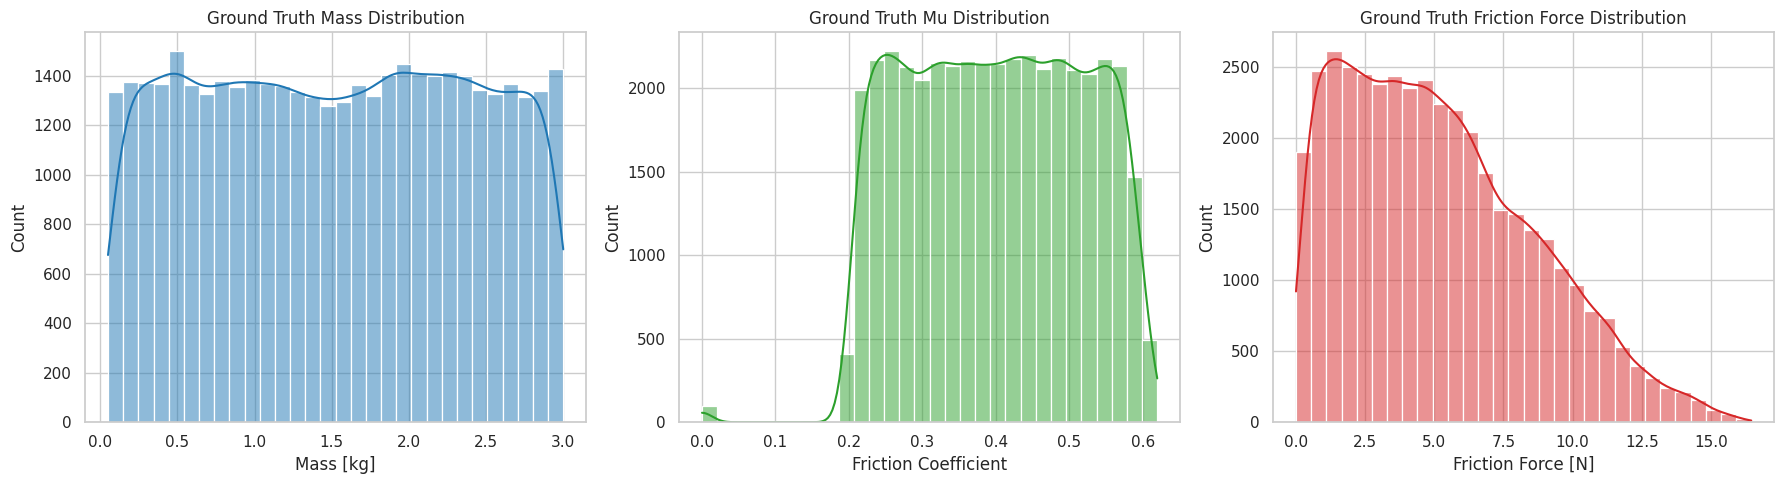


ANALYZING SAMPLE #38120
GT Mass: 1.052 kg
GT Mu:   0.476
GT Fric Force (Target): 3.843 N
Time Window: 20 -> 80

--- Dataset Property Statistics ---
Mass (kg):      Min = 0.0501, Max = 3.0000
Friction (mu):  Min = 0.0000, Max = 0.6195
Fric Force (N): Min = 0.0000, Max = 16.4578
win_len:  60
len of time_steps:  60


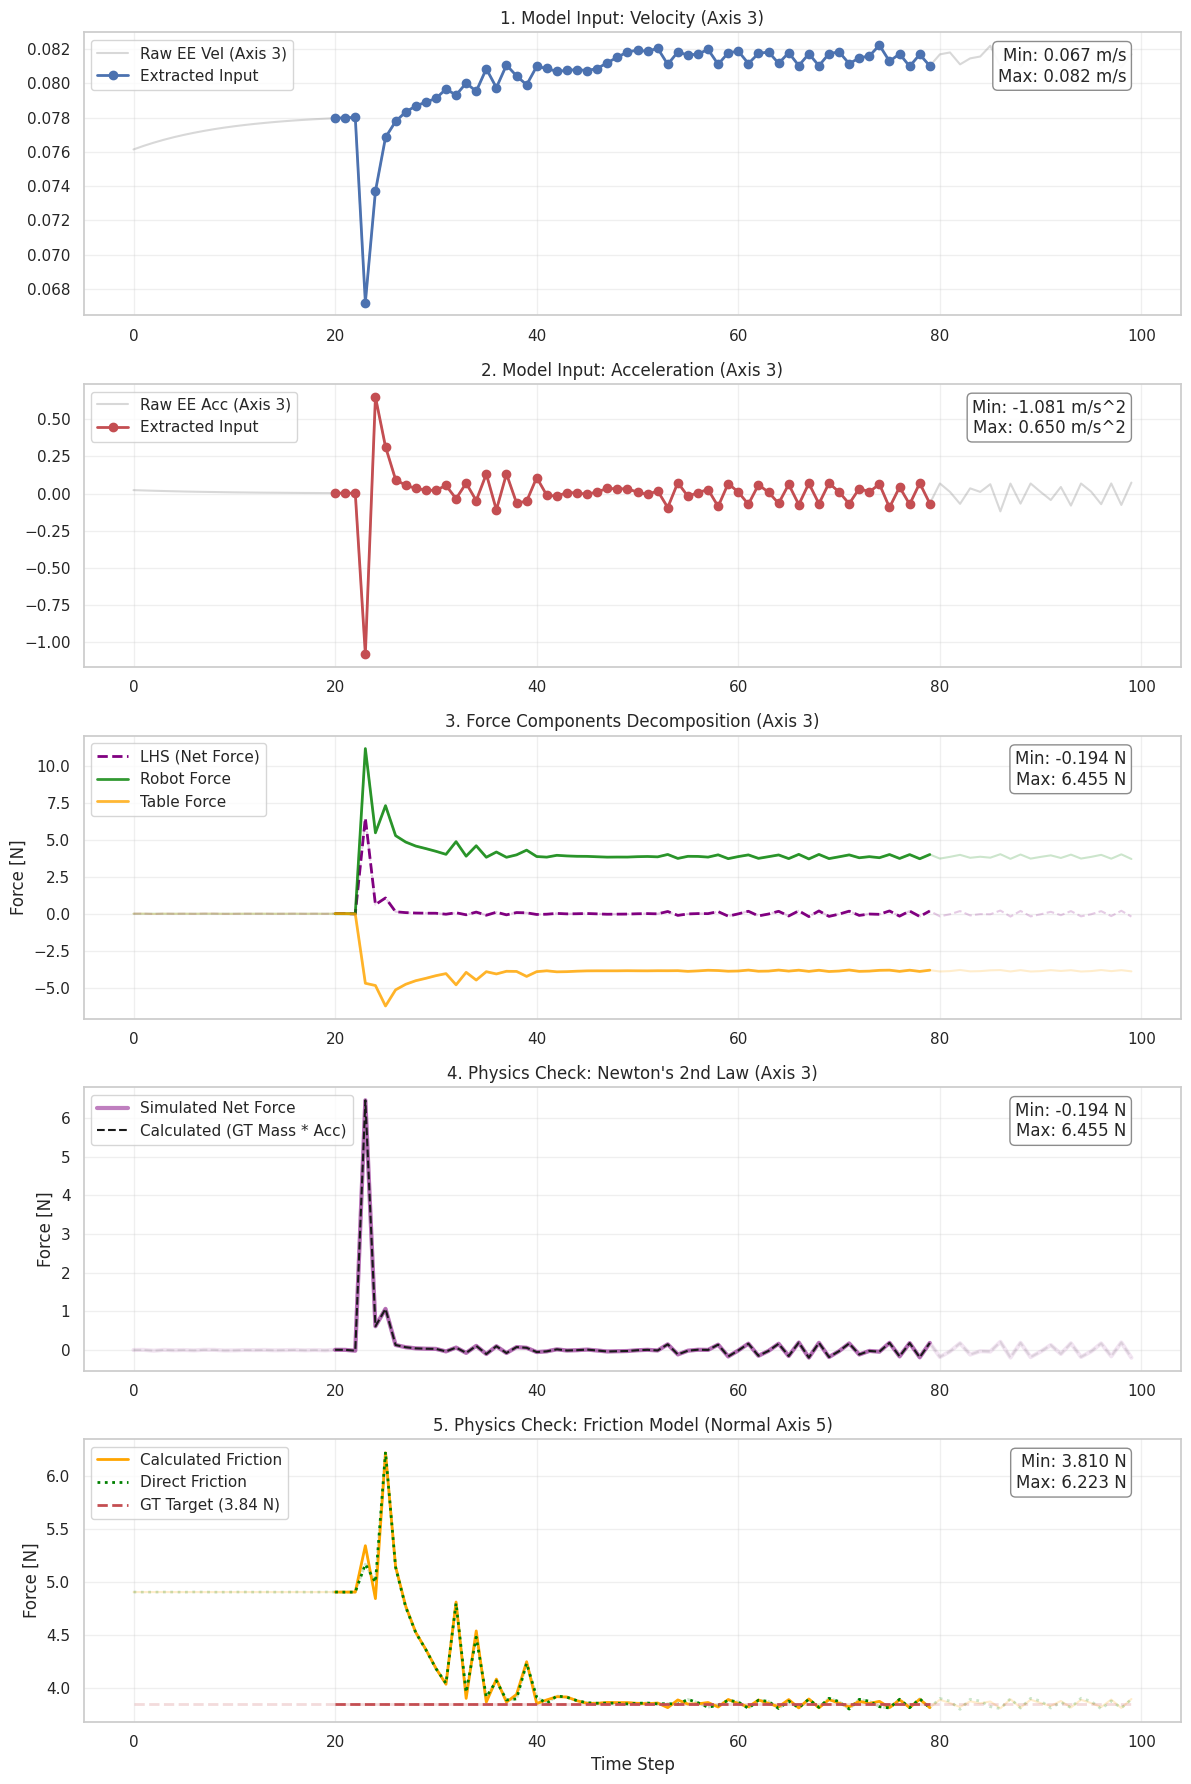

In [35]:

# ==========================================
# 1. CONFIGURATION
# ==========================================
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0005.csv"
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0005_CalibRubW5.csv"
CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta57_emavel1.0_velstd0.0.csv"
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta37_emavel1.0_velstd0.0.csv"
# CSV_PATH = "/home/psxkf4/IsaacLab/source/collected_data/data_tb-3_ta17_emavel1.0_velstd0.0.csv"


# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# 2. LOAD DATA
# ==========================================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
    print("Please check the path and try again.")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"✅ Successfully loaded data!")
    print(f"   Rows (Envs): {df.shape[0]}")
    print(f"   Columns:     {df.shape[1]}")
    
    # Optional: Display the dataframe
    # display(df)

# --- FIX DATA TYPES ---
# The 'gt_fric_force' column might be saved as strings (e.g., "[4.23]"). 
def clean_force_col(x):
    if isinstance(x, str):
        return float(x.strip('[]'))
    return x

if 'gt_fric_force' in df.columns:
    df['gt_fric_force'] = df['gt_fric_force'].apply(clean_force_col)
    print("✅ Fixed 'gt_fric_force' column types.")

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_sequence_data(row, prefix, seq_len=100, num_axes=6):
    """Reconstructs (100, 6) array from flattened columns like 'prefix_t0_ax0'"""
    data = np.zeros((seq_len, num_axes))
    for t in range(seq_len):
        for ax in range(num_axes):
            col = f"{prefix}_t{t}_ax{ax}"
            if col in row:
                data[t, ax] = row[col]
    return data

def get_flat_window(row, prefix, window_size=10):
    """Reconstructs 1D array from columns like 'prefix_0', 'prefix_1'"""
    data = np.zeros(window_size)
    for i in range(window_size):
        col = f"{prefix}_{i}"
        if col in row:
            data[i] = row[col]
    return data

# ==========================================
# 4. DISTRIBUTION PLOTS (Targets)
# ==========================================
if 'df' in locals():
    print("\n--- Target Property Distributions ---")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Mass
    sns.histplot(df['gt_mass'], kde=True, ax=axes[0], color='tab:blue', bins=30)
    axes[0].set_title('Ground Truth Mass Distribution')
    axes[0].set_xlabel('Mass [kg]')
    
    # Friction Coeff
    sns.histplot(df['gt_mu'], kde=True, ax=axes[1], color='tab:green', bins=30)
    axes[1].set_title('Ground Truth Mu Distribution')
    axes[1].set_xlabel('Friction Coefficient')
    
    # Friction Force
    sns.histplot(df['gt_fric_force'], kde=True, ax=axes[2], color='tab:red', bins=30)
    axes[2].set_title('Ground Truth Friction Force Distribution')
    axes[2].set_xlabel('Friction Force [N]')

    if PLOT_SHOW:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

# ==========================================
# 5. INTEGRATED SAMPLE ANALYSIS (UPDATED WITH HIGHLIGHTS + MIN/MAX)
# ==========================================
if 'df' in locals():
    # --- CONFIGURATION ---
    AXIS_MOTION = 3   
    AXIS_VERTICAL = 5 
    G = 9.81

    # 1. Pick a single random sample for ALL plots
    sample_idx = np.random.randint(0, len(df))
    row = df.iloc[sample_idx]
    
    print(f"\n=======================================================")
    print(f"ANALYZING SAMPLE #{sample_idx}")
    print(f"=======================================================")
    print(f"GT Mass: {row['gt_mass']:.3f} kg")
    print(f"GT Mu:   {row['gt_mu']:.3f}")
    
    gt_fric_force_val = row['gt_fric_force']
    if isinstance(gt_fric_force_val, str):
        gt_fric_force_val = float(gt_fric_force_val.strip('[]'))
    print(f"GT Fric Force (Target): {gt_fric_force_val:.3f} N")
    print(f"Time Window: {int(row['start_t'])} -> {int(row['end_t'])}")

    # --- HELPER TO ADD MIN/MAX TEXT ---
    def add_min_max_text(ax, data, unit=""):
        dmin, dmax = np.min(data), np.max(data)
        stats_text = f"Min: {dmin:.3f} {unit}\nMax: {dmax:.3f} {unit}"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))


    print("\n--- Dataset Property Statistics ---")
    
    # Mass Statistics
    m_min, m_max = df['gt_mass'].min(), df['gt_mass'].max()
    print(f"Mass (kg):      Min = {m_min:.4f}, Max = {m_max:.4f}")
    
    # Friction Coefficient Statistics
    mu_min, mu_max = df['gt_mu'].min(), df['gt_mu'].max()
    print(f"Friction (mu):  Min = {mu_min:.4f}, Max = {mu_max:.4f}")
    
    # Friction Force Statistics
    if 'gt_fric_force' in df.columns:
        # Note: Ensure cleaning logic for '[]' strings was applied first
        f_min, f_max = df['gt_fric_force'].min(), df['gt_fric_force'].max()
        print(f"Fric Force (N): Min = {f_min:.4f}, Max = {f_max:.4f}")
        

    # --- 2. EXTRACT DATA ---
    raw_acc = get_sequence_data(row, "raw_ee_acc")
    raw_vel = get_sequence_data(row, "raw_ee_vel")
    
    input_cols = [c for c in df.columns if "input_acc_" in c]
    win_len = len(input_cols)
    input_acc = get_flat_window(row, "input_acc", win_len)
    input_vel = get_flat_window(row, "input_vel", win_len)
    
    lhs_wrench = get_sequence_data(row, "pinn_LHS_wrench")      
    rhs_acc = get_sequence_data(row, "pinn_RHS_acc")            
    robot_wrench = get_sequence_data(row, "pinn_robot_wrench")  
    table_wrench = get_sequence_data(row, "pinn_table_wrench")  

    win_len = len(input_cols)
    start_t = int(row['start_t'])
    time_steps = np.arange(start_t, start_t + win_len)
    print("win_len: ", win_len)
    print("len of time_steps: ", len(time_steps))

    # --- 3. CALCULATIONS ---
    # Newton Check
    net_force_sim = lhs_wrench[:, AXIS_MOTION]
    acc_sim = rhs_acc[:, AXIS_MOTION]
    net_force_calc = row['gt_mass'] * acc_sim

    # Friction Check
    robot_force_vertical = robot_wrench[:, AXIS_VERTICAL]
    normal_force_calc = (row['gt_mass'] * G) - robot_force_vertical
    fric_force_calc_profile = row['gt_mu'] * normal_force_calc
    
    normal_force_direct = table_wrench[:, AXIS_VERTICAL]
    fric_force_direct_profile = row['gt_mu'] * normal_force_direct
    # fric_force_direct_profile = normal_force_direct
    
    fric_force_gt_line = np.full_like(fric_force_calc_profile, gt_fric_force_val)

    # --- 4. PLOTTING ---
    fig, axes = plt.subplots(5, 1, figsize=(12, 18))
    
    # Plot 1: Velocity Input
    axes[0].plot(raw_vel[:, AXIS_MOTION], label=f'Raw EE Vel (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[0].plot(time_steps, input_vel, 'b-o', linewidth=2, label='Extracted Input')
    
    axes[0].set_title(f"1. Model Input: Velocity (Axis {AXIS_MOTION})")
    add_min_max_text(axes[0], input_vel, "m/s") # Add stats
    axes[0].legend(loc='upper left')

    # Plot 2: Acceleration Input
    axes[1].plot(raw_acc[:, AXIS_MOTION], label=f'Raw EE Acc (Axis {AXIS_MOTION})', color='gray', alpha=0.3)
    axes[1].plot(time_steps, input_acc, 'r-o', linewidth=2, label='Extracted Input')
    
    axes[1].set_title(f"2. Model Input: Acceleration (Axis {AXIS_MOTION})")
    add_min_max_text(axes[1], input_acc, "m/s^2") # Add stats
    axes[1].legend(loc='upper left')

    # Plot 3: Component Breakdown
    lhs_val = lhs_wrench[:, AXIS_MOTION]
    robot_val = robot_wrench[:, AXIS_MOTION]
    table_val = table_wrench[:, AXIS_MOTION]
    
    # Background
    axes[2].plot(lhs_val, color='purple', linestyle='--', alpha=0.2)
    axes[2].plot(robot_val, color='green', alpha=0.2)
    axes[2].plot(table_val, color='orange', alpha=0.2)
    
    # Foreground
    net_win = lhs_val[time_steps]
    axes[2].plot(time_steps, net_win, label='LHS (Net Force)', color='purple', linestyle='--', linewidth=2)
    axes[2].plot(time_steps, robot_val[time_steps], label='Robot Force', color='green', alpha=0.8, linewidth=2)
    axes[2].plot(time_steps, table_val[time_steps], label='Table Force', color='orange', alpha=0.8, linewidth=2)
    
    axes[2].set_title(f"3. Force Components Decomposition (Axis {AXIS_MOTION})")
    axes[2].set_ylabel("Force [N]")
    add_min_max_text(axes[2], net_win, "N") # Add stats for Net Force
    axes[2].legend(loc='upper left')

    # Plot 4: Newton's Law Check
    # Background
    axes[3].plot(net_force_sim, color='purple', linewidth=3, alpha=0.1)
    axes[3].plot(net_force_calc, 'k--', linewidth=1.5, alpha=0.1)
    
    # Foreground
    sim_win = net_force_sim[time_steps]
    axes[3].plot(time_steps, sim_win, label='Simulated Net Force', color='purple', linewidth=3, alpha=0.5)
    axes[3].plot(time_steps, net_force_calc[time_steps], 'k--', label='Calculated (GT Mass * Acc)', linewidth=1.5)
    
    axes[3].set_title(f"4. Physics Check: Newton's 2nd Law (Axis {AXIS_MOTION})")
    axes[3].set_ylabel("Force [N]")
    add_min_max_text(axes[3], sim_win, "N") # Add stats for Sim Force
    axes[3].legend(loc='upper left')

    # Plot 5: Friction Model Check
    # Background
    axes[4].plot(fric_force_calc_profile, color='orange', alpha=0.2)
    axes[4].plot(fric_force_direct_profile, color='green', linestyle=':', linewidth=2, alpha=0.2)
    axes[4].plot(fric_force_gt_line, 'r--', linewidth=2, alpha=0.2)

    # Foreground
    calc_win = fric_force_calc_profile[time_steps]
    axes[4].plot(time_steps, calc_win, label='Calculated Friction', color='orange', linewidth=2)
    axes[4].plot(time_steps, fric_force_direct_profile[time_steps], label='Direct Friction', color='green', linestyle=':', linewidth=2)
    axes[4].plot(time_steps, fric_force_gt_line[time_steps], 'r--', label=f'GT Target ({gt_fric_force_val:.2f} N)', linewidth=2)
    
    axes[4].set_title(f"5. Physics Check: Friction Model (Normal Axis {AXIS_VERTICAL})")
    axes[4].set_ylabel("Force [N]")
    axes[4].set_xlabel("Time Step")
    add_min_max_text(axes[4], calc_win, "N") # Add stats for Calculated Friction
    axes[4].legend(loc='upper left')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    if PLOT_SHOW:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)

In [36]:
import random
import os

def set_seed(seed=42):
    # Set seed for Python's built-in random module
    random.seed(seed)
    # Set seed for environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    # Set seed for PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior in CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Global seed set to: {seed}")

set_seed(42)

✅ Global seed set to: 42


In [37]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# ==========================================
# 1. DATA PREPARATION & SHAPE CHECKS
# ==========================================
if 'df' in locals():
    set_seed(42)
    print("--- Preparing Data & Checking Shapes ---")

    # mass
    # m_seen_max, m_seen_min = 1.5, 0.2
    # m_unseen_max, m_unseen_min = 2.0, m_seen_min
    # m_seen_max, m_seen_min = 1.0, 0.2
    # m_unseen_max, m_unseen_min = 2.0, m_seen_min
    m_seen_max, m_seen_min = 1.0, 0.3
    m_unseen_max, m_unseen_min = 2.0, 0.1
    
    # friction coeff
    mu_seen_max, mu_seen_min = 0.5, 0.3
    mu_unseen_max, mu_unseen_min = 0.6, 0.2
    
    # Define the physics categorization logic
    conditions = [
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_seen_mu_seen
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_over
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] >= mu_seen_min)   & (df['gt_mu'] <= mu_seen_max), # m_under
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max), # mu_over
        (df['gt_mass'] >= m_seen_min)   & (df['gt_mass'] <= m_seen_max)   & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # mu_under
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max), # m_over_mu_over
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # m_under_mu_under
        (df['gt_mass'] > m_seen_max)    & (df['gt_mass'] <= m_unseen_max) & (df['gt_mu'] >= mu_unseen_min) & (df['gt_mu'] < mu_seen_min), # m_over_mu_under
        (df['gt_mass'] >= m_unseen_min) & (df['gt_mass'] < m_seen_min)    & (df['gt_mu'] > mu_seen_max)    & (df['gt_mu'] <= mu_unseen_max)  # m_under_mu_over
    ]
    choices = [
        'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
        'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
    ]

    # Assign labels to a new column 'domain'
    df['domain'] = np.select(conditions, choices, default='other')

    # Now filter the dataframe for training (the "seen" range)
    df_filtered = df[df['domain'] == 'm_seen_mu_seen'].copy()
    
    print(f"Filtered Dataset: {len(df_filtered)} samples (from {len(df)} total).")
    
    # 1. Identify Input Columns (v and a)
    acc_cols = sorted([c for c in df_filtered.columns if "input_acc_" in c], key=lambda x: int(x.split('_')[-1]))
    vel_cols = sorted([c for c in df_filtered.columns if "input_vel_" in c], key=lambda x: int(x.split('_')[-1]))

    # Sort columns numerically (0, 1, 2...) to ensure temporal order is preserved for the Transformer
    acc_cols.sort(key=lambda x: int(x.split('_')[-1]))
    vel_cols.sort(key=lambda x: int(x.split('_')[-1]))
    
    print(f"Found {len(acc_cols)} Acceleration columns.")
    print(f"Found {len(vel_cols)} Velocity columns.")

    # 2. Extract Flattened Data: Convert dataframe columns to 32-bit float NumPy arrays for PyTorch compatibility
    X_acc_flat = df_filtered[acc_cols].values.astype(np.float32)
    X_vel_flat = df_filtered[vel_cols].values.astype(np.float32)
    
    # --- FIX: Set Axes to 1 (Translational X only) ---
    num_axes = 1  
    
    # Calculate Sequence Length: Determine the number of time steps (T) per sample
    if len(acc_cols) % num_axes != 0:
        print("⚠️ WARNING: Total columns not divisible by axis count!")
        
    seq_len = len(acc_cols) // num_axes
    print(f"Detected Sequence Length: {seq_len} (Total Features: {len(acc_cols)})")
    
    # Reshape from [Batch, Total_Features] to [Batch, Seq_Len, Axes]
    # Transformers expect a 3D sequence: (Batch Size, Time Steps, Feature Dimension)
    X_acc = X_acc_flat.reshape(-1, seq_len, num_axes)
    X_vel = X_vel_flat.reshape(-1, seq_len, num_axes)
    
    print(f"Reshaped Acc Tensor: {X_acc.shape} (Batch, Time, Axes)")
    print(f"Reshaped Vel Tensor: {X_vel.shape} (Batch, Time, Axes)")
    
    # 3. Extract Targets: Get ground truth for Mass and Friction coefficient (mu)
    y = df_filtered[['gt_mass', 'gt_mu']].values.astype(np.float32)
    print(f"Targets Shape: {y.shape}")
    
    # 4. Convert to PyTorch Tensors: Move data from NumPy arrays to CPU tensors
    X_acc_tensor = torch.tensor(X_acc)
    X_vel_tensor = torch.tensor(X_vel)
    y_tensor = torch.tensor(y)

    robot_fz_list, rhs_acc_list, lhs_net_f_list, table_fz_list = [], [], [], []
    robot_fx_list = []
    for idx, row in df_filtered.iterrows():
        st = int(row['start_t'])  # Get this specific sample's start time
        window_range = range(st, st + seq_len) # Define the 20-frame window
        
        robot_fz_list.append([row[f"pinn_robot_wrench_t{t}_ax5"] for t in window_range])
        rhs_acc_list.append([row[f"pinn_RHS_acc_t{t}_ax3"] for t in window_range])
        lhs_net_f_list.append([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window_range])
        table_fz_list.append([row[f"pinn_table_wrench_t{t}_ax5"] for t in window_range])
        robot_fx_list.append([row[f"pinn_robot_wrench_t{t}_ax3"] for t in window_range])

    fz_robot_tensor = torch.tensor(np.array(robot_fz_list), dtype=torch.float32) # [B, 20]
    rhs_acc_tensor = torch.tensor(np.array(rhs_acc_list), dtype=torch.float32)   # [B, 20]
    lhs_net_f_tensor = torch.tensor(np.array(lhs_net_f_list), dtype=torch.float32) # [B, 20]
    fz_normal_tensor = torch.tensor(np.array(table_fz_list), dtype=torch.float32) # [B, 20]
    fx_robot_tensor = torch.tensor(np.array(robot_fx_list), dtype=torch.float32)
    start_t_values = df_filtered['start_t'].values.astype(np.int64)
    start_t_tensor = torch.tensor(start_t_values)

    
    # 5. Train/Val Split: Create an array of indices to shuffle and split the filtered data
    indices = np.arange(len(df_filtered))
    # Reserve 20% of the filtered data for validation to monitor for overfitting/attention collapse
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    # Create TensorDatasets: Group filtered acceleration, velocity, and targets together by their indices
    train_dataset = TensorDataset(
        X_acc_tensor[train_idx], 
        X_vel_tensor[train_idx], 
        y_tensor[train_idx],
        fz_robot_tensor[train_idx],
        rhs_acc_tensor[train_idx],
        lhs_net_f_tensor[train_idx],
        fz_normal_tensor[train_idx],
        start_t_tensor[train_idx],
        fx_robot_tensor[train_idx]
    )
    val_dataset = TensorDataset(
        X_acc_tensor[val_idx], 
        X_vel_tensor[val_idx], 
        y_tensor[val_idx],
        fz_robot_tensor[val_idx],
        rhs_acc_tensor[val_idx],
        lhs_net_f_tensor[val_idx],
        fz_normal_tensor[val_idx],
        start_t_tensor[val_idx],
        fx_robot_tensor[val_idx]
    )

    # We use a manual_seed generator to ensure the SHUFFLE is identical across runs
    g = torch.Generator()
    g.manual_seed(42)
    
    # Initialize DataLoaders: Batch the data for training; shuffle training data to prevent ordering bias
    batch_size = 64
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id),
        generator=g
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    print("-" * 30)
    print(f"Train Samples: {len(train_idx)} | Val Samples: {len(val_idx)}")
    print("✅ Data preparation complete and seeded.")
    
else:
    print("❌ Error: 'df' not found. Run Data Loading cell first.")

✅ Global seed set to: 42
--- Preparing Data & Checking Shapes ---
Filtered Dataset: 5031 samples (from 40960 total).
Found 60 Acceleration columns.
Found 60 Velocity columns.
Detected Sequence Length: 60 (Total Features: 60)
Reshaped Acc Tensor: (5031, 60, 1) (Batch, Time, Axes)
Reshaped Vel Tensor: (5031, 60, 1) (Batch, Time, Axes)
Targets Shape: (5031, 2)
------------------------------
Train Samples: 4024 | Val Samples: 1007
✅ Data preparation complete and seeded.


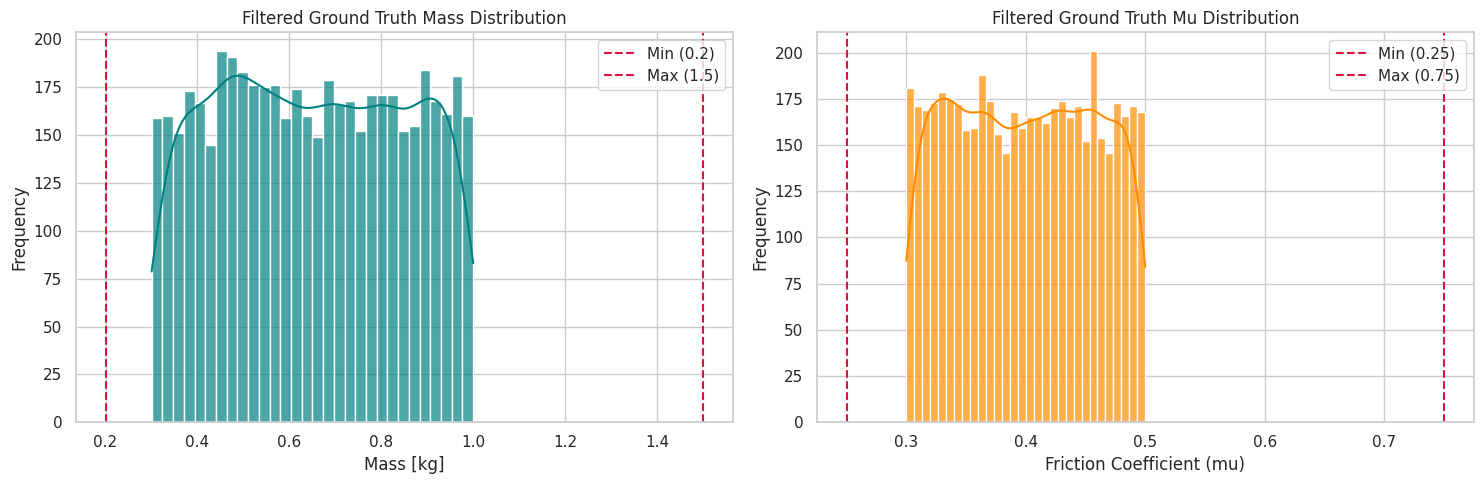

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot Filtered Mass Distribution
sns.histplot(df_filtered['gt_mass'], bins=30, kde=True, ax=ax1, color='teal', alpha=0.7)
ax1.set_title('Filtered Ground Truth Mass Distribution')
ax1.set_xlabel('Mass [kg]')
ax1.set_ylabel('Frequency')
# Draw boundary lines to verify filtering
ax1.axvline(0.2, color='crimson', linestyle='--', label='Min (0.2)')
ax1.axvline(1.5, color='crimson', linestyle='--', label='Max (1.5)')
ax1.legend()

# 2. Plot Filtered Mu Distribution
sns.histplot(df_filtered['gt_mu'], bins=30, kde=True, ax=ax2, color='darkorange', alpha=0.7)
ax2.set_title('Filtered Ground Truth Mu Distribution')
ax2.set_xlabel('Friction Coefficient (mu)')
ax2.set_ylabel('Frequency')
# Draw boundary lines to verify filtering
ax2.axvline(0.25, color='crimson', linestyle='--', label='Min (0.25)')
ax2.axvline(0.75, color='crimson', linestyle='--', label='Max (0.75)')
ax2.legend()

if PLOT_SHOW:
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig)

# Print statistical summary to verify the exact ranges
# print("--- Statistical Verification ---")
# print(df_filtered[['gt_mass', 'gt_mu']].describe().loc[['min', 'max', 'mean']])

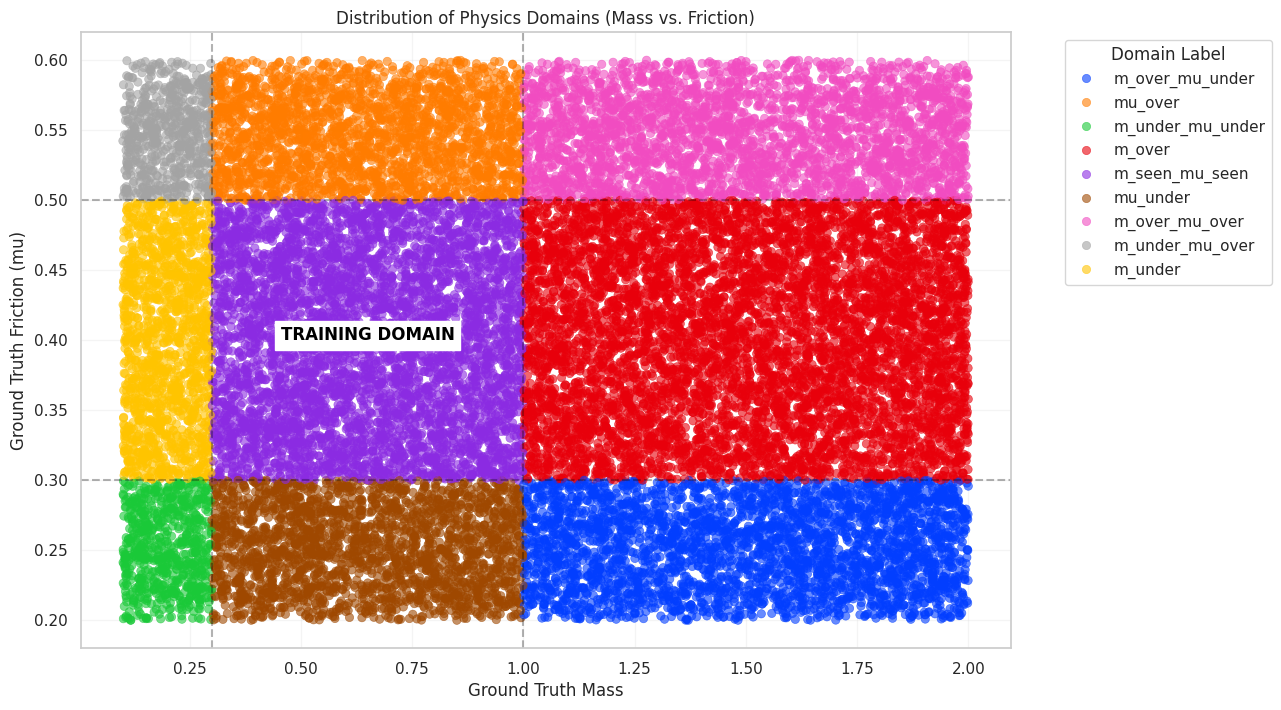


--- Domain Sample Counts ---
domain
other               15009
m_over               6995
m_seen_mu_seen       5031
m_over_mu_under      3316
m_over_mu_over       3183
mu_over              2336
mu_under             2305
m_under              1441
m_under_mu_under      703
m_under_mu_over       641
Name: count, dtype: int64


In [39]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ==========================================
# # DATASET DOMAIN VISUALIZATION
# # ==========================================
# if 'df' in locals():
#     plt.figure(figsize=(12, 8))
    
#     # Define a distinct color palette for the choices
#     palette = sns.color_palette("husl", len(choices))
    
#     # Create the scatter plot
#     # We use alpha=0.5 so we can see density in overlapping regions
#     sns.scatterplot(
#         data=df[df['domain'] != 'other'], 
#         x='gt_mass', 
#         y='gt_mu', 
#         hue='domain', 
#         palette='bright',
#         alpha=0.6,
#         edgecolor=None
#     )

#     # Draw the boundaries for the "Seen" (Training) region
#     plt.axvline(m_seen_min, color='black', linestyle='--', alpha=0.3)
#     plt.axvline(m_seen_max, color='black', linestyle='--', alpha=0.3)
#     plt.axhline(mu_seen_min, color='black', linestyle='--', alpha=0.3)
#     plt.axhline(mu_seen_max, color='black', linestyle='--', alpha=0.3)

#     # Label the "Seen" center for clarity
#     plt.text(
#         (m_seen_min + m_seen_max)/2, 
#         (mu_seen_min + mu_seen_max)/2, 
#         "TRAINING DOMAIN", 
#         weight='bold', ha='center', color='black', backgroundcolor='white'
#     )

#     plt.title("Distribution of Physics Domains (Mass vs. Friction)")
#     plt.xlabel("Ground Truth Mass")
#     plt.ylabel("Ground Truth Friction (mu)")
#     plt.legend(title="Domain Label", bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.grid(True, alpha=0.2)
#     if PLOT_SHOW:
#         plt.show()
#     else:
#         plt.close(fig)

#     # Print a summary table of the sample counts
#     print("\n--- Domain Sample Counts ---")
#     print(df['domain'].value_counts())
# else:
#     print("❌ Error: 'df' not found.")

📄 Figure successfully saved to: dataset_domain_distribution.png


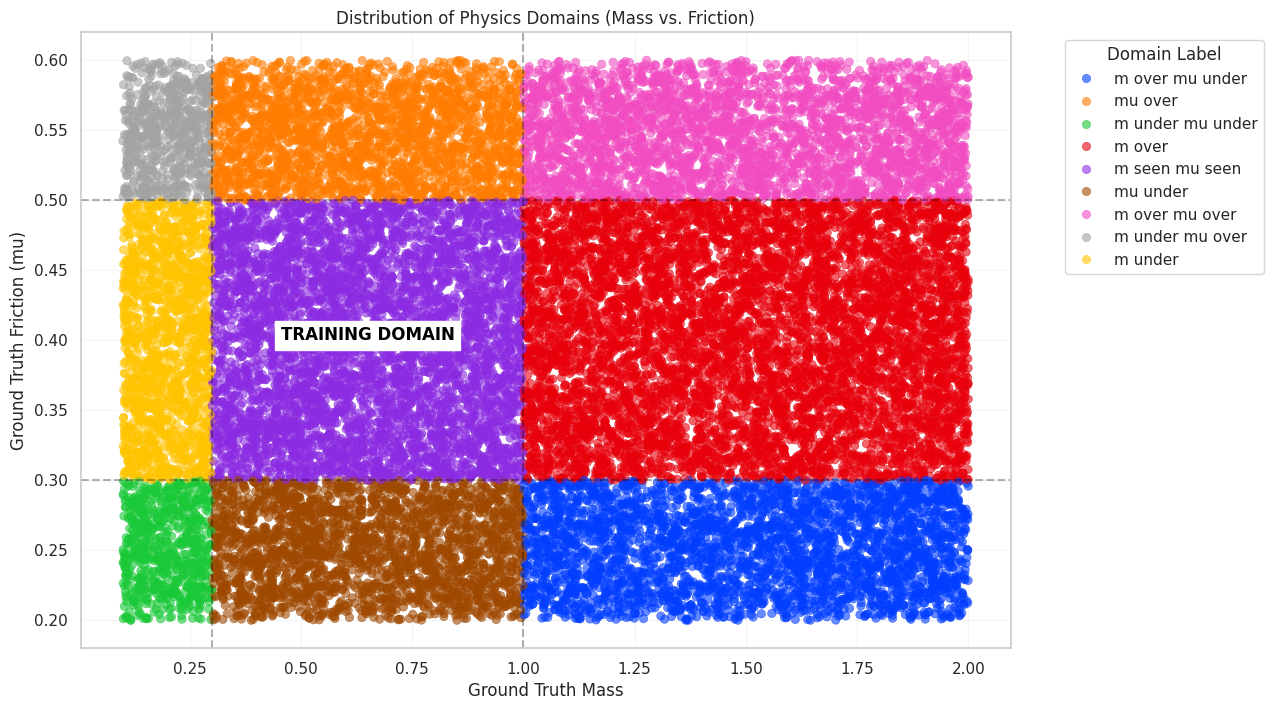


--- Domain Sample Counts ---
domain
other               15009
m_over               6995
m_seen_mu_seen       5031
m_over_mu_under      3316
m_over_mu_over       3183
mu_over              2336
mu_under             2305
m_under              1441
m_under_mu_under      703
m_under_mu_over       641
Name: count, dtype: int64


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DATASET DOMAIN VISUALIZATION
# ==========================================
if 'df' in locals():
    # Explicitly define 'fig' so plt.close(fig) works properly later
    fig = plt.figure(figsize=(12, 8))
    
    # --- NEW: Filter out 'other' and format labels without underscores ---
    plot_df = df[df['domain'] != 'other'].copy()
    plot_df['domain_label'] = plot_df['domain'].str.replace('_', ' ')
    
    # Create the scatter plot
    # We use alpha=0.5 so we can see density in overlapping regions
    sns.scatterplot(
        data=plot_df, 
        x='gt_mass', 
        y='gt_mu', 
        hue='domain_label',  # Use the cleaned labels here
        palette='bright',
        alpha=0.6,
        edgecolor=None
    )

    # Draw the boundaries for the "Seen" (Training) region
    plt.axvline(m_seen_min, color='black', linestyle='--', alpha=0.3)
    plt.axvline(m_seen_max, color='black', linestyle='--', alpha=0.3)
    plt.axhline(mu_seen_min, color='black', linestyle='--', alpha=0.3)
    plt.axhline(mu_seen_max, color='black', linestyle='--', alpha=0.3)

    # Label the "Seen" center for clarity
    plt.text(
        (m_seen_min + m_seen_max)/2, 
        (mu_seen_min + mu_seen_max)/2, 
        "TRAINING DOMAIN", 
        weight='bold', ha='center', color='black', backgroundcolor='white'
    )

    plt.title("Distribution of Physics Domains (Mass vs. Friction)")
    plt.xlabel("Ground Truth Mass")
    plt.ylabel("Ground Truth Friction (mu)")
    
    # Place legend outside
    plt.legend(title="Domain Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    
    # --- NEW: Save the figure ---
    # bbox_inches='tight' ensures the legend outside the plot doesn't get chopped off
    save_path = "dataset_domain_distribution.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📄 Figure successfully saved to: {save_path}")

    if PLOT_SHOW:
        plt.show()
    else:
        plt.close(fig)

    # Print a summary table of the sample counts
    print("\n--- Domain Sample Counts ---")
    print(df['domain'].value_counts())
else:
    print("❌ Error: 'df' not found.")

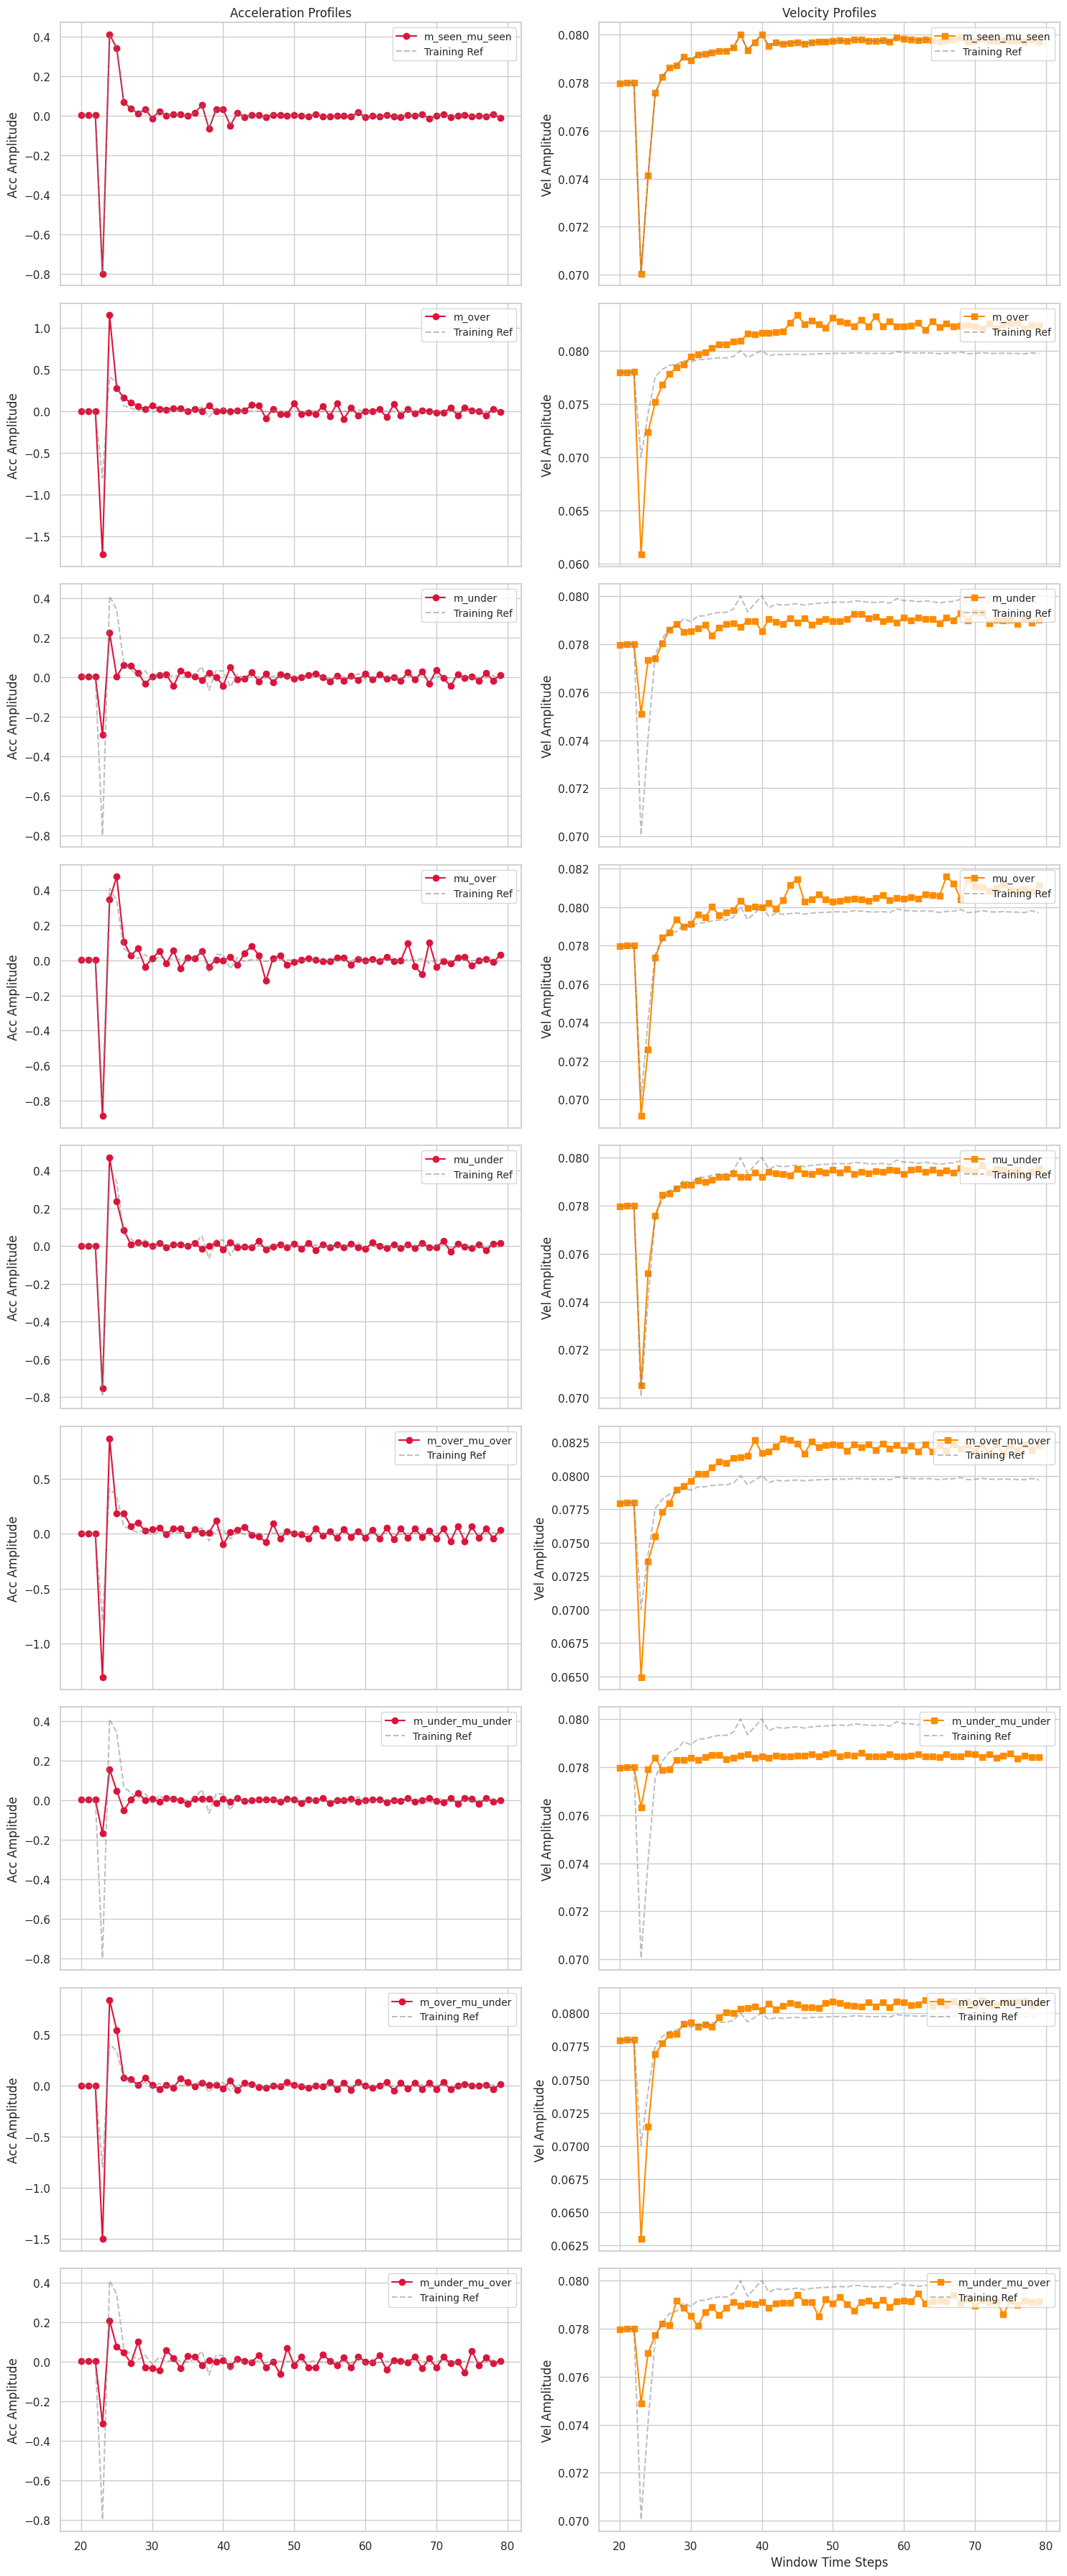

In [40]:
import matplotlib.pyplot as plt
import numpy as np

win_len = len(input_cols)
start_t = int(row['start_t'])
time_steps = np.arange(start_t, start_t + win_len)
fig, axes = plt.subplots(len(choices), 2, figsize=(15, 4 * len(choices)), sharex=True)

for i, domain in enumerate(choices):
    # Get a sample from the specific domain
    df_domain = df[df['domain'] == domain]
    if df_domain.empty:
        continue
    
    sample_idx = df_domain.index[0]
    # Reference sample from training for comparison
    ref_idx = df_filtered.index[0]

    # Plot Acceleration Comparison
    axes[i, 0].plot(time_steps, df_domain.loc[sample_idx, acc_cols].values, 'o-', color='crimson', label=f'{domain}')
    axes[i, 0].plot(time_steps, df_filtered.loc[ref_idx, acc_cols].values, '--', color='gray', alpha=0.5, label='Training Ref')
    axes[i, 0].set_ylabel('Acc Amplitude')
    axes[i, 0].legend(loc='upper right', fontsize='small')
    if i == 0: axes[i, 0].set_title("Acceleration Profiles")

    # Plot Velocity Comparison
    axes[i, 1].plot(time_steps, df_domain.loc[sample_idx, vel_cols].values, 's-', color='darkorange', label=f'{domain}')
    axes[i, 1].plot(time_steps, df_filtered.loc[ref_idx, vel_cols].values, '--', color='gray', alpha=0.5, label='Training Ref')
    axes[i, 1].set_ylabel('Vel Amplitude')
    axes[i, 1].legend(loc='upper right', fontsize='small')
    if i == 0: axes[i, 1].set_title("Velocity Profiles")

if PLOT_SHOW:
    plt.xlabel('Window Time Steps')
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig)

Plotting 10 samples closest to Mass: 0.78, Mu: 0.3


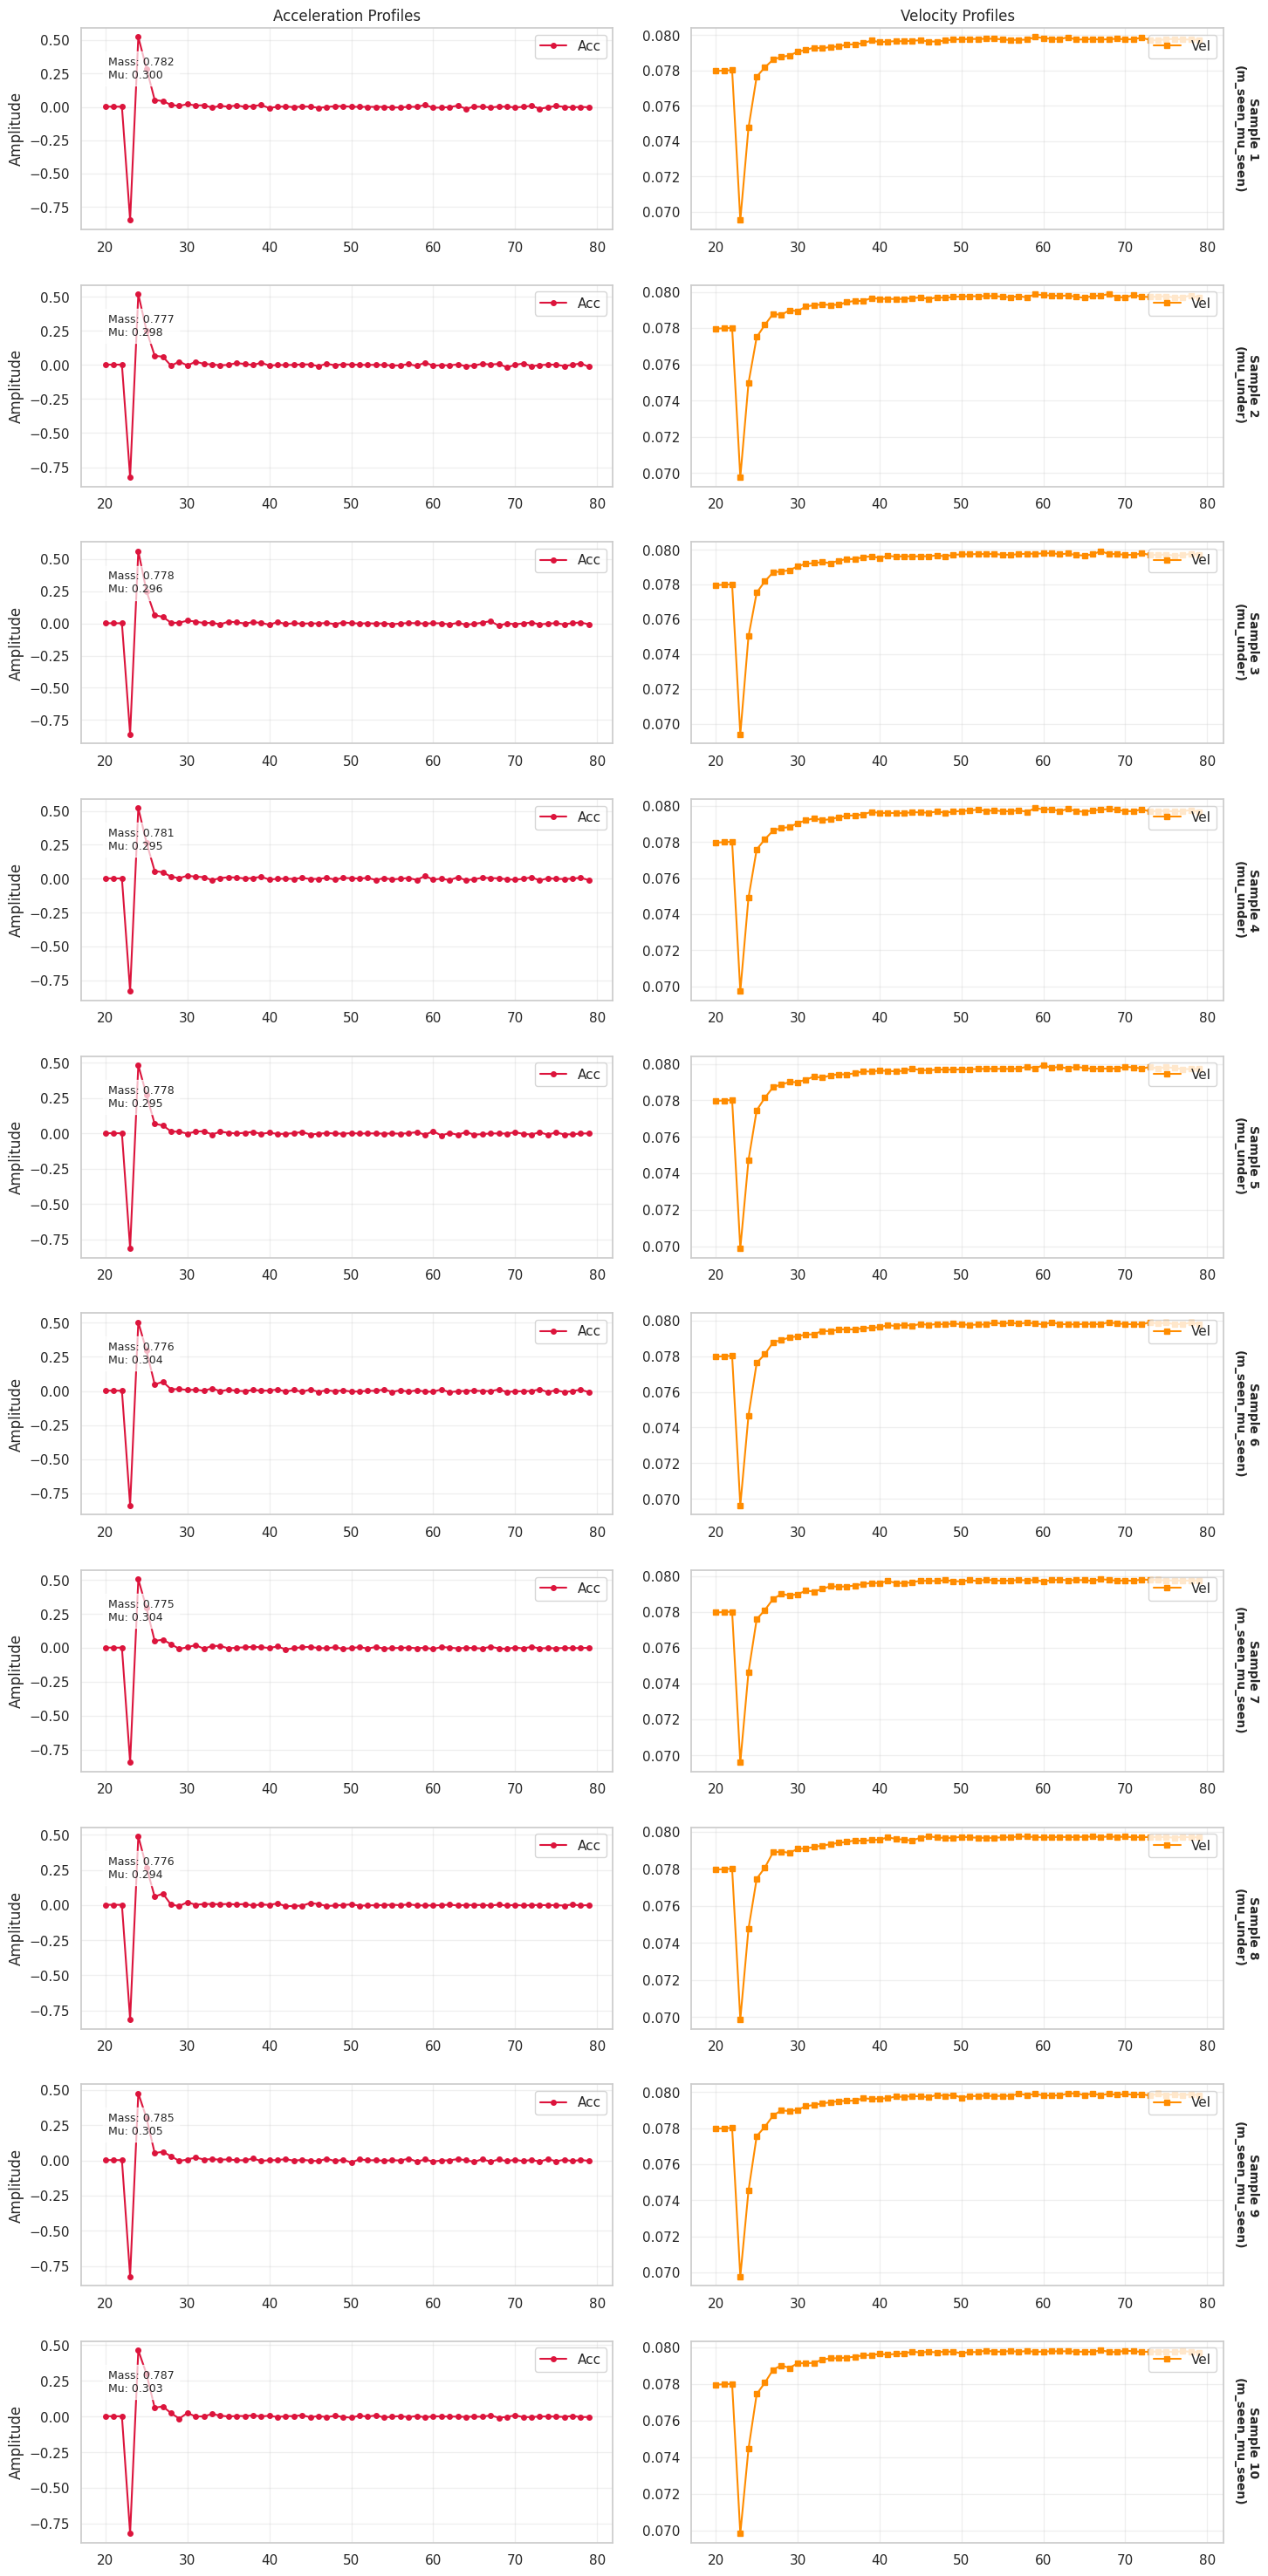

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION: Set your targets here
# ==========================================
target_mass = 0.78      # e.g., 0.3 kg
target_mu = 0.3         # e.g., 0.1 friction coefficient
num_samples = 10

if PLOT_SHOW:
    # 1. Calculate Distance
    df['dist'] = np.sqrt(
        (df['gt_mass'] - target_mass)**2 + 
        (df['gt_mu'] - target_mu)**2
    )
    
    # 2. Get the top 10 closest samples
    closest_samples = df.sort_values('dist').head(num_samples)
    
    # 3. Visualization
    win_len = len(input_cols)
    
    # Removed sharex=True so each row can have its own X-axis if start_t differs
    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 3 * num_samples))
    
    print(f"Plotting {num_samples} samples closest to Mass: {target_mass}, Mu: {target_mu}")
    
    for i, (idx, row) in enumerate(closest_samples.iterrows()):
        # Extract sequence data
        acc_data = row[acc_cols].values
        vel_data = row[vel_cols].values
        
        # Calculate time steps per row to fix the bug
        start_t = int(row['start_t'])
        time_steps = np.arange(start_t, start_t + win_len)
        
        # Metadata
        m_val = row['gt_mass']
        mu_val = row['gt_mu']
        dom = row['domain']
    
        # Plot Acceleration (Left Column)
        axes[i, 0].plot(time_steps, acc_data, 'o-', color='crimson', markersize=4, label='Acc')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend(loc='upper right')
        if i == 0: axes[i, 0].set_title("Acceleration Profiles")
        
        # FIX: Use transAxes to place text at 5% x, 75% y regardless of time_steps values
        axes[i, 0].text(0.05, 0.75, f"Mass: {m_val:.3f}\nMu: {mu_val:.3f}", 
                        transform=axes[i, 0].transAxes,
                        fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    
        # Plot Velocity (Right Column)
        axes[i, 1].plot(time_steps, vel_data, 's-', color='darkorange', markersize=4, label='Vel')
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend(loc='upper right')
        if i == 0: axes[i, 1].set_title("Velocity Profiles")
        
        # FIX: Move the domain label to the RIGHT side of the right column
        axes[i, 1].yaxis.set_label_position("right")
        axes[i, 1].set_ylabel(f"Sample {i+1}\n({dom})", fontsize=10, fontweight='bold', rotation=-90, labelpad=30)
    
    # Add a little padding to the layout to ensure no warnings
    plt.tight_layout(pad=2.0)
    plt.show()
    
    # Clean up distance column so it doesn't interfere with later cells
    df.drop(columns=['dist'], inplace=True)

In [42]:
# Calculate reference means from training data
ref_acc_mean = df_filtered[acc_cols].abs().values.mean()
ref_vel_mean = df_filtered[vel_cols].abs().values.mean()

# print(f"{'Domain':<20} | {'Acc Mean':<10} | {'Acc Drift %':<12} | {'Vel Mean':<10} | {'Vel Drift %'}")
# print("-" * 75)

for domain in choices:
    df_domain = df[df['domain'] == domain]
    if df_domain.empty: continue
    
    # Calculate absolute means for the domain
    d_acc_mean = df_domain[acc_cols].abs().values.mean()
    d_vel_mean = df_domain[vel_cols].abs().values.mean()
    
    # Calculate drift percentage
    acc_drift = ((d_acc_mean - ref_acc_mean) / ref_acc_mean) * 100
    vel_drift = ((d_vel_mean - ref_vel_mean) / ref_vel_mean) * 100
    
    # print(f"{domain:<20} | {d_acc_mean:<10.4f} | {acc_drift: >+11.2f}% | {d_vel_mean:<10.4f} | {vel_drift: >+10.2f}%")

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    """
    MATHEMATICAL LOGIC:
    Since Transformers process sequences in parallel, they lack an inherent sense of time.
    We inject a sinusoidal signal PE(pos, 2i) = sin(pos / 10000^(2i/d_model)) to encode 
    temporal order. This allows the model to distinguish between an acceleration spike 
    at t=65 versus steady-state motion at t=80.
    """
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # div_term defines the wavelength of the sinusoidal signals.
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Math: z_t = embedding_vector_t + PE_vector_t
        return x + self.pe[:, :x.size(1), :]

class PhysicsTransformerEstimator(nn.Module):
    def __init__(
        self,
        input_dim=1,         # Subscript x_t: [vel]
        d_model=64,          # Latent dimension (d)
        nhead=4,
        # =========================================================================================
        # MULTI-HEAD ATTENTION (nhead=4)
        # =========================================================================================
        # 1. SPLITTING: The d_model (64) is split into 4 heads of 16 dimensions each.
        #    Math: head_dim = d_model // nhead = 16.
        #
        # 2. PARALLEL PHYSICS: Each head has its own W_Q, W_K, and W_V matrices.
        #    This allows Head 1 to spotlight the 'Spike' while Head 2 spotlights the 'Slide'.
        #
        # 3. CONCATENATION: The 4 outputs [Batch, 20, 16] are glued together to form [Batch, 20, 64].
        #    Final Context = Concat(head_1, head_2, head_3, head_4) @ W_O.
        #
        # 4. WHY 4?: It provides enough diversity to capture mass (transient) and 
        #    friction (steady-state) without making the feature space too small.
        # =========================================================================================
        num_encoder_layers=2, 
        dim_feedforward=128, 
        seq_len=60, 
        dropout=0.1,
        sharpness=10.0,
        cross_sharpness=10.0,
        m_sharpness=30.0,
        mu_sharpness=10.0,
        version=1,
    ):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.sharpness = sharpness 
        self.cross_sharpness = cross_sharpness
        self.m_sharpness = m_sharpness
        self.mu_sharpness = mu_sharpness
        self.version = version

        # ============================================================
        # STEP 1: CONTINUOUS EMBEDDING & ENCODER
        # Math: z_t = W_in * x_t + b_in
        # W_in and b_in are TRAINABLE parameters. They learn how to 
        # map raw kinematics into a high-dimensional physical feature space.
        # ============================================================
        self.input_proj = nn.Linear(input_dim, d_model)
        self.input_norm = nn.LayerNorm(d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len + 10)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            batch_first=True, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # ============================================================
        # STEP 2: DECODER (GENERATING h_t_dec)
        # Math: h_t_dec = CrossAttention(q_t_query, H_enc, H_enc)
        # h_t_dec is the hidden state for time step 't' that integrates 
        # the entire motion context into a force-ready representation.
        # ============================================================
        
        # Parameter: Learned Time Queries
        # Action: A trainable matrix representing "what the model wants to know" about each time step.
        # MATH: In an LLM, Query = W_Q * Embedding. In your case, these ARE the Queries (Parameters).
        # Instead of calculating them from the input, the model optimizes these 64D vectors 
        # during training to become "templates" for each of the 20 time steps.
        # self.time_queries = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.1)
        if not self.version in [3, 4]:
            self.time_queries = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        # Layer: Cross-Attention
        # Logic: The model performs the standard dot-product attention: 
        # Score = (q_dec * W_Q) @ (h_enc * W_K).T
        # Even though q_dec starts as a fixed parameter, the 'MultiheadAttention' layer 
        # still applies a learned W_Q weight matrix to it during the forward pass.
        if not self.version in [3, 4]:
            self.cross_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True, dropout=dropout)
            
            self.norm_dec = nn.LayerNorm(d_model)
            self.ffn_dec = nn.Sequential(
                nn.Linear(d_model, dim_feedforward), 
                nn.ReLU(), 
                nn.Linear(dim_feedforward, d_model)
            )
            self.norm_ffn = nn.LayerNorm(d_model)

        # ============================================================
        # STEP 3: INTERMEDIATE FORCE SEQUENCES
        # Math: F_net_t = MLP_net(h_t_dec) and F_fric_t = MLP_fric(h_t_dec)
        # These sequences decouple the transient (ma) from the steady (mu*m*g).
        # ============================================================
        self.net_force_mlp = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, d_model)
        ) 
        self.fric_force_mlp = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, d_model)
        ) 

        # Dedicated layers to project latent features into Newtons (PINN loss)
        if self.version in [1, 2, 3, 4]:
            self.phys_net_proj = nn.Linear(d_model, 1)
            self.phys_fric_proj = nn.Linear(d_model, 1)
        elif self.version == 2.5:
            self.phys_net_proj = nn.Linear(d_model * 2, 1)
            self.phys_fric_proj = nn.Linear(d_model * 2, 1)

        # ============================================================
        # STEP 4: GLOBAL READOUTS (MASS & MU)
        # We use Cross-Attention as a "Spotlight" to reduce sequences to scalars.
        # Alpha_t^m: Weight assigned to frame t for mass calculation.
        # ============================================================
        
        # --- A. MASS ESTIMATION ---
        # Logic: q_mass learns to spotlight the acceleration peak (e.g., t=65).
        
        # Parameter: Mass Query ("Spotlight")
        # MATH: Unlike an LLM where queries change per-word, self.q_mass is a GLOBAL Query.
        # Think of it as a specialized "sensor" that is permanently tuned to the 64D 
        # frequency of a mass-impact event. It is optimized through backpropagation 
        # to have a high dot-product similarity with the 'feat_net' vectors at t=65.
        if self.version in [1, 3, 4]:
            # self.q_mass = nn.Parameter(torch.randn(1, 1, d_model) * 2.0)
            self.q_mass = nn.Parameter(torch.randn(1, 1, d_model))
            self.mass_attn = nn.MultiheadAttention(d_model, 1, batch_first=True)
            self.mass_pred_mlp = nn.Sequential(
                nn.Linear(d_model, 64), 
                nn.ReLU(), 
                nn.Linear(64, 1),
                nn.Softplus() # Ensures mass > 0
            )
        elif self.version in [2, 2.5]:
            # self.q_mass = nn.Parameter(torch.randn(1, 1, d_model * 2) * 2.0)
            self.q_mass = nn.Parameter(torch.randn(1, 1, d_model * 2))
            self.mass_attn = nn.MultiheadAttention(d_model * 2, 1, batch_first=True) # Double dimension
            self.mass_pred_mlp = nn.Sequential(
                nn.Linear(d_model * 2, 64), # Input is now d_model * 2
                nn.ReLU(), 
                nn.Linear(64, 1),
                nn.Softplus() 
            )

        # --- B. FRICTION ESTIMATION ---
        # Physics: F_fric = mu * m * g. 
        # Logic: We pass predicted Mass into the MLP so it can solve for mu = F / (m*g).

        # Parameter: Friction Query
        # MATH: Similarly, q_fric is a global learned parameter. It doesn't rely on 
        # input multiplication to exist; it is a dedicated query vector that has 
        # learned the "look" of steady-state latent friction features (t=75-83).
        if self.version in [1, 3]:
            # self.q_fric = nn.Parameter(torch.randn(1, 1, d_model) * 2.0)
            self.q_fric = nn.Parameter(torch.randn(1, 1, d_model))
            self.fric_attn = nn.MultiheadAttention(d_model, 1, batch_first=True)
            self.mu_pred_mlp = nn.Sequential(
                nn.Linear(d_model + 1, 64), 
                nn.ReLU(), 
                nn.Linear(64, 1),
                nn.Softplus() # Ensures mu > 0
            )
        elif self.version in [2, 2.5]:
            # self.q_fric = nn.Parameter(torch.randn(1, 1, d_model * 2) * 2.0)
            self.q_fric = nn.Parameter(torch.randn(1, 1, d_model * 2))
            self.fric_attn = nn.MultiheadAttention(d_model * 2, 1, batch_first=True) # Double dimension
            self.mu_pred_mlp = nn.Sequential(
                nn.Linear(d_model * 2 + 1, 64), # Input is (d_model * 2) + mass_pred
                nn.ReLU(), 
                nn.Linear(64, 1),
                nn.Softplus() 
            )
        elif self.version == 4:
            # self.q_fric = nn.Parameter(torch.randn(1, 1, d_model) * 2.0)
            self.q_fric = nn.Parameter(torch.randn(1, 1, d_model))
            self.fric_attn = nn.MultiheadAttention(d_model, 1, batch_first=True)
            self.mu_pred_mlp = nn.Sequential(
                nn.Linear(d_model, 64), 
                nn.ReLU(), 
                nn.Linear(64, 1),
                nn.Softplus() # Ensures mu > 0
            )

    def forward(self, extracted_vel):
        # === TOGGLE THIS TO TRUE FOR ONE RUN ===
        DEBUG_MODEL = False
        # =======================================
        
        # Since extracted_vel is [Batch, seq_len], we add a feature dimension to make it [Batch, seq_len, Input_Dim]
        if len(extracted_vel.shape) == 2:
            x = extracted_vel.unsqueeze(-1)
        else:
            x = extracted_vel 
            
        B, T, _ = x.shape

        if DEBUG_MODEL:
            print("\n" + "="*60)
            print("🔍 PHYSICS TRANSFORMER INTERNAL DEBUGGER 🔍")
            print("="*60)
            print(f"1. Raw Input (x):       Mean {x.mean().item():.4f} | Std {x.std().item():.4f}")

        # 1. Project Input
        z = self.input_proj(x)
        if DEBUG_MODEL:
            print(f"2. Embeddings (Before): Mean {z.mean().item():.4f} | Std {z.std().item():.4f}")
            print(f"   -> PE Vector Stats:  Mean {self.pos_encoder.pe.mean().item():.4f} | Std {self.pos_encoder.pe.std().item():.4f}")

        # === THE FIX (Commented out so you can see the bug first!) ===
        z = self.input_norm(z)
        z = z * math.sqrt(self.d_model)
        # =============================================================

        # 2. Add Positional Encoding
        z = self.pos_encoder(z)
        if DEBUG_MODEL:
            print(f"3. Embeddings (After):  Mean {z.mean().item():.4f} | Std {z.std().item():.4f}")
            
        # 3. Transformer Encoder
        h_enc = self.transformer_encoder(z)
        
        if DEBUG_MODEL:
            # Check representation collapse across the BATCH
            # If std_across_batch is ~0, the model thinks every sample is identical!
            std_across_batch = h_enc.std(dim=0).mean().item()
            print(f"4. Encoder Out (h_enc): Mean {h_enc.mean().item():.4f} | BATCH Std {std_across_batch:.6f}")

        # --- Decoding Logic (Assuming Version 4 based on your script) ---
        if not self.version in [3, 4]:
            q_dec = self.time_queries.expand(B, -1, -1)
            attn_output, cross_weights_raw = self.cross_attn(
                query=q_dec*self.cross_sharpness, 
                key=h_enc, 
                value=h_enc, 
                average_attn_weights=False  
            )
            cross_weights = cross_weights_raw / (cross_weights_raw.sum(dim=-1, keepdim=True) + 1e-10)
            h_dec = self.norm_dec(q_dec + attn_output)
            h_dec = self.norm_ffn(h_dec + self.ffn_dec(h_dec))

        if self.version in [3, 4]:
            feat_net = self.net_force_mlp(h_enc)   # [B, seq_len, d_model]
            feat_fric = self.fric_force_mlp(h_enc) # [B, seq_len, d_model]
        else:
            feat_net = self.net_force_mlp(h_dec)   
            feat_fric = self.fric_force_mlp(h_dec) 

        if self.version in [2, 2.5]:
            feat_net_enriched = torch.cat([feat_net, h_enc], dim=-1)
            feat_fric_enriched = torch.cat([feat_fric, h_enc], dim=-1)
        
        if self.version in [1, 2, 3, 4]:
            phys_net = self.phys_net_proj(feat_net)   
            phys_fric = self.phys_fric_proj(feat_fric) 
            phys_net = torch.abs(phys_net)
            phys_fric = torch.abs(phys_fric)
        elif self.version == 2.5:
            phys_net = self.phys_net_proj(feat_net_enriched)   
            phys_fric = self.phys_fric_proj(feat_fric_enriched) 
            phys_net = torch.abs(phys_net)
            phys_fric = torch.abs(phys_fric)

        # GLOBAL PROPERTY READOUT: Mass Prediction
        q_m_batch = self.q_mass.expand(B, -1, -1)
        if self.version in [1, 3, 4]:
            mass_ctx, mass_weights = self.mass_attn(query=q_m_batch*self.m_sharpness, key=feat_net, value=feat_net)
        elif self.version in [2, 2.5]:
            mass_ctx, mass_weights = self.mass_attn(query=q_m_batch*self.m_sharpness, key=feat_net_enriched, value=feat_net_enriched)
        
        mass_pred = self.mass_pred_mlp(mass_ctx.squeeze(1))

        # GLOBAL PROPERTY READOUT: Friction Prediction
        q_f_batch = self.q_fric.expand(B, -1, -1)
        if self.version in [1, 3, 4]:
            fric_ctx, fric_weights = self.fric_attn(query=q_f_batch*self.mu_sharpness, key=feat_fric, value=feat_fric)
        elif self.version in [2, 2.5]:
            fric_ctx, fric_weights = self.fric_attn(query=q_f_batch*self.mu_sharpness, key=feat_fric_enriched, value=feat_fric_enriched)

        if self.version == 4:
            fric_input = torch.cat([fric_ctx.squeeze(1)], dim=-1)
        else:
            fric_input = torch.cat([fric_ctx.squeeze(1), mass_pred], dim=-1)
            
        mu_pred = self.mu_pred_mlp(fric_input)

        preds = torch.cat([mass_pred, mu_pred], dim=-1)

        if DEBUG_MODEL:
            print("-" * 60)
            print("ATTENTION & PREDICTION STATS:")
            print(f"5. Mass Weights: Max {mass_weights[0].max().item():.4f} | Min {mass_weights[0].min().item():.4f}")
            print(f"6. Mass Preds:   Mean {mass_pred.mean().item():.4f} | Std {mass_pred.std().item():.6f}")
            print(f"7. Mu Preds:     Mean {mu_pred.mean().item():.4f} | Std {mu_pred.std().item():.6f}")
            print("="*60 + "\n")

        # ==========================================
        # DEBUGGING PRINTS
        # ==========================================
        # ==================================================
        # PHYSICS TRANSFORMER FORWARD DEBUGGING
        # ==================================================
        # Variable                  | Shape               
        # --------------------------------------------------
        # Input (x)                 | [64, 20, 2]         
        # Encoder Out (h_enc)       | [64, 20, 32]        
        # Learned Queries (q_dec)   | [64, 20, 32]        
        # Cross-Attn Weights        | [64, 4, 20, 20]  (B, Heads, Q_T, K_T)
        # Decoder Out (h_dec)       | [64, 20, 32]        
        # Net Feat (feat_net)       | [64, 20, 32]        
        # Fric Feat (feat_fric)     | [64, 20, 32]        
        # Phys Net (Newtons)        | [64, 20, 1]         
        # Phys Fric (Newtons)       | [64, 20, 1]         
        # Mass Weights              | [64, 1, 20]      (B, 1, T)
        # Mass Pred                 | [64, 1]             
        # Fric Weights              | [64, 1, 20]      (B, 1, T)
        # Mu Pred                   | [64, 1]             
        # Final Output (preds)      | [64, 2]          [Mass, Mu]
        # ==================================================
        
        # print("\n" + "="*50)
        # print("PHYSICS TRANSFORMER FORWARD DEBUGGING")
        # print("="*50)
        # print(f"{'Variable':<25} | {'Shape':<20}")
        # print("-"*50)
        # print(f"{'Input (x)':<25} | {str(list(x.shape)):<20}")
        # print(f"{'Encoder Out (h_enc)':<25} | {str(list(h_enc.shape)):<20}")
        # print(f"{'Learned Queries (q_dec)':<25} | {str(list(q_dec.shape)):<20}")
        # print(f"{'Cross-Attn Weights':<25} | {str(list(cross_weights.shape)):<20} (B, Heads, Q_T, K_T)")
        # print(f"{'Decoder Out (h_dec)':<25} | {str(list(h_dec.shape)):<20}")
        # # print(f"{'Net Feat (feat_net)':<25} | {str(list(feat_net.shape)):<20}")
        # # print(f"{'Fric Feat (feat_fric)':<25} | {str(list(feat_fric.shape)):<20}")
        # print(f"{'Net Feat (feat_net_enriched)':<25} | {str(list(feat_net_enriched.shape)):<20}")
        # print(f"{'Fric Feat (feat_fric_enriched)':<25} | {str(list(feat_fric_enriched.shape)):<20}")
        # print(f"{'Phys Net (Newtons)':<25} | {str(list(phys_net.shape)):<20}")
        # print(f"{'Phys Fric (Newtons)':<25} | {str(list(phys_fric.shape)):<20}")
        # print(f"{'Mass Weights':<25} | {str(list(mass_weights.shape)):<20} (B, 1, T)")
        # print(f"{'Mass Pred':<25} | {str(list(mass_pred.shape)):<20}")
        # print(f"{'Fric Weights':<25} | {str(list(fric_weights.shape)):<20} (B, 1, T)")
        # print(f"{'Mu Pred':<25} | {str(list(mu_pred.shape)):<20}")
        # print(f"{'Final Output (preds)':<25} | {str(list(preds.shape)):<20} [Mass, Mu]")
        # print("="*50 + "\n")

        if self.version in [3, 4]:
            return preds, (None, mass_weights, fric_weights), (phys_net, phys_fric)
        else:
            return preds, (cross_weights, mass_weights, fric_weights), (phys_net, phys_fric)

In [13]:
# This prevents the larger mass values from overwhelming the 
# smaller friction coefficient gradients during training.
def log_mse_loss(pred, target):
    # Use absolute values to avoid NaN from negative forces
    # Math: L = Mean( (log(1 + |pred|) - log(1 + |target|))^2 )
    log_pred = torch.log1p(torch.abs(pred))
    log_target = torch.log1p(torch.abs(target))
    return F.mse_loss(log_pred, log_target)

In [14]:
# --- Dynamic String Builder ---
def build_model_string():
    parts = [loss_type]
    
    if pinn_coeff_annealing != 0:
        parts.append(f"annstartepo{annealing_start_epoch}")
        parts.append(f"rampd{ramp_duration}")
    
    # Task
    if task_coeff != 0.0:
        parts.append(f"tcri-{task_criterion}") # e.g., tcri-mse
        parts.append(f"task{task_coeff}")
        
    # Force
    if force_coeff != 0.0:
        parts.append(f"fcri-{force_criterion}")
        parts.append(f"force{force_coeff}")

    # PINN
    if any([pinn_coeff_1, pinn_coeff_2, pinn_coeff_3, pinn_coeff_4, 
            pinn_coeff_5, pinn_coeff_6, pinn_coeff_7, pinn_coeff_8,
            pinn_coeff_9, pinn_coeff_2_2, pinn_coeff_9_2, pinn_coeff_10,
            pinn_coeff_11, pinn_coeff_11_2, pinn_coeff_9_3]):
        parts.append(f"pcri-{pinn_criterion}")
        
        # 1. Loop for standard 1-11 coefficients
        for i in range(1, 12):
            val = globals().get(f"pinn_coeff_{i}", 0.0)
            if val != 0.0:
                parts.append(f"p{i}c{val}")
        
        # 2. Explicitly handle the 2_2 case
        val_2_2 = globals().get("pinn_coeff_2_2", 0.0)
        if val_2_2 != 0.0:
            parts.append(f"p2-2c{val_2_2}") # Using p2-2c for filename safety

        # 2. Explicitly handle the 9_2 case
        val_9_2 = globals().get("pinn_coeff_9_2", 0.0)
        if val_9_2 != 0.0:
            parts.append(f"p9-2c{val_9_2}") # Using p9-2c for filename safety

        val_9_3 = globals().get("pinn_coeff_9_3", 0.0)
        if val_9_3 != 0.0:
            parts.append(f"p9-3c{val_9_3}") # Using p9-3c for filename safety

        
        # 2. Explicitly handle the 11_2 case
        val_11_2 = globals().get("pinn_coeff_11_2", 0.0)
        if val_11_2 != 0.0:
            parts.append(f"p11-2c{val_11_2}") # Using p11-2c for filename safety


    return "_".join(parts)

In [15]:
import torch.optim as optim

# ==========================================
# 2. MODEL SETUP & INIT
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

training = False
printout_inter = 10
plot_inter = 10
model_save_inter = 100

num_epochs = 1000
# lr_optimizer = "Adam"
lr_optimizer = "AdamW"
# lr_scheduler = "ReduceLROnPlateau"
lr_scheduler = "OneCycle"

# mse_criterion = nn.MSELoss()
mse_criterion = nn.MSELoss(reduction='none')
log1p_mse_criterion = log_mse_loss

loss_type = "data" 
# loss_type = "pinn"
# loss_type = "hybrid"
task_coeff = 10.0
task_criterion = "log1p_mse"
# entropy_coeff = 0.005  # Strength of the sparsity pressure for attention collapse
c_entropy_coeff = 0.0 # 0.01
c_head_coeffs = torch.tensor([c_entropy_coeff, c_entropy_coeff, c_entropy_coeff, c_entropy_coeff]).to(device) 
m_entropy_coeff = 0.0 # 0.01  # Mass Readout pressure
f_entropy_coeff = 0.0 # 0.01  # Friction Readout pressure
force_coeff = 0.0
force_criterion = "log1p_mse"
d_model = 64
num_enc = 4
dropout = 0.4
# sharpness =10.0
# cross_sharpness = 10.0
# m_sharpness = 30.0
# mu_sharpness = 10.0
sharpness = 1.0
cross_sharpness = 5.0
m_sharpness = 5.0
mu_sharpness = 5.0
# m_sharpness = 0.1
# mu_sharpness = 5.0
# init_lr = 1e-3 if batch_size <= 32 else 1.5e-3
init_lr = 3e-4 # 5e-4
# pinn_criterion = "mse"
# pinn_criterion = "log1p_mse"
pinn_criterion = "L1"
pinn_coeff_1 = 0.0
pinn_coeff_2 = 0.0
pinn_coeff_2_2 = 0.0
pinn_coeff_3 = 0.0
diff_coeffs_pinn4 = 0
if diff_coeffs_pinn4:
    pinn_coeff_4 = 1.0
    pinn_coeff_4_1 = 10.0
    pinn_coeff_4_2 = 10.0
    pinn_coeff_4_3 = 1.0
else:
    pinn_coeff_4 = 0.0
pinn_coeff_5 = 0.0
pinn_coeff_6 = 0.0
pinn_coeff_7 = 0.0
pinn_coeff_8 = 0.0
pinn_coeff_9 = 0.0
pinn_coeff_9_2 = 0.0
pinn_coeff_9_3 = 0.0
pinn_coeff_10 = 0.0
pinn_coeff_11 = 0.0
pinn_coeff_11_2 = 0.0

mass_scale = 1.0
fric_scale = 1.0
# mass_scale = 1.0  
# fric_scale = 1.0

pinn_coeff_annealing = 0
annealing_start_epoch = 300 # ramp = min(1.0, (epoch - annealing_start_epoch) / ramp_duration)
ramp_duration = 600 # 2*annealing_start_epoch
m_seen_max = m_seen_max
m_seen_min = m_seen_min

acc_filter_threshold = 0.3  # m/s^2
vel_filter_threshold = 0.01  # m/s
# acc_filter_threshold = 0.0  # m/s^2
# vel_filter_threshold = 0.0  # m/s

transformer_ver = 4
          

Using Device: cuda


In [16]:
train_from = "from_20260222"
training_cond = f"velema1.0_60_aft{acc_filter_threshold}_vft{vel_filter_threshold}_b{batch_size}_lropt{lr_optimizer}_lrsche{lr_scheduler}_msharp{m_sharpness}_musharp{mu_sharpness}_dropout{dropout}_dmodel{d_model}_ms{mass_scale}_fs{fric_scale}_nenc{num_enc}_numepo{num_epochs}_transver{transformer_ver}_mseenmax{m_seen_max}_mseenmin{m_seen_min}"
training_cond_short = f"b{batch_size}_lropt{lr_optimizer}_lrsche{lr_scheduler}_msharp{m_sharpness}_musharp{mu_sharpness}_dropout{dropout}_dmodel{d_model}_ms{mass_scale}_fs{fric_scale}_nenc{num_enc}_numepo{num_epochs}"
# training_model = f"{loss_type}_pinnann{pinn_coeff_annealing}_taskcri{task_criterion}_task{task_coeff}_forcecri{force_criterion}_force{force_coeff}_pinncri{pinn_criterion}_pinn1coeff{pinn_coeff_1}_pinn2coeff{pinn_coeff_2}_pinn3coeff{pinn_coeff_3}_pinn4coeff{pinn_coeff_4}_pinn5coeff{pinn_coeff_5}_pinn6coeff{pinn_coeff_6}_pinn7coeff{pinn_coeff_7}_pinn8coeff{pinn_coeff_8}"
training_model = build_model_string()

# Directory setup
parent_results_dir = "../results"
checkpoint_dir = os.path.join(parent_results_dir, "checkpoints", f"{train_from}_{training_cond}", training_model)
os.makedirs(checkpoint_dir, exist_ok=True)

# Initialize Model
# input_dim=2 because we concatenate 1-axis Vel + 1-axis Acc
model = PhysicsTransformerEstimator(
    input_dim=1,          
    d_model=d_model, # 32, #64,           
    nhead=4,              
    num_encoder_layers=num_enc, #2, 
    seq_len=seq_len,      # Should be 20 based on your printout
    dropout=dropout,
    sharpness=sharpness,
    cross_sharpness=cross_sharpness,
    m_sharpness=m_sharpness,
    mu_sharpness=mu_sharpness,
    version=transformer_ver,
).to(device)

    
if lr_optimizer == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=init_lr, weight_decay=1e-3)
elif lr_optimizer == "AdamW":
    optimizer = optim.AdamW(model.parameters(), lr=init_lr, weight_decay=1e-3)

if lr_scheduler == "ReduceLROnPlateau":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=50,
        min_lr=1e-8,
    )
elif lr_scheduler == "OneCycle":
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=init_lr,
        steps_per_epoch=len(train_loader), # Total batches per epoch
        epochs=num_epochs,                        # Set this to your total epochs
        pct_start=0.1,                     # Use first 10% of training for warmup
        anneal_strategy='cos'              # Smoothly lower LR after warmup
    )

print(f"✅ Model Initialized with input_dim=1 and seq_len={seq_len}")

✅ Model Initialized with input_dim=1 and seq_len=60


In [17]:
if training:
    import wandb
    # Define the config dictionary
    config_dict = {
        "batch_size": batch_size,
        "lr_optimizer": lr_optimizer,
        "lr_scheduler": lr_scheduler,
        "num_epochs": num_epochs,
        "loss_type": loss_type,
        "dropout": dropout,
        "cross_sharpness": cross_sharpness,
        "m_sharpness": m_sharpness,
        "mu_sharpness": mu_sharpness,
        "transformer_ver": transformer_ver,
        "pinn_annealing": pinn_coeff_annealing,
        "annealing_start_epoch": annealing_start_epoch,
        "ramp_duration": ramp_duration,
        "init_lr": init_lr,
        "task_coeff": task_coeff,
        "force_coeff": force_coeff,
        "task_criterion": task_criterion,
        "force_criterion": force_criterion,
        "pinn_criterion": pinn_criterion,
        "pinn_coeffs": {
            "p1": pinn_coeff_1, "p2": pinn_coeff_2, "p3": pinn_coeff_3, 
            "p4": pinn_coeff_4, "p5": pinn_coeff_5, "p6": pinn_coeff_6, 
            "p7": pinn_coeff_7, "p8": pinn_coeff_8, "p9": pinn_coeff_9,
            "p2-2": pinn_coeff_2_2, "p9-2": pinn_coeff_9_2, "p10": pinn_coeff_10,
            "p11": pinn_coeff_11, "p11-2": pinn_coeff_11_2, "p9-3": pinn_coeff_9_3,
        }
    }
    
    # Initialize W&B
    run = wandb.init(
        project="PhyPush-0", 
        name=training_model,
        group=training_cond_short,
        config=config_dict,
        notes=f"Training from: {train_from}"
    )
    
    # 4. Track gradients and weights
    wandb.watch(model, log="all", log_freq=100)
    
    print(f"🚀 Experiment Ready: {training_model}")

In [18]:
# class PinnLossCalculator:
#     def __init__(self, criterion, gravity=9.81):
#         self.criterion = criterion
#         self.g = gravity

#     def net_force_law(self, mass, acceleration, target_force):
#         """Law: F = m * a"""
#         # Logic: We compute theory from m and a, then compare to a target force
#         theory = mass * acceleration
#         return self.criterion(target_force, theory)

#     def friction_law(self, mass, mu, robot_fz, target_fric):
#         """Law: F_fric = mu * (m*g - Fz_robot)"""
#         # Logic: Standard friction model using normal force balance
#         normal_force = (mass * self.g) - robot_fz
#         theory = mu * torch.clamp(normal_force, min=0.0)
#         return self.criterion(target_fric, theory)

#     def friction_direct_law(self, mu, normal_force_sensor, target_fric):
#         """Law: F_fric = mu * F_normal_measured"""
#         # Logic: Directly use the table sensor for normal force
#         theory = mu * torch.clamp(normal_force_sensor, min=0.0)
#         return self.criterion(target_fric, theory)

    
#     def inertia_consistency_law(self, mass_est, acceleration_raw, net_f_est):
#         """PINN Net 4 Law: m = F_net / a (Ratio Consistency)"""
#         # Mask out frames with near-zero acceleration to prevent division by zero
#         moving_mask = torch.abs(acceleration_raw) > 0.05
#         if not moving_mask.any():
#             return torch.tensor(0.0, device=mass_est.device)
            
#         # Physical Ratio: mass should equal force divided by acceleration
#         implied_mass = net_f_est / (acceleration_raw + 1e-6)
        
#         # Compare scalar mass_est to the sequence of implied mass values
#         return self.criterion(mass_est.expand_as(implied_mass)[moving_mask], 
#                              implied_mass[moving_mask])

#     def inertia_acceleration_law(self, mass_est, net_f_raw, acc_raw):
#         """
#         PINN Law: a = F_net / m
#         Logic: Directly compares measured acceleration against (measured force / estimated mass).
#         This is particularly effective for anchoring mass_est.
#         """
#         eps = 1e-6
#         # Theoretical acceleration based on known Net Force and estimated mass
#         # Shape: [B, 10]
#         acc_theory = net_f_raw / (mass_est + eps)
        
#         # Compare against the actual measured acceleration
#         return self.criterion(acc_theory, acc_raw)

#     def friction_decoupled_law(self, mass_est, mu_est, robot_fz, fric_f_est):
#         """PINN Fric 5 Law: F_fric + mu*Fz_robot = mu*m*g (Linear Residual)"""
#         # Left side: Measured friction + robot interaction offset
#         effective_fric = fric_f_est + (mu_est * robot_fz)
        
#         # Right side: The theoretical weight-based friction ceiling
#         weight_ceiling = mu_est * mass_est * self.g
        
#         return self.criterion(effective_fric, weight_ceiling.expand_as(effective_fric))


#     def net_force_law_smoothed(self, mass_est, acc_raw, net_f_est):
#         """
#         Improved PINN Net 4: Ratio of Means.
#         mass_est: [B, 1]
#         acc_raw: [B, 10]
#         net_f_est: [B, 10]
#         """
#         # 1. Identify valid frames where movement is happening
#         moving_mask = torch.abs(acc_raw) > 0.05
        
#         # 2. Aggregate physics across the window
#         # We sum the force and acceleration ONLY for moving frames
#         sum_f = torch.sum(net_f_est * moving_mask.float(), dim=1, keepdim=True)
#         sum_a = torch.sum(acc_raw * moving_mask.float(), dim=1, keepdim=True)
        
#         # 3. Calculate the aggregate mass for the window
#         # sum_a is now a much larger/stable number, preventing "exploding" ratios
#         implied_mass_window = sum_f / (sum_a + 1e-6)
        
#         # 4. Filter out samples with no movement at all to avoid NaNs
#         valid_batch_mask = moving_mask.sum(dim=1) > 0
#         if not valid_batch_mask.any():
#             return torch.tensor(0.0, device=mass_est.device)

#         return self.criterion(mass_est[valid_batch_mask], implied_mass_window[valid_batch_mask])

#     def friction_law_robust(self, mass_est, mu_est, robot_fz, fric_f_est):
#         """
#         Improved PINN Fric 5: Averages the linear balance PER SAMPLE.
#         """
#         # Calculate the balance for all time steps: [64, 10]
#         left_side_seq = fric_f_est + (mu_est * robot_fz)
        
#         # Average across the time dimension: [64, 1]
#         left_side_mean = left_side_seq.mean(dim=1, keepdim=True)
        
#         # Right side is constant for the window: [64, 1]
#         right_side = mu_est * mass_est * self.g
        
#         return self.criterion(left_side_mean, right_side)


#     def kinematic_consistency(self, mass_est, mu_est, push_f_lateral, push_f_vertical, acc_raw):
#         """
#         Calculates acceleration based on lateral push and vertical load.
#         Matches the 'Top' logic (Error ~9.0)
#         Assumes push_f_vertical is POSITIVE when pressing DOWN.
#         """
#         eps = 1e-6
        
#         # 1. Normal Force = Weight + Robot Downward Pressure
#         # Error 9 suggests this addition is the correct physical mapping for your sensors
#         normal_force = (mass_est * self.g) - push_f_vertical
        
#         # We clamp at 0 just in case of sensor noise during non-contact
#         normal_force = torch.clamp(normal_force, min=0.0)
        
#         # 2. Acceleration = (Push Force - Friction Force) / Mass
#         fric_force = mu_est * normal_force
#         acc_theory = (push_f_lateral - fric_force) / (mass_est + eps)
        
#         return self.criterion(acc_theory, acc_raw)


#     # ----------- position base -----------
#     def kinematic_position_consistency(self, mass_est, mu_est, push_f_lat, push_f_vert, acc_raw, dt=0.01):
#         """
#         Position version of the property-based law:
#         x_theory = double_integral( (F_push - mu*(mg + Fz)) / m )
#         """
#         eps = 1e-6
#         # 1. Calculate Acceleration sequence [B, T]
#         normal_force = torch.clamp((mass_est * self.g) - push_f_vert, min=0.0)
#         acc_theory = (push_f_lat - (mu_est * normal_force)) / (mass_est + eps)
        
#         # 2. Double Integrate for Position
#         # Velocity = cumsum(a * dt), Position = cumsum(v * dt)
#         vel_theory = torch.cumsum(acc_theory * dt, dim=1)
#         pos_theory = torch.cumsum(vel_theory * dt, dim=1)
        
#         # 3. Reference Position from raw sensors
#         vel_raw = torch.cumsum(acc_raw * dt, dim=1)
#         pos_raw = torch.cumsum(vel_raw * dt, dim=1)
        
#         return self.criterion(pos_theory, pos_raw)

#     def inertia_position_law(self, mass_est, net_f_raw, acc_raw, dt=0.01):
#         """
#         Position version of a = F_net / m:
#         x_theory = double_integral( F_net / m )
#         """
#         eps = 1e-6
#         acc_theory = net_f_raw / (mass_est + eps)
        
#         vel_theory = torch.cumsum(acc_theory * dt, dim=1)
#         pos_theory = torch.cumsum(vel_theory * dt, dim=1)
        
#         vel_raw = torch.cumsum(acc_raw * dt, dim=1)
#         pos_raw = torch.cumsum(vel_raw * dt, dim=1)
        
#         return self.criterion(pos_theory, pos_raw)

In [19]:
import torch

class PinnLossCalculator:
    def __init__(self, criterion, gravity=9.81):
        # CRITICAL: criterion MUST be initialized with reduction='none' 
        # e.g., nn.MSELoss(reduction='none')
        self.criterion = criterion
        self.g = gravity

    def net_force_law(self, mass, acceleration, target_force):
        """Law: F = m * a"""
        theory = mass * acceleration
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(target_force, theory)

    def friction_law(self, mass, mu, robot_fz, target_fric):
        """Law: F_fric = mu * (m*g - Fz_robot)"""
        normal_force = (mass * self.g) - robot_fz
        theory = mu * torch.clamp(normal_force, min=0.0)
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(target_fric, theory)

    def friction_direct_law(self, mu, normal_force_sensor, target_fric):
        """Law: F_fric = mu * F_normal_measured"""
        theory = mu * torch.clamp(normal_force_sensor, min=0.0)
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(target_fric, theory)
    
    def inertia_consistency_law(self, mass_est, acceleration_raw, net_f_est):
        """PINN Net 4 Law: m = F_net / a (Ratio Consistency)"""
        # Calculate implied mass for every frame
        implied_mass = net_f_est / (acceleration_raw + 1e-6)
        
        # Expand mass_est [B, 1] to match [B, TimeSteps]
        mass_est_expanded = mass_est.expand_as(implied_mass)
        
        # Returns shape: [Batch, TimeSteps]. 
        # (The external apply_mask will ignore the division-by-zero spikes when a is near 0)
        return self.criterion(mass_est_expanded, implied_mass)

    def inertia_acceleration_law(self, mass_est, net_f_raw, acc_raw):
        """PINN Law: a = F_net / m"""
        eps = 1e-6
        acc_theory = net_f_raw / (mass_est + eps)
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(acc_theory, acc_raw)

    def friction_decoupled_law(self, mass_est, mu_est, robot_fz, fric_f_est):
        """PINN Fric 5 Law: F_fric + mu*Fz_robot = mu*m*g"""
        effective_fric = fric_f_est + (mu_est * robot_fz)
        weight_ceiling = mu_est * mass_est * self.g
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(effective_fric, weight_ceiling.expand_as(effective_fric))

    def net_force_law_smoothed(self, mass_est, acc_raw, net_f_est):
        """
        Improved PINN Net 4: Ratio of Means.
        Calculates one ratio for the whole window, but expands back to [Batch, TimeSteps]
        so the external apply_mask doesn't crash.
        """
        T = acc_raw.size(1)
        
        # Sum across the time window: [Batch, 1]
        sum_f = torch.sum(net_f_est, dim=1, keepdim=True)
        sum_a = torch.sum(acc_raw, dim=1, keepdim=True)
        
        # Implied mass for the window: [Batch, 1]
        implied_mass_window = sum_f / (sum_a + 1e-6)
        
        # Expand both to [Batch, TimeSteps]
        return self.criterion(mass_est.expand(-1, T), implied_mass_window.expand(-1, T))

    def friction_law_robust(self, mass_est, mu_est, robot_fz, fric_f_est):
        """
        Improved PINN Fric 5: Averages the linear balance PER SAMPLE.
        """
        T = robot_fz.size(1)
        
        # Calculate the balance for all time steps: [Batch, TimeSteps]
        left_side_seq = fric_f_est + (mu_est * robot_fz)
        
        # Average across the time dimension: [Batch, 1]
        left_side_mean = left_side_seq.mean(dim=1, keepdim=True)
        
        # Right side is constant for the window: [Batch, 1]
        right_side = mu_est * mass_est * self.g
        
        # Expand both to [Batch, TimeSteps] to match the mask
        return self.criterion(left_side_mean.expand(-1, T), right_side.expand(-1, T))

    def kinematic_consistency(self, mass_est, mu_est, push_f_lateral, push_f_vertical, acc_raw):
        """Calculates acceleration based on lateral push and vertical load."""
        eps = 1e-6
        normal_force = (mass_est * self.g) - push_f_vertical
        normal_force = torch.clamp(normal_force, min=0.0)
        
        fric_force = mu_est * normal_force
        acc_theory = (push_f_lateral - fric_force) / (mass_est + eps)
        
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(acc_theory, acc_raw)

    # ----------- position base -----------
    def kinematic_position_consistency(self, mass_est, mu_est, push_f_lat, push_f_vert, acc_raw, dt=0.01):
        """x_theory = double_integral( (F_push - mu*(mg + Fz)) / m )"""
        eps = 1e-6
        normal_force = torch.clamp((mass_est * self.g) - push_f_vert, min=0.0)
        acc_theory = (push_f_lat - (mu_est * normal_force)) / (mass_est + eps)
        
        vel_theory = torch.cumsum(acc_theory * dt, dim=1)
        pos_theory = torch.cumsum(vel_theory * dt, dim=1)
        
        vel_raw = torch.cumsum(acc_raw * dt, dim=1)
        pos_raw = torch.cumsum(vel_raw * dt, dim=1)
        
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(pos_theory, pos_raw)

    def inertia_position_law(self, mass_est, net_f_raw, acc_raw, dt=0.01):
        """x_theory = double_integral( F_net / m )"""
        eps = 1e-6
        acc_theory = net_f_raw / (mass_est + eps)
        
        vel_theory = torch.cumsum(acc_theory * dt, dim=1)
        pos_theory = torch.cumsum(vel_theory * dt, dim=1)
        
        vel_raw = torch.cumsum(acc_raw * dt, dim=1)
        pos_raw = torch.cumsum(vel_raw * dt, dim=1)
        
        # Returns shape: [Batch, TimeSteps]
        return self.criterion(pos_theory, pos_raw)

In [20]:
# import matplotlib.pyplot as plt
# from IPython.display import clear_output
# import time
# import os

# # ==========================================
# # 3. TRAINING LOOP WITH LIVE PLOTTING & SAVING
# # ==========================================

# best_val_loss = float('inf')

# block_start_time = time.time()

# # --- Initialize history lists ---
# train_losses, val_losses, lrs = [], [], []
# weighted_task_history = []
# weighted_force_history = []
# weighted_entropy_history = []
# weighted_pinn_history = []

# # Specific history for each of the 4 Cross-Attention heads
# c_head_histories = [[], [], [], []] 
# m_entropy_history = []
# f_entropy_history = []

# # epoch_start = True
# DEBUG_PINN = False
# CHECK_PINN_WITH_GT = False

# if task_criterion == "mse":
#     task_cri = mse_criterion
# elif task_criterion == "log1p_mse":
#     task_cri = log1p_mse_criterion

# if force_criterion == "mse":
#     force_cri = mse_criterion
# elif force_criterion == "log1p_mse":
#     force_cri = log1p_mse_criterion

# if pinn_criterion == "mse":
#     # pinn_cri = mse_criterion
#     pinn_cri = nn.MSELoss(reduction='none')
# elif pinn_criterion == "log1p_mse":
#     pinn_cri = log1p_mse_criterion
# phys = PinnLossCalculator(pinn_cri)

# if training:
#     print("\n--- Starting Training ---")
#     for epoch in range(num_epochs):

#         # Starts at 0.0, begins ramping at epoch 100, finishes at epoch 300
#         if pinn_coeff_annealing == 1:
#             if epoch < annealing_start_epoch:
#                 current_pinn_coeff = 0.0
#             else:
#                 ramp = min(1.0, (epoch - annealing_start_epoch) / (2*annealing_start_epoch))
#                 current_pinn_coeff = ramp
#         else:
#             current_pinn_coeff = 1.0
        
#         # --- TRAIN ---
#         model.train()
#         running_total_loss = 0.0
#         running_weighted_task = 0.0
#         running_weighted_force = 0.0
#         running_weighted_entropy = 0.0
#         running_weighted_pinn = 0.0
#         # Initialize running counts for entropies
#         # running_c_ent, running_m_ent, running_f_ent = 0.0, 0.0, 0.0
#         running_c_heads = torch.zeros(4).to(device)
#         running_m_ent = 0.0
#         running_f_ent = 0.0
        
#         # for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t in train_loader:
#         for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t, b_robot_fx in train_loader:
#             b_acc, b_vel, b_y = b_acc.to(device), b_vel.to(device), b_y.to(device)
#             b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz = b_robot_fz.to(device), b_rhs_acc.to(device), b_lhs_net_f.to(device), b_table_fz.to(device)
#             b_robot_fx = b_robot_fx.to(device)
#             b_start_t = b_start_t.to(device)
#             optimizer.zero_grad()
            
#             # Forward pass
#             # output, (c_weights, m_weights, f_weights) = model(b_acc, b_vel)
#             output, (c_weights, m_weights, f_weights), (net_f_est, fric_f_est) = model(b_vel)

#             m_gt = b_y[:, 0].unsqueeze(1)
#             mu_gt = b_y[:, 1].unsqueeze(1)
#             gravity_term = m_gt * 9.81
            
#             net_f_gt = b_lhs_net_f
#             normal_f_gt = torch.abs(b_table_fz) # torch.abs(b_table_fz[:, seq_len//2:])
#             fric_f_gt = mu_gt * torch.clamp(normal_f_gt, min=0.0)
#             force_gt = torch.cat([net_f_gt, fric_f_gt], dim=-1)
            
#             m_est = output[:, 0].unsqueeze(1)   # [Batch, 1]
#             mu_est = output[:, 1].unsqueeze(1)  # [Batch, 1]
#             net_f_est = net_f_est.squeeze(-1)
#             fric_f_est = fric_f_est.squeeze(-1)
#             force_est = torch.cat([net_f_est, fric_f_est], dim=-1)

#             # print("shape of m_gt: ", m_gt.shape)
#             # print("shape of net_f_gt: ", net_f_gt.shape)
#             # print("shape of fric_f_gt: ", fric_f_gt.shape)
#             # print("shape of force_gt:", force_gt.shape)
#             # print("shape of m_est: ", m_est.shape)
#             # print("shape of net_f_est: ", net_f_est.shape)
#             # print("shape of fric_f_est: ", fric_f_est.shape)
#             # print("shape of force_est:", force_est.shape)
        
#             # if DEBUG_PINN:
#             #     print("\n" + "="*50)
#             #     print("DEBUG: Force Loss Shape Check")
#             #     print("-" * 50)
#             #     print(f"Model Output (output) Shape:      {output.shape}")      # Expected: [Batch, 2]
#             #     print(f"Force Est (force_est) Shape:      {force_est.shape}")    # Your Error says: [64, 120]
#             #     print(f"Force GT (force_gt) Shape:        {force_gt.shape}")     # Your Error says: [64, 40]
#             #     print("-" * 50)
#             #     print(f"Net Force GT (b_lhs_net_f) Shape: {b_lhs_net_f.shape}")
#             #     print(f"Table Fz GT (b_table_fz) Shape:   {b_table_fz.shape}")
#             #     print(f"Net Force Est (net_f_est) Shape:  {net_f_est.shape}")
#             #     print(f"Fric Force Est (fric_f_est) Shape:{fric_f_est.shape}")
#             #     print("="*50 + "\n")
                
#             #     print("\n--- F^net = m*a Debugging ---")
#             #     print(f"m_gt:           {m_gt.shape} (Expected: [Batch, 1])")
#             #     print(f"b_rhs_acc (0-9):     {b_rhs_acc[:, :seq_len//2].shape} (Expected: [Batch, 10])")
#             #     print(f"b_lhs_net_f (0-9):     {b_lhs_net_f[:, :seq_len//2].shape} (Expected: [Batch, 10])")
                
#             #     print(f"m_est:           {m_est.shape} (Expected: [Batch, 1])")
#             #     print(f"net_f_est (0-9):  {net_f_est[:, :seq_len//2].shape} (Expected: [Batch, 10, 1])")
                
#             #     # Check broadcast compatibility for Part A (m * a)
#             #     try:
#             #         ma_est = m_est * b_rhs_acc[:, :seq_len//2]
#             #         print(f"m*a Result:      {ma_est.shape} (Must match net_f_est slice)")

#             #         ma_gt = m_gt * b_rhs_acc[:, :seq_len//2]
#             #         net_f_gt = b_lhs_net_f # [:, :seq_len//2]
#             #         inertia_gt_err = torch.abs(ma_gt - net_f_gt).mean()
#             #         print(f"net_f_gt:          {net_f_gt.shape}")
#             #         print(f"Gt error in inertia (should be zero): {inertia_gt_err}")
#             #     except Exception as e:
#             #         print(f"❌ Part A Broadcast Error: {e}")

#             #     print("\n--- F^fric = mu*m*g Debugging ---")
#             #     print(f"mu_gt:          {mu_gt.shape} (Expected: [Batch, 1])")
#             #     print(f"b_robot_fz (10-):{b_robot_fz[:, seq_len//2:].shape} (Expected: [Batch, 10])")
#             #     print(f"b_table_fz (10-):{b_table_fz[:, seq_len//2:].shape} (Expected: [Batch, 10])")
                
#             #     print(f"mu_est:          {mu_est.shape} (Expected: [Batch, 1])")
#             #     print(f"fric_f_est (10-): {fric_f_est[:, seq_len//2:].shape} (Expected: [Batch, 10, 1])")
                
#             #     # Check broadcast compatibility for Part B (mu * (mg - fz))
#             #     try:
#             #         # m_est [B, 1] * G [scalar] - fz [B, 10] -> Should broadcast to [B, 10]
#             #         normal_f_est = (m_est * 9.81) - b_robot_fz[:, seq_len//2:]
#             #         print(f"Normal Force:    {normal_f_est.shape} (Expected: [Batch, 10])")
                    
#             #         # mu_est [B, 1] * normal_f [B, 10] -> Should broadcast to [B, 10]
#             #         fric_f_est_calc = mu_est * torch.clamp(normal_f_est, min=0.0)
#             #         print(f"Estimated Fric Force:{fric_f_est_calc.shape} (Must match fric_f_est slice)")

#             #         normal_f_gt = torch.abs(b_table_fz[:, seq_len//2:])
#             #         gravity_term = m_gt * 9.81
#             #         normal_f_gt_calc = gravity_term - b_robot_fz[:, seq_len//2:] # Shape: [Batch, 10]

#             #         fric_f_gt = mu_gt * torch.clamp(normal_f_gt, min=0.0)
#             #         fric_f_gt_calc = mu_gt * torch.clamp(normal_f_gt_calc, min=0.0)
#             #         fric_f_gt_err = torch.abs(fric_f_gt - fric_f_gt_calc).mean()
                
#             #         normal_err = torch.abs(normal_f_gt - normal_f_gt_calc).mean()
#             #         print(f"Gt error in normal force:     {normal_err} N")
#             #         print(f"Gt error in friction force:    {fric_f_gt_err} N")
#             #     except Exception as e:
#             #         print(f"❌ Part B Broadcast Error: {e}")
#             #     print("---------------------------\n")
#             #     # DEBUG_PINN = False # Only run once

            
        
#             if loss_type == "data":        
#                 task_loss = task_cri(output, b_y) 
#                 weighted_task_loss = task_coeff * task_loss
#                 force_loss = force_cri(force_gt, force_est)
#                 weighted_force_loss = force_coeff * force_loss

#                 total_loss = weighted_task_loss + weighted_force_loss
#                 weighted_pinn_loss = torch.tensor(0.0).to(device)
#             elif loss_type == "pinn":
#                 # =======================================================
#                 # DYNAMIC PHYSICS MASKING (TRAINING)
#                 # =======================================================
#                 # 1. MASK NET (MASS): Only active when severely accelerating (the impact)
#                 is_accelerating_mask = (torch.abs(b_rhs_acc) > acc_filter_threshold).float()
#                 mask_net = is_accelerating_mask[:, :seq_len//2]
                
#                 # 2. MASK FRIC (MU): Active whenever the block is sliding
#                 is_sliding_mask = (torch.abs(b_vel.squeeze(-1)) > vel_filter_threshold).float()
#                 mask_fric = is_sliding_mask[:, seq_len//2:]

#                 if DEBUG_PINN:
#                     avg_active_net = mask_net.sum(dim=1).mean().item()
#                     avg_active_fric = mask_fric.sum(dim=1).mean().item()
#                     half = seq_len // 2
                    
#                     print(f"\n--- Masking Stats ---")
#                     print(f"Net Force Window (Accel > {acc_filter_threshold}):")
#                     print(f"   -> Kept: {avg_active_net:.1f} frames | Filtered out: {half - avg_active_net:.1f} frames")
#                     print(f"Friction Window (Vel > {vel_filter_threshold}):")
#                     print(f"   -> Kept: {avg_active_fric:.1f} frames | Filtered out: {half - avg_active_fric:.1f} frames")
#                     print("---------------------------------------------------\n")
                
#                 def apply_mask(loss_tensor, mask):
#                     # loss_tensor and mask should both be [Batch, seq_len//2]
#                     active_frames = torch.clamp(mask.sum(), min=1.0)
#                     return (loss_tensor * mask).sum() / active_frames
#                 # =======================================================

#                 # --- PART A: NET FORCE (t=0:seq_len//2) ---
#                 pinn_net_1 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
#                 pinn_net_1 = apply_mask(pinn_net_1, mask_net)
                
#                 pinn_net_2 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
#                 pinn_net_2 = apply_mask(pinn_net_2, mask_net)
                
#                 pinn_net_2_ann = pinn_net_2 # Already masked
                
#                 pinn_net_3 = phys.net_force_law(m_gt, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
#                 pinn_net_3 = apply_mask(pinn_net_3, mask_net)

#                 pinn_net_4 = phys.net_force_law_smoothed(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
#                 pinn_net_4 = apply_mask(pinn_net_4, mask_net)

#                 pinn_net_4_ann = phys.net_force_law_smoothed(m_est, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
#                 pinn_net_4_ann = apply_mask(pinn_net_4_ann, mask_net)

#                 pinn_acc_inertia = phys.inertia_acceleration_law(m_est, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
#                 pinn_acc_inertia = apply_mask(pinn_acc_inertia, mask_net)

#                 pinn_pos_inertia = phys.inertia_position_law(m_est, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
#                 pinn_pos_inertia = apply_mask(pinn_pos_inertia, mask_net)


#                 # --- PART B: FRICTION (t=seq_len//2:seq_len) ---
#                 pinn_fric_1 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
#                 pinn_fric_1 = apply_mask(pinn_fric_1, mask_fric)
                
#                 pinn_fric_2 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                 pinn_fric_2 = apply_mask(pinn_fric_2, mask_fric)

#                 pinn_fric_3 = phys.friction_direct_law(mu_gt, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est[:, seq_len//2:])
#                 pinn_fric_3 = apply_mask(pinn_fric_3, mask_fric)

#                 pinn_fric_4 = phys.friction_law(m_gt, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                 pinn_fric_4 = apply_mask(pinn_fric_4, mask_fric)

#                 pinn_fric_5 = phys.friction_law_robust(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
#                 pinn_fric_5 = apply_mask(pinn_fric_5, mask_fric)

#                 pinn_fric_5_ann = phys.friction_law_robust(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                 pinn_fric_5_ann = apply_mask(pinn_fric_5_ann, mask_fric)

#                 pinn_acc_consistency = phys.kinematic_consistency(m_gt, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                 pinn_acc_consistency = apply_mask(pinn_acc_consistency, mask_fric)

#                 pinn_acc_consistency_2 = phys.kinematic_consistency(m_est, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                 pinn_acc_consistency_2 = apply_mask(pinn_acc_consistency_2, mask_fric)

#                 pinn_pos_kinematic = phys.kinematic_position_consistency(m_gt, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                 pinn_pos_kinematic = apply_mask(pinn_pos_kinematic, mask_fric)

#                 pinn_pos_kinematic_2 = phys.kinematic_position_consistency(m_est, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                 pinn_pos_kinematic_2 = apply_mask(pinn_pos_kinematic_2, mask_fric)
                
#                 # --- AGGREGATION ---
#                 pinn_loss_1 = (mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1)
                
#                 if pinn_coeff_annealing == 1:
#                     pinn_loss_2 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)) * current_pinn_coeff
#                 else:
#                     pinn_loss_2 = (mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)
                
#                 pinn_loss_3 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2) 
#                                +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
                
#                 if diff_coeffs_pinn4:
#                     pinn_loss_4 = (pinn_coeff_4_1 * ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2))
#                                   +pinn_coeff_4_2 * ((mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
#                                   +pinn_coeff_4_3 * ((mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1)))      
#                 else:
#                     pinn_loss_4 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)
#                                   +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3)
#                                   +(mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1))
                
#                 pinn_loss_5 = (mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
                
#                 pinn_loss_6 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
#                               +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
                
#                 pinn_loss_7 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
#                               +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3)
#                               +(mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1))
                
#                 if pinn_coeff_annealing == 1:
#                     pinn_loss_8 = ((mass_scale * pinn_net_4_ann) + (fric_scale * pinn_fric_5_ann)) * current_pinn_coeff
#                 else:
#                     pinn_loss_8 = (mass_scale * pinn_net_4) + (fric_scale * pinn_fric_5)
    
#                 pinn_loss_9 = (mass_scale * pinn_net_2) + (fric_scale * pinn_acc_consistency) 
#                 pinn_loss_10 = (mass_scale * pinn_acc_inertia) + (fric_scale * pinn_acc_consistency) 
#                 pinn_loss_11 = (mass_scale * pinn_pos_inertia) + (fric_scale * pinn_pos_kinematic)  
                
#                 if pinn_coeff_annealing == 1:
#                     pinn_loss_2_2 = (fric_scale * pinn_fric_2) * current_pinn_coeff
#                     pinn_loss_9_2 = (fric_scale * pinn_acc_consistency_2) * current_pinn_coeff
#                     pinn_loss_11_2 = (fric_scale * pinn_pos_kinematic_2) * current_pinn_coeff
#                 else:
#                     pinn_loss_2_2 = fric_scale * pinn_fric_2 
#                     pinn_loss_9_2 = fric_scale * pinn_acc_consistency_2 
#                     pinn_loss_11_2 = fric_scale * pinn_pos_kinematic_2

                
                
#                 weighted_pinn_loss = (pinn_coeff_1 * pinn_loss_1 + pinn_coeff_2 * pinn_loss_2 + pinn_coeff_3 * pinn_loss_3 
#                                       + pinn_coeff_4 * pinn_loss_4 + pinn_coeff_5 * pinn_loss_5 + pinn_coeff_6 * pinn_loss_6
#                                       + pinn_coeff_7 * pinn_loss_7 + pinn_coeff_8 * pinn_loss_8 + pinn_coeff_9 * pinn_loss_9
#                                       + pinn_coeff_2_2 * pinn_loss_2_2 + pinn_coeff_9_2 * pinn_loss_9_2
#                                       + pinn_coeff_10 * pinn_loss_10 + pinn_coeff_11 * pinn_loss_11 + pinn_coeff_11_2 * pinn_loss_11_2)
#                 total_loss = weighted_pinn_loss
#                 weighted_task_loss, weighted_force_loss = torch.tensor(0.0).to(device), torch.tensor(0.0).to(device)

#                 if CHECK_PINN_WITH_GT:
#                     pinn_net_check_1 = phys.net_force_law(m_gt, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
#                     pinn_net_check_2 = phys.inertia_consistency_law(m_gt, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
#                     pinn_net_check_3 = phys.net_force_law_smoothed(m_gt, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
#                     pinn_acc_net_check_4 = phys.inertia_acceleration_law(
#                         m_gt, 
#                         b_lhs_net_f[:, :seq_len//2], 
#                         b_rhs_acc[:, :seq_len//2]
#                     )
#                     pinn_fric_check_1 = phys.friction_law(m_gt, mu_gt, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                     pinn_fric_check_2 = phys.friction_direct_law(mu_gt, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_gt[:, seq_len//2:])
#                     pinn_fric_check_3 = phys.friction_decoupled_law(m_gt, mu_gt, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                     pinn_fric_check_4 = phys.friction_law_robust(m_gt, mu_gt, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
#                     pinn_acc_fric_check_5 = phys.kinematic_consistency(
#                         m_gt, 
#                         mu_gt,
#                         b_robot_fx[:, seq_len//2:],
#                         b_robot_fz[:, seq_len//2:], 
#                         b_rhs_acc[:, seq_len//2:]
#                     )
#                     # --- position base ---
#                     # First half (t=0:seq_len//2): Anchoring Mass via Inertia
#                     pinn_pos_inertia_check = phys.inertia_position_law(
#                         m_gt, 
#                         b_lhs_net_f[:, :seq_len//2], 
#                         b_rhs_acc[:, :seq_len//2]
#                     )
                    
#                     # Second half (t=seq_len//2:20): Anchoring Friction via Kinematics
#                     pinn_pos_kinematic_check = phys.kinematic_position_consistency(
#                         m_gt,
#                         mu_gt,
#                         b_robot_fx[:, seq_len//2:], 
#                         b_robot_fz[:, seq_len//2:], 
#                         b_rhs_acc[:, seq_len//2:]
#                     )
            
#                     print("---------- CHECK_PINN_WITH_GT (training data)----------")
#                     print("pinn_net_check_1: ",pinn_net_check_1)
#                     print("pinn_fric_check_1: ",pinn_fric_check_1)
#                     print("pinn_fric_check_2: ",pinn_fric_check_2)
#                     print("pinn_net_check_2: ",pinn_net_check_2)
#                     print("pinn_acc_net_check_4: ", pinn_acc_net_check_4)
#                     print("pinn_fric_check_3: ", pinn_fric_check_3)
#                     print("pinn_net_check_3: ",pinn_net_check_3)
#                     print("pinn_fric_check_4: ", pinn_fric_check_4)
#                     print("pinn_acc_fric_check_5: ", pinn_acc_fric_check_5)
#                     # --- position base ---
#                     print("pinn_pos_inertia_check: ", pinn_pos_inertia_check)
#                     print("pinn_pos_kinematic_check: ", pinn_pos_kinematic_check)
                    
#             elif loss_type == "hybrid":
#                 task_loss = task_cri(output, b_y) 
#                 weighted_task_loss = task_coeff * task_loss
#                 force_loss = force_cri(force_gt, force_est)
#                 weighted_force_loss = force_coeff * force_loss

#                 # --- PART A: NET FORCE (t=0:seq_len//2) ---
#                 # PINN 1: Est Force vs Est Mass
#                 pinn_net_1 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
                
#                 # PINN 2: GT Force vs Est Mass
#                 pinn_net_2 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])

#                 # PINN 3: Est Force vs Gt Mass
#                 pinn_net_3 = phys.net_force_law(m_gt, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])

#                 # PINN 4
#                 pinn_net_4 = phys.net_force_law_smoothed(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
                
#                 # --- PART B: FRICTION (t=seq_len//2:20) ---
#                 # PINN 1: Est Force vs Est Mass and Mu
#                 pinn_fric_1 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
                
#                 # PINN 2: GT Force vs Est Mass and Mu
#                 pinn_fric_2 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])

#                 # PINN 3: Est Force vs Gt Mu and normal force
#                 pinn_fric_3 = phys.friction_direct_law(mu_gt, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est[:, seq_len//2:])

#                 # PINN 4: GT Force Mass vs Est Mu
#                 pinn_fric_4 = phys.friction_law(m_gt, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])

#                 # PINN 5: Est Force, Est mass, Est mu
#                 pinn_fric_5 = phys.friction_law_robust(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
            
#                 # --- AGGREGATION ---
#                 pinn_loss_1 = pinn_net_1 + pinn_fric_1 # A: est net force, est mass, B: est fric force, est mass, est mu
#                 pinn_loss_2 = pinn_net_2 + pinn_fric_2 # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                 pinn_loss_3 = (pinn_net_2 + pinn_fric_2 # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                +pinn_net_3 + pinn_fric_3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                 if diff_coeffs_pinn4:
#                     pinn_loss_4 = (pinn_coeff_4_1*(pinn_net_2 + pinn_fric_2) # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                  +pinn_coeff_4_2*(pinn_net_3 + pinn_fric_3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                                  +pinn_coeff_4_3*(pinn_net_1 + pinn_fric_1)) # A: est net force, est mass, B: est fric force, est mass, est mu      
#                 else:
#                     pinn_loss_4 = (pinn_net_2 + pinn_fric_2 # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                    +pinn_net_3 + pinn_fric_3 # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                                    +pinn_net_1 + pinn_fric_1) # A: est net force, est mass, B: est fric force, est mass, est mu      
#                 pinn_loss_5 = pinn_net_2 + pinn_fric_4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                 pinn_loss_6 = (pinn_net_2 + pinn_fric_4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                               +pinn_net_3 + pinn_fric_3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                 pinn_loss_7 = (pinn_net_2 + pinn_fric_4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                               +pinn_net_3 + pinn_fric_3 # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                               +pinn_net_1 + pinn_fric_1) # A: est net force, est mass, B: est fric force, est mass, est mu
#                 pinn_loss_8 = (pinn_net_4 + pinn_fric_5)
                
#                 weighted_pinn_loss = (pinn_coeff_1 * pinn_loss_1 + pinn_coeff_2 * pinn_loss_2 + pinn_coeff_3 * pinn_loss_3 
#                                       + pinn_coeff_4 * pinn_loss_4 + pinn_coeff_5 * pinn_loss_5 + pinn_coeff_6 * pinn_loss_6
#                                       + pinn_coeff_7 * pinn_loss_7 + pinn_coeff_8 * pinn_loss_8)
#                 weighted_pinn_loss *= current_pinn_coeff
#                 total_loss = weighted_task_loss + weighted_force_loss + weighted_pinn_loss
                
#             # 2. Attention Entropy calculation
#             # # We calculate entropy across the last dimension (Key_Steps) for each query and head
#             # c_ent_per_query = -torch.sum(c_weights * torch.log(c_weights + 1e-10), dim=-1) # Shape: [B, Heads, Q_Steps]
#             # c_ent = c_ent_per_query.mean() # Average across all heads, queries, and batches
#             # Calculate entropy per head and query: Shape [B, Heads, Q_Steps]
#             if c_weights is not None:
#                 c_ent_all = -torch.sum(c_weights * torch.log(c_weights + 1e-10), dim=-1) 
#                 # Scalar for the loss function
#                 c_ent = c_ent_all.mean() 
            
#                 # Extract average entropy per head for this batch
#                 # Shape: [Heads] -> e.g., [head0_val, head1_val, head2_val, head3_val]
#                 batch_head_entropies = c_ent_all.mean(dim=(0, 2))
#                 weighted_c_entropy = torch.sum(batch_head_entropies * c_head_coeffs)
#             else:
#                 batch_head_entropies = torch.zeros_like(c_head_coeffs)
#                 weighted_c_entropy = torch.tensor(0.0, device=c_head_coeffs.device)
            
#             # Readout Entropies 
#             m_ent = -torch.sum(m_weights * torch.log(m_weights + 1e-10), dim=-1).mean()
#             f_ent = -torch.sum(f_weights * torch.log(f_weights + 1e-10), dim=-1).mean()
#             weighted_m_entropy = m_entropy_coeff * m_ent
#             weighted_f_entropy = f_entropy_coeff * f_ent
            
#             # weighted_entropy = entropy_coeff * (c_ent + m_ent + f_ent)
#             total_weighted_entropy = weighted_c_entropy + weighted_m_entropy + weighted_f_entropy
            
#             # 3. Combined Loss
#             # total_loss = weighted_task_loss + weighted_force_loss + total_weighted_entropy
#             total_loss += total_weighted_entropy
            
#             total_loss.backward()
#             optimizer.step()

#             if lr_scheduler == "OneCycle":
#                 scheduler.step()
            
#             # Accumulate statistics
#             batch_size_curr = b_acc.size(0)
#             running_total_loss += total_loss.item() * batch_size_curr
#             running_weighted_task += weighted_task_loss.item() * batch_size_curr
#             running_weighted_force += weighted_force_loss.item() * batch_size_curr
#             running_weighted_entropy += total_weighted_entropy.item() * batch_size_curr
#             running_weighted_pinn += weighted_pinn_loss.item() * batch_size_curr
            
#             # # Accumulate raw entropies
#             # running_c_ent += c_ent.item() * batch_size_curr
#             # running_m_ent += m_ent.item() * batch_size_curr
#             # running_f_ent += f_ent.item() * batch_size_curr
#             # if 'running_c_heads' not in locals() or epoch_start: # Reset at epoch start
#             #     running_c_heads = torch.zeros(4).to(device)
#             #     epoch_start = False
#             running_c_heads += batch_head_entropies * batch_size_curr
#             running_m_ent += m_ent.item() * batch_size_curr
#             running_f_ent += f_ent.item() * batch_size_curr
        
#         # Epoch Averages
#         train_samples = len(train_idx)
#         train_losses.append(running_total_loss / train_samples)
#         weighted_task_history.append(running_weighted_task / train_samples)
#         weighted_force_history.append(running_weighted_force / train_samples)
#         weighted_entropy_history.append(running_weighted_entropy / train_samples)
#         weighted_pinn_history.append(running_weighted_pinn / train_samples)
        
#         # c_entropy_history.append(running_c_ent / train_samples)
#         # Store individual head histories
#         avg_heads = running_c_heads / train_samples
#         for i in range(4):
#             c_head_histories[i].append(avg_heads[i].item())
#         m_entropy_history.append(running_m_ent / train_samples)
#         f_entropy_history.append(running_f_ent / train_samples)

#         # --- VALIDATION ---
#         model.eval()
#         val_running_loss = 0.0
#         with torch.no_grad():
#             # for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t in val_loader:
#             for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t, b_robot_fx in val_loader:
#                 b_acc, b_vel, b_y = b_acc.to(device), b_vel.to(device), b_y.to(device)
#                 b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz = b_robot_fz.to(device), b_rhs_acc.to(device), b_lhs_net_f.to(device), b_table_fz.to(device)
#                 b_robot_fx = b_robot_fx.to(device)
#                 output, _, (net_f_est_val, fric_f_est_val) = model(b_vel) 
                
#                 m_gt_val = b_y[:, 0].unsqueeze(1)
#                 mu_gt_val = b_y[:, 1].unsqueeze(1)
#                 m_est_val = output[:, 0].unsqueeze(1)
#                 mu_est_val = output[:, 1].unsqueeze(1)

#                 # Construct 20-frame Force GT & Est (for "data" and "hybrid" modes)
#                 net_f_gt_val = b_lhs_net_f 
#                 normal_f_gt_val = torch.abs(b_table_fz)
#                 fric_f_gt_val = mu_gt_val * torch.clamp(normal_f_gt_val, min=0.0)
#                 force_gt_val = torch.cat([net_f_gt_val, fric_f_gt_val], dim=-1)
#                 force_est_val = torch.cat([net_f_est_val.squeeze(-1), fric_f_est_val.squeeze(-1)], dim=-1)

#                 # Calculate Loss based on logic used in training
#                 if loss_type == "data":
#                     task_v = task_cri(output, b_y)
#                     force_v = force_cri(force_gt_val, force_est_val)
#                     batch_loss = (task_coeff * task_v) + (force_coeff * force_v)

#                 elif loss_type == "pinn":
#                     # =======================================================
#                     # DYNAMIC PHYSICS MASKING (VALIDATION)
#                     # =======================================================
#                     # 1. MASK NET (MASS): Only active when severely accelerating (the impact)
#                     is_accelerating_mask_v = (torch.abs(b_rhs_acc) > acc_filter_threshold).float()
#                     mask_net_v = is_accelerating_mask_v[:, :seq_len//2]
                    
#                     # 2. MASK FRIC (MU): Active whenever the block is sliding
#                     is_sliding_mask_v = (torch.abs(b_vel.squeeze(-1)) > vel_filter_threshold).float()
#                     mask_fric_v = is_sliding_mask_v[:, seq_len//2:]
                    
#                     def apply_mask_v(loss_tensor, mask):
#                         active_frames = torch.clamp(mask.sum(), min=1.0)
#                         return (loss_tensor * mask).sum() / active_frames
#                     # =======================================================

#                     # --- PART A: NET FORCE (t=0:seq_len//2) ---
#                     pinn_net_v1 = phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))
#                     pinn_net_v1 = apply_mask_v(pinn_net_v1, mask_net_v)
                    
#                     pinn_net_v2 = phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))
#                     pinn_net_v2 = apply_mask_v(pinn_net_v2, mask_net_v)
                    
#                     pinn_net_v2_ann = pinn_net_v2 # already masked
                    
#                     pinn_net_v3 = phys.net_force_law(m_gt_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))
#                     pinn_net_v3 = apply_mask_v(pinn_net_v3, mask_net_v)

#                     pinn_net_v4 = phys.net_force_law_smoothed(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))
#                     pinn_net_v4 = apply_mask_v(pinn_net_v4, mask_net_v)

#                     pinn_net_v4_ann = phys.net_force_law_smoothed(m_est_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))
#                     pinn_net_v4_ann = apply_mask_v(pinn_net_v4_ann, mask_net_v)

#                     pinn_acc_inertia_v = phys.inertia_acceleration_law(m_est_val, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
#                     pinn_acc_inertia_v = apply_mask_v(pinn_acc_inertia_v, mask_net_v)

#                     pinn_pos_inertia_v = phys.inertia_position_law(m_est_val, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
#                     pinn_pos_inertia_v = apply_mask_v(pinn_pos_inertia_v, mask_net_v)
                    
#                     # --- PART B: FRICTION (t=seq_len//2:seq_len) ---
#                     pinn_fric_v1 = phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v1 = apply_mask_v(pinn_fric_v1, mask_fric_v)
                    
#                     pinn_fric_v2 = phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v2 = apply_mask_v(pinn_fric_v2, mask_fric_v)
                    
#                     pinn_fric_v3 = phys.friction_direct_law(mu_gt_val, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v3 = apply_mask_v(pinn_fric_v3, mask_fric_v)

#                     pinn_fric_v4 = phys.friction_law(m_gt_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v4 = apply_mask_v(pinn_fric_v4, mask_fric_v)

#                     pinn_fric_v5 = phys.friction_law_robust(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v5 = apply_mask_v(pinn_fric_v5, mask_fric_v)

#                     pinn_fric_v5_ann = phys.friction_law_robust(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                     pinn_fric_v5_ann = apply_mask_v(pinn_fric_v5_ann, mask_fric_v)

#                     pinn_acc_consistency_v = phys.kinematic_consistency(m_gt_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                     pinn_acc_consistency_v = apply_mask_v(pinn_acc_consistency_v, mask_fric_v)

#                     pinn_acc_consistency_v_2 = phys.kinematic_consistency(m_est_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                     pinn_acc_consistency_v_2 = apply_mask_v(pinn_acc_consistency_v_2, mask_fric_v)

#                     pinn_pos_kinematic_v = phys.kinematic_position_consistency(m_gt_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                     pinn_pos_kinematic_v = apply_mask_v(pinn_pos_kinematic_v, mask_fric_v)

#                     pinn_pos_kinematic_v_2 = phys.kinematic_position_consistency(m_est_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
#                     pinn_pos_kinematic_v_2 = apply_mask_v(pinn_pos_kinematic_v_2, mask_fric_v)
                    
#                     # --- AGGREGATION ---
#                     pinn_loss_v1 = (mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1)
                    
#                     if pinn_coeff_annealing == 1:
#                         pinn_loss_v2 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)) * current_pinn_coeff
#                     else:
#                         pinn_loss_v2 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)
                    
#                     pinn_loss_v3 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2) 
#                                    +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
                    
#                     if diff_coeffs_pinn4:
#                         pinn_loss_v4 = (pinn_coeff_4_1 * ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2))
#                                        +pinn_coeff_4_2 * ((mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
#                                        +pinn_coeff_4_3 * ((mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1)))      
#                     else:
#                         pinn_loss_v4 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)
#                                        +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3)
#                                        +(mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1))
                    
#                     pinn_loss_v5 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
                    
#                     pinn_loss_v6 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
#                                    +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
                    
#                     pinn_loss_v7 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
#                                    +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3)
#                                    +(mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1))
                    
#                     if pinn_coeff_annealing == 1:
#                         pinn_loss_v8 = ((mass_scale * pinn_net_v4_ann) + (fric_scale * pinn_fric_v5_ann)) * current_pinn_coeff
#                     else:
#                         pinn_loss_v8 = (mass_scale * pinn_net_v4) + (fric_scale * pinn_fric_v5)
                    
#                     pinn_loss_v9 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_acc_consistency_v)
#                     pinn_loss_v10 = (mass_scale * pinn_acc_inertia_v) + (fric_scale * pinn_acc_consistency_v)
#                     pinn_loss_v11 = (mass_scale * pinn_pos_inertia_v) + (fric_scale * pinn_pos_kinematic_v) 
            
#                     if pinn_coeff_annealing == 1:
#                         pinn_loss_v2_2 = (fric_scale * pinn_fric_v2) * current_pinn_coeff
#                         pinn_loss_v9_2 = (fric_scale * pinn_acc_consistency_v_2) * current_pinn_coeff
#                         pinn_loss_v11_2 = (fric_scale * pinn_pos_kinematic_v_2) * current_pinn_coeff
#                     else:
#                         pinn_loss_v2_2 = fric_scale * pinn_fric_v2
#                         pinn_loss_v9_2 = fric_scale * pinn_acc_consistency_v_2
#                         pinn_loss_v11_2 = fric_scale * pinn_pos_kinematic_v_2
    
                    
#                     # Final Validation Batch Loss
#                     batch_loss = ((pinn_coeff_1 * pinn_loss_v1) + (pinn_coeff_2 * pinn_loss_v2) 
#                                   + (pinn_coeff_3 * pinn_loss_v3) + (pinn_coeff_4 * pinn_loss_v4) 
#                                   + (pinn_coeff_5 * pinn_loss_v5) + (pinn_coeff_6 * pinn_loss_v6)
#                                   + (pinn_coeff_7 * pinn_loss_v7) + (pinn_coeff_8 * pinn_loss_v8)
#                                   + (pinn_coeff_9 * pinn_loss_v9) + (pinn_coeff_2_2 * pinn_loss_v2_2)
#                                   + (pinn_coeff_9_2 * pinn_loss_v9_2) + (pinn_coeff_10 * pinn_loss_v10)
#                                   + (pinn_coeff_11 * pinn_loss_v11) + (pinn_coeff_11_2 * pinn_loss_v11_2))

#                     if CHECK_PINN_WITH_GT:
#                         pinn_net_check_val_1 = phys.net_force_law(m_gt_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))
#                         pinn_net_check_val_2 = phys.inertia_consistency_law(m_gt_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))
#                         pinn_net_check_val_3 = phys.net_force_law_smoothed(m_gt_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))
#                         pinn_fric_check_val_1 = phys.friction_law(m_gt_val, mu_gt_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                         pinn_fric_check_val_2 = phys.friction_direct_law(mu_gt_val, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                         pinn_fric_check_val_3 = phys.friction_decoupled_law(m_gt_val, mu_gt_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
#                         pinn_fric_check_val_4 = phys.friction_law_robust(m_gt_val, mu_gt_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
                        
#                         # print("---------- CHECK_PINN_WITH_GT (validation data)----------")
#                         # print("pinn_net_check_val_1: ",pinn_net_check_val_1)
#                         # print("pinn_fric_check_val_1: ",pinn_fric_check_val_1)
#                         # print("pinn_fric_check_val_2: ",pinn_fric_check_val_2)
#                         # print("pinn_net_check_val_2: ",pinn_net_check_val_2)
#                         # print("pinn_fric_check_val_3: ",pinn_fric_check_val_3)
#                         # print("pinn_net_check_val_3: ",pinn_net_check_val_3)
#                         # print("pinn_fric_check_val_4: ",pinn_fric_check_val_4)
                
#                 elif loss_type == "hybrid":
#                     task_v = task_cri(output, b_y)
#                     force_v = force_cri(force_gt_val, force_est_val)

#                     # --- PART A: NET FORCE (t=0:9) ---
#                     # PINN 1: Est Force [B, 10] vs Est Theory [B, 10]
#                     pinn_net_v1 = phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))
                    
#                     # PINN 2: GT Force [B, 10] vs Est Theory [B, 10]
#                     pinn_net_v2 = phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1))

#                     # PINN 3: Est Force [B, 10] vs GT Theory [B, 10]
#                     pinn_net_v3 = phys.net_force_law(m_gt_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))

#                     # PINN 4
#                     pinn_net_v4 = phys.net_force_law_smoothed(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1))
                    
#                     # --- PART B: FRICTION (t=seq_len//2:19) ---
#                     # PINN 1: Est Force [B, 10] vs Est Theory [B, 10]
#                     pinn_fric_v1 = phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1))
                    
#                     # PINN 2: GT Force [B, 10] vs Est Theory [B, 10]
#                     pinn_fric_v2 = phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))
                    
#                     # PINN 3: Est Force [B, 10] vs GT Theory [B, 10]
#                     pinn_fric_v3 = phys.friction_direct_law(mu_gt_val, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est_val[:, seq_len//2:].squeeze(-1))

#                     # PINN 4: GT Force Mass vs Est Mu
#                     pinn_fric_v4 = phys.friction_law(m_gt_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1))

#                     # PINN 5
#                     pinn_fric_v5 = phys.friction_law_robust(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1))
                    
                    
#                     # --- AGGREGATION ---
#                     # Match the training logic for pinn_loss_1 and 2
#                     pinn_loss_v1 = pinn_net_v1 + pinn_fric_v1
#                     pinn_loss_v2 = pinn_net_v2 + pinn_fric_v2
#                     pinn_loss_v3 = (pinn_net_v2 + pinn_fric_v2 # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                    +pinn_net_v3 + pinn_fric_v3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                     if diff_coeffs_pinn4:
#                         pinn_loss_4 = (pinn_coeff_4_1*(pinn_net_v2 + pinn_fric_v2) # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                      +pinn_coeff_4_2*(pinn_net_v3 + pinn_fric_v3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                                      +pinn_coeff_4_3*(pinn_net_v1 + pinn_fric_v1)) # A: est net force, est mass, B: est fric force, est mass, est mu      
#                     else:
#                         pinn_loss_v4 = (pinn_net_v2 + pinn_fric_v2 # A: gt net force, est mass,  B: gt fric force, est mass, est mu
#                                        +pinn_net_v3 + pinn_fric_v3 # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                                        +pinn_net_v1 + pinn_fric_v1)
#                     pinn_loss_v5 = pinn_net_v2 + pinn_fric_v4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                     pinn_loss_v6 = (pinn_net_v2 + pinn_fric_v4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                                    +pinn_net_v3 + pinn_fric_v3) # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                     pinn_loss_v7 = (pinn_net_v2 + pinn_fric_v4 # A: gt net force, est mass,  B: gt fric force, gt mass, est mu
#                                    +pinn_net_v3 + pinn_fric_v3 # A: est net force, gt mass,  B: est fric force, gt mass, gt mu
#                                    +pinn_net_v1 + pinn_fric_v1) # A: est net force, est mass, B: est fric force, est mass, est mu
#                     pinn_loss_v8 = (pinn_net_v4 + pinn_fric_v5)
                    
#                     # Final Validation Batch Loss
#                     batch_loss = ((task_coeff * task_v) + (force_coeff * force_v) 
#                                   + (pinn_coeff_1 * pinn_loss_v1) + (pinn_coeff_2 * pinn_loss_v2) 
#                                   + (pinn_coeff_3 * pinn_loss_v3) + (pinn_coeff_4 * pinn_loss_v4) 
#                                   + (pinn_coeff_5 * pinn_loss_v5) + (pinn_coeff_6 * pinn_loss_v6)
#                                   + (pinn_coeff_7 * pinn_loss_v7) + (pinn_coeff_8 * pinn_loss_v8))

#                 val_running_loss += batch_loss.item() * b_acc.size(0)
        
#         epoch_val_loss = val_running_loss / len(val_idx)
#         val_losses.append(epoch_val_loss)
        
#         current_lr = optimizer.param_groups[0]['lr']
#         lrs.append(current_lr)
#         if lr_scheduler == "ReduceLROnPlateau":
#             scheduler.step(epoch_val_loss)

#         # --- BEST MODEL TRACKING (SAVING PART) ---
#         if epoch_val_loss < best_val_loss:
#             best_val_loss = epoch_val_loss
#             best_path = os.path.join(checkpoint_dir, "best_model.pth")
#             torch.save(model.state_dict(), best_path)
#             # (Optional: print notification of new best)

#         # --- REGULAR INTERVAL CHECKPOINTING ---
#         if (epoch + 1) % model_save_inter == 0:
#             save_path = os.path.join(checkpoint_dir, f"transformer_epoch{epoch+1}.pth")
#             torch.save(model.state_dict(), save_path)
#             print(f"    💾 Regular Checkpoint saved: {save_path}")

#         # --- W&B LOGGING ---
#         wandb.log({
#             "epoch": epoch + 1,
#             "train/total_loss": running_total_loss / train_samples,
#             "train/task_loss": running_weighted_task / train_samples,
#             "train/force_loss": running_weighted_force / train_samples,
#             "train/entropy_loss": running_weighted_entropy / train_samples,
#             "train/pinn_loss": running_weighted_pinn / train_samples,
#             "val/total_loss": epoch_val_loss,
#             "val/best_loss": best_val_loss,
#             "stats/lr": current_lr,
#             "stats/pinn_coeff": current_pinn_coeff,
#             # Logging attention head entropies
#             "entropy/c_head_1": avg_heads[0].item(),
#             "entropy/c_head_2": avg_heads[1].item(),
#             "entropy/c_head_3": avg_heads[2].item(),
#             "entropy/c_head_4": avg_heads[3].item(),
#             "entropy/mass": running_m_ent / train_samples,
#             "entropy/fric": running_f_ent / train_samples,
#         })

#         # --- LIVE PLOTTING BLOCK ---
#         if (epoch + 1) % plot_inter == 0:
#             clear_output(wait=True)
#             fig, (ax1, ax3, ax4) = plt.subplots(3, 1, figsize=(12, 16))
            
#             # FIGURE 1: Global Losses & Learning Rate (Preserved Format)
#             ax1.plot(train_losses, label='Total Train Loss', color='tab:blue', alpha=0.4)
#             ax1.plot(val_losses, label='Val Task Loss', color='tab:orange', linewidth=2)
#             ax1.axhline(y=best_val_loss, color='green', linestyle=':', alpha=0.6)
#             ax1.set_yscale('log')
#             ax1.set_ylabel('Loss (Log Scale)', color='tab:blue')
#             ax1.set_title(f"Global Training Performance (Epoch {epoch+1})")
#             ax1.legend(loc='upper left')
#             ax1.grid(True, which="both", ls="-", alpha=0.1)

#             ax2 = ax1.twinx() # Secondary axis for LR
#             ax2.plot(lrs, label='LR', color='tab:red', linestyle='--')
#             ax2.set_yscale('log')
#             ax2.set_ylabel('Learning Rate', color='tab:red')
#             ax2.legend(loc='upper right')

#             # FIGURE 2
#             ax3.plot(weighted_task_history, label='Weighted Task Loss (Physics)', color='tab:purple', lw=2)
#             ax3.plot(weighted_force_history, label='Weighted Force Loss (Physics)', color='tab:blue', lw=2)
#             ax3.plot(weighted_entropy_history, label='Weighted Entropy (Attention)', color='tab:green', lw=2)
#             ax3.plot(weighted_pinn_history, label='Weighted PINN Loss (Physics)', color='tab:orange', lw=2)
#             ax3.set_yscale('log') # Aligned to log scale
#             ax3.set_xlabel('Epoch')
#             ax3.set_ylabel('Component Loss (Log Scale)')
#             ax3.set_title("Newtonian Objective vs. Attention Sharpness")
#             ax3.legend(loc='upper right')
#             ax3.grid(True, which="both", ls="-", alpha=0.1) # Aligned grid

#             # ax4.plot(c_entropy_history, label='Cross-Attn Entropy', color='cyan')
#             # ax4.plot(m_entropy_history, label='Mass-Attn Entropy', color='magenta', linestyle='--')
#             # ax4.plot(f_entropy_history, label='Fric-Attn Entropy', color='yellow')
#             # ax4.set_xlabel('Epoch')
#             # ax4.set_ylabel('Raw Entropy (Lower = Sharper)')
#             # ax4.set_title("Sparsity Progress by Mechanism")
#             # ax4.legend(loc='upper right')
#             # ax4.grid(True, alpha=0.1)
#             # Individual Head Specialization
#             colors = ['cyan', 'deepskyblue', 'blue', 'darkblue']
#             for i in range(4):
#                 ax4.plot(c_head_histories[i], label=f'C-Head {i+1}', color=colors[i], alpha=0.7)
#             # Reference line for uniform attention (ln(20) ≈ 2.99)
#             ax4.axhline(y=2.99, color='red', linestyle='--', alpha=0.3, label='Uniform Limit')
#             ax4.plot(m_entropy_history, label='Mass-Attn', color='magenta', linestyle='--', lw=2)
#             ax4.plot(f_entropy_history, label='Fric-Attn', color='yellow', linestyle=':', lw=2)
#             ax4.set_xlabel('Epoch')
#             ax4.set_ylabel('Raw Entropy')
#             ax4.set_title("Divergence of Attention Experts")
#             ax4.legend(loc='upper right', fontsize='x-small', ncol=2)

#             plt.tight_layout()
#             plt.show()
            

# if training:    
#     # ==========================================
#     # FINAL SAVING (After Loop)
#     # ==========================================
#     fig, (ax1, ax3, ax4) = plt.subplots(3, 1, figsize=(12, 16))
    
#     # FIGURE 1: Global Losses & Learning Rate (Preserved Format)
#     ax1.plot(train_losses, label='Total Train Loss', color='tab:blue', alpha=0.4)
#     ax1.plot(val_losses, label='Val Task Loss', color='tab:orange', linewidth=2)
#     ax1.axhline(y=best_val_loss, color='green', linestyle=':', alpha=0.6)
#     ax1.set_yscale('log')
#     ax1.set_ylabel('Loss (Log Scale)', color='tab:blue')
#     ax1.set_title(f"Global Training Performance (Epoch {epoch+1})")
#     ax1.legend(loc='upper left')
#     ax1.grid(True, which="both", ls="-", alpha=0.1)
    
#     ax2 = ax1.twinx() # Secondary axis for LR
#     ax2.plot(lrs, label='LR', color='tab:red', linestyle='--')
#     ax2.set_yscale('log')
#     ax2.set_ylabel('Learning Rate', color='tab:red')
#     ax2.legend(loc='upper right')
    
#     # FIGURE 2: Physics vs. Entropy Components (Aligned Format)
#     ax3.plot(weighted_task_history, label='Weighted Task Loss (Physics)', color='tab:purple', lw=2)
#     ax3.plot(weighted_force_history, label='Weighted Force Loss (Physics)', color='tab:blue', lw=2)
#     ax3.plot(weighted_entropy_history, label='Weighted Entropy (Attention)', color='tab:green', lw=2)
#     ax3.plot(weighted_pinn_history, label='Weighted PINN Loss (Physics)', color='tab:orange', lw=2)
#     ax3.set_yscale('log') # Aligned to log scale
#     ax3.set_xlabel('Epoch')
#     ax3.set_ylabel('Component Loss (Log Scale)')
#     ax3.set_title("Newtonian Objective vs. Attention Sharpness")
#     ax3.legend(loc='upper right')
#     ax3.grid(True, which="both", ls="-", alpha=0.1) # Aligned grid
    
#     # ax4.plot(c_entropy_history, label='Cross-Attn Entropy', color='cyan')
#     # ax4.plot(m_entropy_history, label='Mass-Attn Entropy', color='magenta', linestyle='--')
#     # ax4.plot(f_entropy_history, label='Fric-Attn Entropy', color='yellow')
#     # ax4.set_xlabel('Epoch')
#     # ax4.set_ylabel('Raw Entropy (Lower = Sharper)')
#     # ax4.set_title("Sparsity Progress by Mechanism")
#     # ax4.legend(loc='upper right')
#     # ax4.grid(True, alpha=0.1)
#     # Individual Head Specialization
#     colors = ['cyan', 'deepskyblue', 'blue', 'darkblue']
#     for i in range(4):
#         ax4.plot(c_head_histories[i], label=f'C-Head {i+1}', color=colors[i], alpha=0.7)
#     # Reference line for uniform attention (ln(20) ≈ 2.99)
#     max_entropy = np.log(seq_len)
#     ax4.axhline(y=max_entropy, color='red', linestyle='--', alpha=0.3, label=f'Uniform Limit (ln({seq_len}))')
#     ax4.plot(m_entropy_history, label='Mass-Attn', color='magenta', linestyle='--', lw=2)
#     ax4.plot(f_entropy_history, label='Fric-Attn', color='yellow', linestyle=':', lw=2)
#     ax4.set_xlabel('Epoch')
#     ax4.set_ylabel('Raw Entropy')
#     ax4.set_title("Divergence of Attention Experts")
#     ax4.legend(loc='upper right', fontsize='x-small', ncol=2)
    
#     plt.tight_layout()
    
#     plot_save_path = os.path.join(checkpoint_dir, "training_dynamics_full_report.png")
#     plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Final report saved to: {plot_save_path}")
    
#     # plt.show()

#     # Log final plot and finish run
#     wandb.log({"final_report_plot": wandb.Image(plot_save_path)})
#     wandb.finish()

In [21]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import os
import numpy as np

# ==========================================
# 3. TRAINING LOOP WITH LIVE PLOTTING & SAVING
# ==========================================

best_val_loss = float('inf')

block_start_time = time.time()

# --- Initialize history lists ---
train_losses, val_losses, lrs = [], [], []
weighted_task_history = []
weighted_force_history = []
weighted_entropy_history = []
weighted_pinn_history = []

# Specific history for each of the 4 Cross-Attention heads
c_head_histories = [[], [], [], []] 
m_entropy_history = []
f_entropy_history = []

# NEW: Tracking Mass and Mu Estimations over time
m_est_history, mu_est_history = [], []
m_gt_history, mu_gt_history = [], []

# epoch_start = True
DEBUG_PINN = False
CHECK_PINN_WITH_GT = False

if task_criterion == "mse":
    task_cri = mse_criterion
elif task_criterion == "log1p_mse":
    task_cri = log1p_mse_criterion

if force_criterion == "mse":
    force_cri = mse_criterion
elif force_criterion == "log1p_mse":
    force_cri = log1p_mse_criterion

if pinn_criterion == "mse":
    # pinn_cri = mse_criterion
    pinn_cri = nn.MSELoss(reduction='none')
elif pinn_criterion == "log1p_mse":
    pinn_cri = log1p_mse_criterion
elif pinn_criterion == "L1":
    pinn_cri = nn.L1Loss(reduction='none')
    
phys = PinnLossCalculator(pinn_cri)

if training:
    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):

        # # Starts at 0.0, begins ramping at epoch 100, finishes at epoch 300
        # if pinn_coeff_annealing == 1:
        #     if epoch < annealing_start_epoch:
        #         current_pinn_coeff = 0.0
        #     else:
        #         ramp = min(1.0, (epoch - annealing_start_epoch) / (2*annealing_start_epoch))
        #         current_pinn_coeff = ramp
        # else:
        #     current_pinn_coeff = 1.0

        # Starts at 600, smoothly ramps up over 300 epochs, finishes at 900
        if pinn_coeff_annealing == 1:
            # ramp_duration = 300.0  # Explicitly define how long the fade-in takes
            # ramp_duration = 2*annealing_start_epoch
            
            if epoch < annealing_start_epoch:
                current_pinn_coeff = 0.0
            else:
                ramp = min(1.0, (epoch - annealing_start_epoch) / ramp_duration)
                current_pinn_coeff = ramp
        else:
            current_pinn_coeff = 1.0
        
        # --- TRAIN ---
        model.train()
        running_total_loss = 0.0
        running_weighted_task = 0.0
        running_weighted_force = 0.0
        running_weighted_entropy = 0.0
        running_weighted_pinn = 0.0
        # Initialize running counts for entropies
        running_c_heads = torch.zeros(4).to(device)
        running_m_ent = 0.0
        running_f_ent = 0.0
        
        for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t, b_robot_fx in train_loader:
            b_acc, b_vel, b_y = b_acc.to(device), b_vel.to(device), b_y.to(device)
            b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz = b_robot_fz.to(device), b_rhs_acc.to(device), b_lhs_net_f.to(device), b_table_fz.to(device)
            b_robot_fx = b_robot_fx.to(device)
            b_start_t = b_start_t.to(device)
            optimizer.zero_grad()
            
            # Forward pass
            output, (c_weights, m_weights, f_weights), (net_f_est, fric_f_est) = model(b_vel)

            m_gt = b_y[:, 0].unsqueeze(1)
            mu_gt = b_y[:, 1].unsqueeze(1)
            gravity_term = m_gt * 9.81
            
            net_f_gt = b_lhs_net_f
            normal_f_gt = torch.abs(b_table_fz) 
            fric_f_gt = mu_gt * torch.clamp(normal_f_gt, min=0.0)
            force_gt = torch.cat([net_f_gt, fric_f_gt], dim=-1)
            
            m_est = output[:, 0].unsqueeze(1)   # [Batch, 1]
            mu_est = output[:, 1].unsqueeze(1)  # [Batch, 1]
            net_f_est = net_f_est.squeeze(-1)
            fric_f_est = fric_f_est.squeeze(-1)
            force_est = torch.cat([net_f_est, fric_f_est], dim=-1)
        
            if loss_type == "data":        
                task_loss = task_cri(output, b_y) 
                weighted_task_loss = task_coeff * task_loss
                force_loss = force_cri(force_gt, force_est)
                weighted_force_loss = force_coeff * force_loss

                total_loss = weighted_task_loss + weighted_force_loss
                weighted_pinn_loss = torch.tensor(0.0).to(device)
            elif loss_type == "pinn" or loss_type == "hybrid":
                # =======================================================
                # DYNAMIC PHYSICS MASKING (TRAINING)
                # =======================================================
                is_accelerating_mask = (torch.abs(b_rhs_acc) > acc_filter_threshold).float()
                mask_net = is_accelerating_mask[:, :seq_len//2]
                
                is_sliding_mask = (torch.abs(b_vel.squeeze(-1)) > vel_filter_threshold).float()
                mask_fric = is_sliding_mask[:, seq_len//2:]
                
                def apply_mask(loss_tensor, mask):
                    active_frames = torch.clamp(mask.sum(), min=1.0)
                    return (loss_tensor * mask).sum() / active_frames
                # =======================================================

                # --- PART A: NET FORCE (t=0:seq_len//2) ---
                pinn_net_1 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
                pinn_net_1 = apply_mask(pinn_net_1, mask_net)
                
                pinn_net_2 = phys.net_force_law(m_est, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
                pinn_net_2 = apply_mask(pinn_net_2, mask_net)
                
                pinn_net_2_ann = pinn_net_2 
                
                pinn_net_3 = phys.net_force_law(m_gt, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
                pinn_net_3 = apply_mask(pinn_net_3, mask_net)

                pinn_net_4 = phys.net_force_law_smoothed(m_est, b_rhs_acc[:, :seq_len//2], net_f_est[:, :seq_len//2])
                pinn_net_4 = apply_mask(pinn_net_4, mask_net)

                pinn_net_4_ann = phys.net_force_law_smoothed(m_est, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2])
                pinn_net_4_ann = apply_mask(pinn_net_4_ann, mask_net)

                pinn_acc_inertia = phys.inertia_acceleration_law(m_est, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
                pinn_acc_inertia = apply_mask(pinn_acc_inertia, mask_net)

                pinn_pos_inertia = phys.inertia_position_law(m_est, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2])
                pinn_pos_inertia = apply_mask(pinn_pos_inertia, mask_net)

                # --- PART B: FRICTION (t=seq_len//2:seq_len) ---
                pinn_fric_1 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
                pinn_fric_1 = apply_mask(pinn_fric_1, mask_fric)
                
                pinn_fric_2 = phys.friction_law(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
                pinn_fric_2 = apply_mask(pinn_fric_2, mask_fric)

                pinn_fric_3 = phys.friction_direct_law(mu_gt, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est[:, seq_len//2:])
                pinn_fric_3 = apply_mask(pinn_fric_3, mask_fric)

                pinn_fric_4 = phys.friction_law(m_gt, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
                pinn_fric_4 = apply_mask(pinn_fric_4, mask_fric)

                pinn_fric_5 = phys.friction_law_robust(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_est[:, seq_len//2:])
                pinn_fric_5 = apply_mask(pinn_fric_5, mask_fric)

                pinn_fric_5_ann = phys.friction_law_robust(m_est, mu_est, b_robot_fz[:, seq_len//2:], fric_f_gt[:, seq_len//2:])
                pinn_fric_5_ann = apply_mask(pinn_fric_5_ann, mask_fric)

                pinn_acc_consistency = phys.kinematic_consistency(m_gt, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
                pinn_acc_consistency = apply_mask(pinn_acc_consistency, mask_fric)

                pinn_acc_consistency_2 = phys.kinematic_consistency(m_est, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
                pinn_acc_consistency_2 = apply_mask(pinn_acc_consistency_2, mask_fric)

                pinn_pos_kinematic = phys.kinematic_position_consistency(m_gt, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
                pinn_pos_kinematic = apply_mask(pinn_pos_kinematic, mask_fric)

                pinn_pos_kinematic_2 = phys.kinematic_position_consistency(m_est, mu_est, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:])
                pinn_pos_kinematic_2 = apply_mask(pinn_pos_kinematic_2, mask_fric)
                
                # --- AGGREGATION ---
                pinn_loss_1 = (mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1)
                
                if pinn_coeff_annealing == 1:
                    pinn_loss_2 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)) * current_pinn_coeff
                else:
                    pinn_loss_2 = (mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)
                
                pinn_loss_3 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2) 
                               +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
                
                if diff_coeffs_pinn4:
                    pinn_loss_4 = (pinn_coeff_4_1 * ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2))
                                  +pinn_coeff_4_2 * ((mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
                                  +pinn_coeff_4_3 * ((mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1)))      
                else:
                    pinn_loss_4 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_2)
                                  +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3)
                                  +(mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1))
                
                pinn_loss_5 = (mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
                
                pinn_loss_6 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
                              +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3))
                
                pinn_loss_7 = ((mass_scale * pinn_net_2) + (fric_scale * pinn_fric_4)
                              +(mass_scale * pinn_net_3) + (fric_scale * pinn_fric_3)
                              +(mass_scale * pinn_net_1) + (fric_scale * pinn_fric_1))
                
                if pinn_coeff_annealing == 1:
                    pinn_loss_8 = ((mass_scale * pinn_net_4_ann) + (fric_scale * pinn_fric_5_ann)) * current_pinn_coeff
                else:
                    pinn_loss_8 = (mass_scale * pinn_net_4) + (fric_scale * pinn_fric_5)
    
                pinn_loss_9 = (mass_scale * pinn_net_2) + (fric_scale * pinn_acc_consistency) 
                pinn_loss_10 = (mass_scale * pinn_acc_inertia) + (fric_scale * pinn_acc_consistency) 
                pinn_loss_11 = (mass_scale * pinn_pos_inertia) + (fric_scale * pinn_pos_kinematic)  
                
                if pinn_coeff_annealing == 1:
                    pinn_loss_2_2 = (fric_scale * pinn_fric_2) * current_pinn_coeff
                    pinn_loss_9_2 = (fric_scale * pinn_acc_consistency_2) * current_pinn_coeff
                    pinn_loss_11_2 = (fric_scale * pinn_pos_kinematic_2) * current_pinn_coeff
                else:
                    pinn_loss_2_2 = fric_scale * pinn_fric_2 
                    pinn_loss_9_2 = fric_scale * pinn_acc_consistency_2 
                    pinn_loss_11_2 = fric_scale * pinn_pos_kinematic_2 

                weighted_pinn_loss = (pinn_coeff_1 * pinn_loss_1 + pinn_coeff_2 * pinn_loss_2 + pinn_coeff_3 * pinn_loss_3 
                                      + pinn_coeff_4 * pinn_loss_4 + pinn_coeff_5 * pinn_loss_5 + pinn_coeff_6 * pinn_loss_6
                                      + pinn_coeff_7 * pinn_loss_7 + pinn_coeff_8 * pinn_loss_8 + pinn_coeff_9 * pinn_loss_9
                                      + pinn_coeff_2_2 * pinn_loss_2_2 + pinn_coeff_9_2 * pinn_loss_9_2
                                      + pinn_coeff_10 * pinn_loss_10 + pinn_coeff_11 * pinn_loss_11 + pinn_coeff_11_2 * pinn_loss_11_2)

                # --- HYBRID LOGIC UPDATE ---
                if loss_type == "pinn":
                    total_loss = weighted_pinn_loss
                    weighted_task_loss, weighted_force_loss = torch.tensor(0.0).to(device), torch.tensor(0.0).to(device)
                elif loss_type == "hybrid":
                    task_loss = task_cri(output, b_y) 
                    weighted_task_loss = task_coeff * task_loss
                    force_loss = force_cri(force_gt, force_est)
                    weighted_force_loss = force_coeff * force_loss
                    
                    # Combine Data Loss + PINN Loss
                    total_loss = weighted_task_loss + weighted_force_loss + weighted_pinn_loss
                
            # 2. Attention Entropy calculation
            if c_weights is not None:
                c_ent_all = -torch.sum(c_weights * torch.log(c_weights + 1e-10), dim=-1) 
                c_ent = c_ent_all.mean() 
                batch_head_entropies = c_ent_all.mean(dim=(0, 2))
                weighted_c_entropy = torch.sum(batch_head_entropies * c_head_coeffs)
            else:
                batch_head_entropies = torch.zeros_like(c_head_coeffs)
                weighted_c_entropy = torch.tensor(0.0, device=c_head_coeffs.device)
            
            m_ent = -torch.sum(m_weights * torch.log(m_weights + 1e-10), dim=-1).mean()
            f_ent = -torch.sum(f_weights * torch.log(f_weights + 1e-10), dim=-1).mean()
            weighted_m_entropy = m_entropy_coeff * m_ent
            weighted_f_entropy = f_entropy_coeff * f_ent
            
            total_weighted_entropy = weighted_c_entropy + weighted_m_entropy + weighted_f_entropy
            
            # 3. Combined Loss
            total_loss += total_weighted_entropy
            
            total_loss.backward()

            # This prevents noisy acceleration outliers from exploding the weights!
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            if lr_scheduler == "OneCycle":
                scheduler.step()
            
            # Accumulate statistics
            batch_size_curr = b_acc.size(0)
            running_total_loss += total_loss.item() * batch_size_curr
            running_weighted_task += weighted_task_loss.item() * batch_size_curr
            running_weighted_force += weighted_force_loss.item() * batch_size_curr
            running_weighted_entropy += total_weighted_entropy.item() * batch_size_curr
            running_weighted_pinn += weighted_pinn_loss.item() * batch_size_curr
            
            running_c_heads += batch_head_entropies * batch_size_curr
            running_m_ent += m_ent.item() * batch_size_curr
            running_f_ent += f_ent.item() * batch_size_curr
        
        # Epoch Averages
        train_samples = len(train_idx)
        train_losses.append(running_total_loss / train_samples)
        weighted_task_history.append(running_weighted_task / train_samples)
        weighted_force_history.append(running_weighted_force / train_samples)
        weighted_entropy_history.append(running_weighted_entropy / train_samples)
        weighted_pinn_history.append(running_weighted_pinn / train_samples)
        
        avg_heads = running_c_heads / train_samples
        for i in range(4):
            c_head_histories[i].append(avg_heads[i].item())
        m_entropy_history.append(running_m_ent / train_samples)
        f_entropy_history.append(running_f_ent / train_samples)

        # --- VALIDATION ---
        model.eval()
        val_running_loss = 0.0
        
        # NEW: Tracking Variables for Estimations
        epoch_m_est_sum = 0.0
        epoch_mu_est_sum = 0.0
        epoch_m_gt_sum = 0.0
        epoch_mu_gt_sum = 0.0
        val_samples_count = 0
        
        with torch.no_grad():
            for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_start_t, b_robot_fx in val_loader:
                b_acc, b_vel, b_y = b_acc.to(device), b_vel.to(device), b_y.to(device)
                b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz = b_robot_fz.to(device), b_rhs_acc.to(device), b_lhs_net_f.to(device), b_table_fz.to(device)
                b_robot_fx = b_robot_fx.to(device)
                output, _, (net_f_est_val, fric_f_est_val) = model(b_vel) 
                
                m_gt_val = b_y[:, 0].unsqueeze(1)
                mu_gt_val = b_y[:, 1].unsqueeze(1)
                m_est_val = output[:, 0].unsqueeze(1)
                mu_est_val = output[:, 1].unsqueeze(1)
                
                # Accumulate estimations for plotting
                batch_sz = b_acc.size(0)
                epoch_m_est_sum += m_est_val.sum().item()
                epoch_mu_est_sum += mu_est_val.sum().item()
                epoch_m_gt_sum += m_gt_val.sum().item()
                epoch_mu_gt_sum += mu_gt_val.sum().item()
                val_samples_count += batch_sz

                net_f_gt_val = b_lhs_net_f 
                normal_f_gt_val = torch.abs(b_table_fz)
                fric_f_gt_val = mu_gt_val * torch.clamp(normal_f_gt_val, min=0.0)
                force_gt_val = torch.cat([net_f_gt_val, fric_f_gt_val], dim=-1)
                force_est_val = torch.cat([net_f_est_val.squeeze(-1), fric_f_est_val.squeeze(-1)], dim=-1)

                if loss_type == "data":
                    task_v = task_cri(output, b_y)
                    force_v = force_cri(force_gt_val, force_est_val)
                    batch_loss = (task_coeff * task_v) + (force_coeff * force_v)

                elif loss_type == "pinn" or loss_type == "hybrid":
                    is_accelerating_mask_v = (torch.abs(b_rhs_acc) > acc_filter_threshold).float()
                    mask_net_v = is_accelerating_mask_v[:, :seq_len//2]
                    
                    is_sliding_mask_v = (torch.abs(b_vel.squeeze(-1)) > vel_filter_threshold).float()
                    mask_fric_v = is_sliding_mask_v[:, seq_len//2:]
                    
                    def apply_mask_v(loss_tensor, mask):
                        active_frames = torch.clamp(mask.sum(), min=1.0)
                        return (loss_tensor * mask).sum() / active_frames

                    # --- PART A ---
                    pinn_net_v1 = apply_mask_v(phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1)), mask_net_v)
                    pinn_net_v2 = apply_mask_v(phys.net_force_law(m_est_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1)), mask_net_v)
                    pinn_net_v2_ann = pinn_net_v2
                    pinn_net_v3 = apply_mask_v(phys.net_force_law(m_gt_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1)), mask_net_v)
                    pinn_net_v4 = apply_mask_v(phys.net_force_law_smoothed(m_est_val, b_rhs_acc[:, :seq_len//2], net_f_est_val[:, :seq_len//2].squeeze(-1)), mask_net_v)
                    pinn_net_v4_ann = apply_mask_v(phys.net_force_law_smoothed(m_est_val, b_rhs_acc[:, :seq_len//2], b_lhs_net_f[:, :seq_len//2].squeeze(-1)), mask_net_v)
                    pinn_acc_inertia_v = apply_mask_v(phys.inertia_acceleration_law(m_est_val, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2]), mask_net_v)
                    pinn_pos_inertia_v = apply_mask_v(phys.inertia_position_law(m_est_val, b_lhs_net_f[:, :seq_len//2], b_rhs_acc[:, :seq_len//2]), mask_net_v)
                    
                    # --- PART B ---
                    pinn_fric_v1 = apply_mask_v(phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_fric_v2 = apply_mask_v(phys.friction_law(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_fric_v3 = apply_mask_v(phys.friction_direct_law(mu_gt_val, torch.abs(b_table_fz[:, seq_len//2:]), fric_f_est_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_fric_v4 = apply_mask_v(phys.friction_law(m_gt_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_fric_v5 = apply_mask_v(phys.friction_law_robust(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_est_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_fric_v5_ann = apply_mask_v(phys.friction_law_robust(m_est_val, mu_est_val, b_robot_fz[:, seq_len//2:], fric_f_gt_val[:, seq_len//2:].squeeze(-1)), mask_fric_v)
                    pinn_acc_consistency_v = apply_mask_v(phys.kinematic_consistency(m_gt_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:]), mask_fric_v)
                    pinn_acc_consistency_v_2 = apply_mask_v(phys.kinematic_consistency(m_est_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:]), mask_fric_v)
                    pinn_pos_kinematic_v = apply_mask_v(phys.kinematic_position_consistency(m_gt_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:]), mask_fric_v)
                    pinn_pos_kinematic_v_2 = apply_mask_v(phys.kinematic_position_consistency(m_est_val, mu_est_val, b_robot_fx[:, seq_len//2:], b_robot_fz[:, seq_len//2:], b_rhs_acc[:, seq_len//2:]), mask_fric_v)
                    
                    # --- AGGREGATION ---
                    pinn_loss_v1 = (mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1)
                    if pinn_coeff_annealing == 1:
                        pinn_loss_v2 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)) * current_pinn_coeff
                    else:
                        pinn_loss_v2 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)
                    pinn_loss_v3 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2) 
                                   +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
                    if diff_coeffs_pinn4:
                        pinn_loss_v4 = (pinn_coeff_4_1 * ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2))
                                       +pinn_coeff_4_2 * ((mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
                                       +pinn_coeff_4_3 * ((mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1)))      
                    else:
                        pinn_loss_v4 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v2)
                                       +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3)
                                       +(mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1))
                    pinn_loss_v5 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
                    pinn_loss_v6 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
                                   +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3))
                    pinn_loss_v7 = ((mass_scale * pinn_net_v2) + (fric_scale * pinn_fric_v4)
                                   +(mass_scale * pinn_net_v3) + (fric_scale * pinn_fric_v3)
                                   +(mass_scale * pinn_net_v1) + (fric_scale * pinn_fric_v1))
                    if pinn_coeff_annealing == 1:
                        pinn_loss_v8 = ((mass_scale * pinn_net_v4_ann) + (fric_scale * pinn_fric_v5_ann)) * current_pinn_coeff
                    else:
                        pinn_loss_v8 = (mass_scale * pinn_net_v4) + (fric_scale * pinn_fric_v5)
                    
                    pinn_loss_v9 = (mass_scale * pinn_net_v2) + (fric_scale * pinn_acc_consistency_v)
                    pinn_loss_v10 = (mass_scale * pinn_acc_inertia_v) + (fric_scale * pinn_acc_consistency_v)
                    pinn_loss_v11 = (mass_scale * pinn_pos_inertia_v) + (fric_scale * pinn_pos_kinematic_v) 
            
                    if pinn_coeff_annealing == 1:
                        pinn_loss_v2_2 = (fric_scale * pinn_fric_v2) * current_pinn_coeff
                        pinn_loss_v9_2 = (fric_scale * pinn_acc_consistency_v_2) * current_pinn_coeff
                        pinn_loss_v11_2 = (fric_scale * pinn_pos_kinematic_v_2) * current_pinn_coeff
                    else:
                        pinn_loss_v2_2 = fric_scale * pinn_fric_v2
                        pinn_loss_v9_2 = fric_scale * pinn_acc_consistency_v_2
                        pinn_loss_v11_2 = fric_scale * pinn_pos_kinematic_v_2
                    
                    # Final Validation Batch Loss
                    weighted_pinn_loss_val = ((pinn_coeff_1 * pinn_loss_v1) + (pinn_coeff_2 * pinn_loss_v2) 
                                  + (pinn_coeff_3 * pinn_loss_v3) + (pinn_coeff_4 * pinn_loss_v4) 
                                  + (pinn_coeff_5 * pinn_loss_v5) + (pinn_coeff_6 * pinn_loss_v6)
                                  + (pinn_coeff_7 * pinn_loss_v7) + (pinn_coeff_8 * pinn_loss_v8)
                                  + (pinn_coeff_9 * pinn_loss_v9) + (pinn_coeff_2_2 * pinn_loss_v2_2)
                                  + (pinn_coeff_9_2 * pinn_loss_v9_2) + (pinn_coeff_10 * pinn_loss_v10)
                                  + (pinn_coeff_11 * pinn_loss_v11) + (pinn_coeff_11_2 * pinn_loss_v11_2))

                    # --- HYBRID LOGIC UPDATE ---
                    if loss_type == "pinn":
                        batch_loss = weighted_pinn_loss_val
                    elif loss_type == "hybrid":
                        task_v = task_cri(output, b_y)
                        force_v = force_cri(force_gt_val, force_est_val)
                        batch_loss = (task_coeff * task_v) + (force_coeff * force_v) + weighted_pinn_loss_val
                    
                val_running_loss += batch_loss.item() * b_acc.size(0)
        
        # Record Average Estimations for the Epoch
        m_est_history.append(epoch_m_est_sum / val_samples_count)
        mu_est_history.append(epoch_mu_est_sum / val_samples_count)
        m_gt_history.append(epoch_m_gt_sum / val_samples_count)
        mu_gt_history.append(epoch_mu_gt_sum / val_samples_count)
        
        epoch_val_loss = val_running_loss / len(val_idx)
        val_losses.append(epoch_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        lrs.append(current_lr)
        if lr_scheduler == "ReduceLROnPlateau":
            scheduler.step(epoch_val_loss)

        # --- BEST MODEL TRACKING (SAVING PART) ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_path = os.path.join(checkpoint_dir, "best_model.pth")
            torch.save(model.state_dict(), best_path)

        # --- REGULAR INTERVAL CHECKPOINTING ---
        if (epoch + 1) % model_save_inter == 0:
            save_path = os.path.join(checkpoint_dir, f"transformer_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"    💾 Regular Checkpoint saved: {save_path}")

        # --- W&B LOGGING ---
        wandb.log({
            "epoch": epoch + 1,
            "train/total_loss": running_total_loss / train_samples,
            "train/task_loss": running_weighted_task / train_samples,
            "train/force_loss": running_weighted_force / train_samples,
            "train/entropy_loss": running_weighted_entropy / train_samples,
            "train/pinn_loss": running_weighted_pinn / train_samples,
            "val/total_loss": epoch_val_loss,
            "val/best_loss": best_val_loss,
            "val/m_est_mean": m_est_history[-1],
            "val/mu_est_mean": mu_est_history[-1],
            "stats/lr": current_lr,
            "stats/pinn_coeff": current_pinn_coeff,
            # Logging attention head entropies
            "entropy/c_head_1": avg_heads[0].item(),
            "entropy/c_head_2": avg_heads[1].item(),
            "entropy/c_head_3": avg_heads[2].item(),
            "entropy/c_head_4": avg_heads[3].item(),
            "entropy/mass": running_m_ent / train_samples,
            "entropy/fric": running_f_ent / train_samples,
        })

        # --- LIVE PLOTTING BLOCK ---
        if (epoch + 1) % plot_inter == 0:
            clear_output(wait=True)
            # INCREASED HEIGHT to accommodate 4th graph
            fig, (ax1, ax3, ax4, ax5) = plt.subplots(4, 1, figsize=(12, 21)) 
            
            # FIGURE 1: Global Losses & Learning Rate (Preserved Format)
            ax1.plot(train_losses, label='Total Train Loss', color='tab:blue', alpha=0.4)
            ax1.plot(val_losses, label='Val Task Loss', color='tab:orange', linewidth=2)
            ax1.axhline(y=best_val_loss, color='green', linestyle=':', alpha=0.6)
            ax1.set_yscale('log')
            ax1.set_ylabel('Loss (Log Scale)', color='tab:blue')
            ax1.set_title(f"Global Training Performance (Epoch {epoch+1})")
            ax1.legend(loc='upper left')
            ax1.grid(True, which="both", ls="-", alpha=0.1)

            ax2 = ax1.twinx() # Secondary axis for LR
            ax2.plot(lrs, label='LR', color='tab:red', linestyle='--')
            ax2.set_yscale('log')
            ax2.set_ylabel('Learning Rate', color='tab:red')
            ax2.legend(loc='upper right')

            # FIGURE 2
            ax3.plot(weighted_task_history, label='Weighted Task Loss (Physics)', color='tab:purple', lw=2)
            ax3.plot(weighted_force_history, label='Weighted Force Loss (Physics)', color='tab:blue', lw=2)
            ax3.plot(weighted_entropy_history, label='Weighted Entropy (Attention)', color='tab:green', lw=2)
            ax3.plot(weighted_pinn_history, label='Weighted PINN Loss (Physics)', color='tab:orange', lw=2)
            ax3.set_yscale('log') # Aligned to log scale
            ax3.set_xlabel('Epoch')
            ax3.set_ylabel('Component Loss (Log Scale)')
            ax3.set_title("Newtonian Objective vs. Attention Sharpness")
            ax3.legend(loc='upper right')
            ax3.grid(True, which="both", ls="-", alpha=0.1) # Aligned grid

            # FIGURE 3: Entropy
            colors = ['cyan', 'deepskyblue', 'blue', 'darkblue']
            for i in range(4):
                ax4.plot(c_head_histories[i], label=f'C-Head {i+1}', color=colors[i], alpha=0.7)
            # Reference line for uniform attention (ln(20) ≈ 2.99, or ln(60) ≈ 4.09)
            max_entropy = np.log(seq_len)
            ax4.axhline(y=max_entropy, color='red', linestyle='--', alpha=0.3, label=f'Uniform Limit (ln({seq_len}))')
            ax4.plot(m_entropy_history, label='Mass-Attn', color='magenta', linestyle='--', lw=2)
            ax4.plot(f_entropy_history, label='Fric-Attn', color='yellow', linestyle=':', lw=2)
            ax4.set_xlabel('Epoch')
            ax4.set_ylabel('Raw Entropy')
            ax4.set_title("Divergence of Attention Experts")
            ax4.legend(loc='upper right', fontsize='x-small', ncol=2)
            
            # FIGURE 4: Average Mass & Mu Estimations vs Ground Truth
            ax5.plot(m_est_history, label='Estimated Mass (m)', color='magenta', linewidth=2)
            ax5.plot(m_gt_history, label='GT Mass', color='magenta', linestyle='--', alpha=0.5)
            ax5.plot(mu_est_history, label='Estimated Fric (μ)', color='orange', linewidth=2)
            ax5.plot(mu_gt_history, label='GT Fric', color='orange', linestyle='--', alpha=0.5)
            ax5.set_xlabel('Epoch')
            ax5.set_ylabel('Parameter Value')
            ax5.set_title("Global Property Estimation Progress (Validation)")
            ax5.legend(loc='upper right', ncol=2)
            ax5.grid(True, alpha=0.2)

            plt.tight_layout()
            plt.show()
            

if training:    
    # ==========================================
    # FINAL SAVING (After Loop)
    # ==========================================
    fig, (ax1, ax3, ax4, ax5) = plt.subplots(4, 1, figsize=(12, 21))
    
    # FIGURE 1: Global Losses & Learning Rate (Preserved Format)
    ax1.plot(train_losses, label='Total Train Loss', color='tab:blue', alpha=0.4)
    ax1.plot(val_losses, label='Val Task Loss', color='tab:orange', linewidth=2)
    ax1.axhline(y=best_val_loss, color='green', linestyle=':', alpha=0.6)
    ax1.set_yscale('log')
    ax1.set_ylabel('Loss (Log Scale)', color='tab:blue')
    ax1.set_title(f"Global Training Performance (Epoch {epoch+1})")
    ax1.legend(loc='upper left')
    ax1.grid(True, which="both", ls="-", alpha=0.1)
    
    ax2 = ax1.twinx() # Secondary axis for LR
    ax2.plot(lrs, label='LR', color='tab:red', linestyle='--')
    ax2.set_yscale('log')
    ax2.set_ylabel('Learning Rate', color='tab:red')
    ax2.legend(loc='upper right')
    
    # FIGURE 2: Physics vs. Entropy Components (Aligned Format)
    ax3.plot(weighted_task_history, label='Weighted Task Loss (Physics)', color='tab:purple', lw=2)
    ax3.plot(weighted_force_history, label='Weighted Force Loss (Physics)', color='tab:blue', lw=2)
    ax3.plot(weighted_entropy_history, label='Weighted Entropy (Attention)', color='tab:green', lw=2)
    ax3.plot(weighted_pinn_history, label='Weighted PINN Loss (Physics)', color='tab:orange', lw=2)
    ax3.set_yscale('log') # Aligned to log scale
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Component Loss (Log Scale)')
    ax3.set_title("Newtonian Objective vs. Attention Sharpness")
    ax3.legend(loc='upper right')
    ax3.grid(True, which="both", ls="-", alpha=0.1) # Aligned grid
    
    # FIGURE 3: Entropy
    colors = ['cyan', 'deepskyblue', 'blue', 'darkblue']
    for i in range(4):
        ax4.plot(c_head_histories[i], label=f'C-Head {i+1}', color=colors[i], alpha=0.7)
    max_entropy = np.log(seq_len)
    ax4.axhline(y=max_entropy, color='red', linestyle='--', alpha=0.3, label=f'Uniform Limit (ln({seq_len}))')
    ax4.plot(m_entropy_history, label='Mass-Attn', color='magenta', linestyle='--', lw=2)
    ax4.plot(f_entropy_history, label='Fric-Attn', color='yellow', linestyle=':', lw=2)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Raw Entropy')
    ax4.set_title("Divergence of Attention Experts")
    ax4.legend(loc='upper right', fontsize='x-small', ncol=2)

    # FIGURE 4: Average Mass & Mu Estimations vs Ground Truth
    ax5.plot(m_est_history, label='Estimated Mass (m)', color='magenta', linewidth=2)
    ax5.plot(m_gt_history, label='GT Mass', color='magenta', linestyle='--', alpha=0.5)
    ax5.plot(mu_est_history, label='Estimated Fric (μ)', color='orange', linewidth=2)
    ax5.plot(mu_gt_history, label='GT Fric', color='orange', linestyle='--', alpha=0.5)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Parameter Value')
    ax5.set_title("Global Property Estimation Progress (Validation)")
    ax5.legend(loc='upper right', ncol=2)
    ax5.grid(True, alpha=0.2)
    
    plt.tight_layout()
    
    plot_save_path = os.path.join(checkpoint_dir, "training_dynamics_full_report.png")
    plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Final report saved to: {plot_save_path}")

    # Log final plot and finish run
    wandb.log({"final_report_plot": wandb.Image(plot_save_path)})
    wandb.finish()

In [22]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

# ==========================================
# 4. LOAD CHECKPOINT & VISUALIZE
# ==========================================

# --- CONFIGURATION: WHICH MODEL TO LOAD? ---
# Set this to the epoch number you want to load (e.g., 50000)
# Or set to None to use the model currently in memory (if you just finished training)
LOAD_EPOCH = num_epochs
TRAIN_FROM = train_from
BATCH_SIZE = batch_size
LR_OPTIMIZER = lr_optimizer
LR_SCHEDULER = lr_scheduler
LOSS_TYPE = loss_type
TASK_COEFF = task_coeff
# ENTROPY_COEFF = entropy_coeff
FORCE_COEFF = force_coeff
PINN_COEFF_1 = pinn_coeff_1
PINN_COEFF_2 = pinn_coeff_2
PINN_COEFF_3 = pinn_coeff_3
PINN_COEFF_4 = pinn_coeff_4
C_ENTROPY_COEFF = c_entropy_coeff
M_ENTROPY_COEFF = m_entropy_coeff
F_ENTROPY_COEFF = f_entropy_coeff
DROPOUT = dropout
SHARPNESS = sharpness
CROSS_SHARPNESS = cross_sharpness
M_SHARPNESS = m_sharpness
MU_SHARPNESS = mu_sharpness
PINN_COEFF_ANNEALING = pinn_coeff_annealing

TRANSFORMER_VER = transformer_ver

TRAINING_COND = training_cond
# TRAINING_COND = f"b{BATCH_SIZE}_lropt{lr_optimizer}_lrsche{lr_scheduler}_{CRITERION_TYPE}_crssharp{CROSS_SHARPNESS}_msharp{M_SHARPNESS}_musharp{MU_SHARPNESS}_numepo{LOAD_EPOCH}"

TRAINING_MODEL = training_model
# TRAINING_MODEL = f"{LOSS_TYPE}_pinnann{PINN_COEFF_ANNEALING}_task{TASK_COEFF}_force{FORCE_COEFF}_pinn1coeff{PINN_COEFF_1}_pinn2coeff{PINN_COEFF_2}_pinn3coeff{PINN_COEFF_3}_pinn4coeff{PINN_COEFF_4}_dropout{DROPOUT}_sharpness{SHARPNESS}"

eval_checkpoint_dir = checkpoint_dir

# 1. Initialize Model Structure (Must match training config)
#    (We re-initialize to ensure we are testing a clean state, or if running this later)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2. Load Weights
if LOAD_EPOCH is not None:
    load_path = f"{eval_checkpoint_dir}/transformer_epoch{LOAD_EPOCH}.pth"
    # load_path = f"{eval_checkpoint_dir}/best_model.pth"
    
    if os.path.exists(load_path):
        print(f"🔄 Loading model from: {load_path}")
        state_dict = torch.load(load_path, map_location=device)
        model.load_state_dict(state_dict)
        print("✅ Model weights loaded successfully!")
    else:
        print(f"❌ Error: Checkpoint not found at {load_path}")
        print("   Using random initialization or current model state.")
else:
    print("ℹ️ Using current model state (no file loaded).")

# 3. VISUALIZATION
print("\n--- Running Evaluation on Full Validation Set ---")
model.eval()

# Containers for all data
all_mass_gt, all_mass_pred = [], []
all_mu_gt, all_mu_pred = [], []
all_net_gt, all_net_pred = [], []
all_fric_gt, all_fric_pred = [], []

with torch.no_grad():
    # for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_st in val_loader:
    for b_acc, b_vel, b_y, b_robot_fz, b_rhs_acc, b_lhs_net_f, b_table_fz, b_st, b_robot_fx in val_loader:
        b_acc, b_vel = b_acc.to(device), b_vel.to(device)
        output, (c_weights, m_weights, f_weights), (net_f_est, fric_f_est) = model(b_vel)
        
        # properties
        all_mass_gt.append(b_y[:, 0].cpu())
        all_mass_pred.append(output[:, 0].cpu())
        all_mu_gt.append(b_y[:, 1].cpu())
        all_mu_pred.append(output[:, 1].cpu())
        
        # sequences
        all_net_gt.append(b_lhs_net_f.cpu())
        all_net_pred.append(net_f_est.squeeze(-1).cpu())
        
        # Calculate Fric GT for sequence
        mu_gt_v = b_y[:, 1].unsqueeze(1)
        f_fric_gt_v = mu_gt_v * torch.clamp(torch.abs(b_table_fz), min=0.0)
        all_fric_gt.append(f_fric_gt_v.cpu())
        all_fric_pred.append(fric_f_est.squeeze(-1).cpu())

# Convert to tensors
mass_gt, mass_pr = torch.cat(all_mass_gt), torch.cat(all_mass_pred)
mu_gt, mu_pr = torch.cat(all_mu_gt), torch.cat(all_mu_pred)
net_gt, net_pr = torch.cat(all_net_gt), torch.cat(all_net_pred)
fric_gt, fric_pr = torch.cat(all_fric_gt), torch.cat(all_fric_pred)

# Calculate Statistics for Sequences
net_gt_mean, net_gt_std = net_gt.mean(0), net_gt.std(0)
net_pr_mean, net_pr_std = net_pr.mean(0), net_pr.std(0)
fric_gt_mean, fric_gt_std = fric_gt.mean(0), fric_gt.std(0)
fric_pr_mean, fric_pr_std = fric_pr.mean(0), fric_pr.std(0)


# ==========================================
# 4. CALCULATE NORMALIZED METRICS & CSV
# ==========================================

def get_nmae(pred, gt):
    range_val = gt.max() - gt.min()
    mae = torch.abs(pred - gt).mean()
    return (mae / range_val).item() * 100  # Return as Percentage

# Calculate Percentages
mass_nmae = get_nmae(mass_pr, mass_gt)
mu_nmae = get_nmae(mu_pr, mu_gt)

# For sequences, we normalize by the global range of the forces
net_nmae = (torch.abs(net_pr - net_gt).mean() / (net_gt.max() - net_gt.min())).item() * 100
fric_nmae = (torch.abs(fric_pr - fric_gt).mean() / (fric_gt.max() - fric_gt.min())).item() * 100

# A. Detailed Results DataFrame
results_df = pd.DataFrame({
    'mass_gt': mass_gt.numpy(),
    'mass_pred': mass_pr.numpy(),
    'mass_error_pct': ((mass_pr - mass_gt) / (mass_gt.max() - mass_gt.min())).numpy() * 100,
    'mu_gt': mu_gt.numpy(),
    'mu_pred': mu_pr.numpy(),
    'mu_error_pct': ((mu_pr - mu_gt) / (mu_gt.max() - mu_gt.min())).numpy() * 100
})

# B. Summary Statistics DataFrame
summary_stats = {
    'Metric': ['Mass MAE', 'Mass nMAE (%)', 'Mu MAE', 'Mu nMAE (%)', 'Net Force MAE', 'Net Force nMAE (%)', 'Fric Force MAE', 'Fric Force nMAE (%)'],
    'Value': [
        torch.abs(mass_pr - mass_gt).mean().item(),
        mass_nmae,
        torch.abs(mu_pr - mu_gt).mean().item(),
        mu_nmae,
        torch.abs(net_pr - net_gt).mean().item(),
        net_nmae,
        torch.abs(fric_pr - fric_gt).mean().item(),
        fric_nmae
    ]
}
summary_df = pd.DataFrame(summary_stats)

# Save CSVs
results_csv_path = os.path.join(eval_checkpoint_dir, f"m_mu_val_full.csv")
summary_csv_path = os.path.join(eval_checkpoint_dir, f"m_mu_val_stats.csv")
results_df.to_csv(results_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

# # ==========================================
# # 5. VISUALIZATION WITH PERCENTAGES
# # ==========================================
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# t_steps = np.arange(20)

# # 1. Mass Scatter
# axes[0,0].scatter(mass_gt, mass_pr, alpha=0.3, color='purple', s=10)
# axes[0,0].plot([mass_gt.min(), mass_gt.max()], [mass_gt.min(), mass_gt.max()], 'k--')
# axes[0,0].set_title(f"Mass Correlation\nnMAE: {mass_nmae:.2f}%")

# # 2. Mu Scatter
# axes[0,1].scatter(mu_gt, mu_pr, alpha=0.3, color='green', s=10)
# axes[0,1].plot([mu_gt.min(), mu_gt.max()], [mu_gt.min(), mu_gt.max()], 'k--')
# axes[0,1].set_title(f"Mu Correlation\nnMAE: {mu_nmae:.2f}%")

# # 3. Net Force
# axes[1,0].plot(t_steps, net_gt_mean, 'b-', label='GT Mean')
# axes[1,0].fill_between(t_steps, net_gt_mean-net_gt_std, net_gt_mean+net_gt_std, color='blue', alpha=0.1)
# axes[1,0].plot(t_steps, net_pr_mean, 'r--', label='Pred Mean')
# axes[1,0].set_title(f"Net Force Sequence\nnMAE: {net_nmae:.2f}%")
# axes[1,0].legend()

# # 4. Friction Force
# axes[1,1].plot(t_steps, fric_gt_mean, 'g-', label='GT Mean')
# axes[1,1].fill_between(t_steps, fric_gt_mean-fric_gt_std, fric_gt_mean+fric_gt_std, color='green', alpha=0.1)
# axes[1,1].plot(t_steps, fric_pr_mean, 'orange', linestyle='--', label='Pred Mean')
# axes[1,1].set_title(f"Friction Sequence\nnMAE: {fric_nmae:.2f}%")
# axes[1,1].legend()

# plt.tight_layout()
# plt.savefig(os.path.join(eval_checkpoint_dir, f"m_mu_netf_fricf.png"), dpi=300)
# if PLOT_SHOW:
#     plt.show()
# else:
#     plt.close(fig)

print(summary_df.to_string(index=False))

🔄 Loading model from: ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0/transformer_epoch1000.pth
✅ Model weights loaded successfully!

--- Running Evaluation on Full Validation Set ---
             Metric     Value
           Mass MAE  0.159132
      Mass nMAE (%) 22.777143
             Mu MAE  0.088909
        Mu nMAE (%) 44.500923
      Net Force MAE  0.275955
 Net Force nMAE (%)  3.950063
     Fric Force MAE  1.905162
Fric Force nMAE (%) 36.461654


In [23]:
# ==========================================
# 6. RANDOM SAMPLE SEQUENCE VISUALIZATION
# ==========================================
# Select a random index from the validation set
random_idx = np.random.randint(0, len(mass_gt))

# Extract the specific sequences for this sample
sample_net_gt = net_gt[random_idx].numpy()
sample_net_pr = net_pr[random_idx].numpy()
sample_fric_gt = fric_gt[random_idx].numpy()
sample_fric_pr = fric_pr[random_idx].numpy()

# Calculate specific errors for this sample
s_mass_err = abs(mass_gt[random_idx] - mass_pr[random_idx])
s_mu_err = abs(mu_gt[random_idx] - mu_pr[random_idx])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
t_steps = np.arange(seq_len)

# --- Plot 1: Net Force (ma) ---
ax1.plot(t_steps, sample_net_gt, 'b-', marker='o', label='Sensor GT (Net Force)')
ax1.plot(t_steps, sample_net_pr, 'r--', marker='x', label='Model Prediction (phys_net)')
ax1.set_title(f"Random Sample Physics Check (Idx: {random_idx})\n"
             f"Mass Error: {s_mass_err:.4f} kg")
ax1.set_ylabel("Force [N]")
ax1.legend()
ax1.grid(True, alpha=0.2)

# --- Plot 2: Friction Force (mu*N) ---
ax2.plot(t_steps, sample_fric_gt, 'g-', marker='o', label='Sensor GT (Friction)')
ax2.plot(t_steps, sample_fric_pr, 'orange', marker='x', linestyle='--', label='Model Prediction (phys_fric)')
ax2.set_title(f"Friction Error: {s_mu_err:.4f}")
ax2.set_ylabel("Force [N]")
ax2.set_xlabel("Time Step (20 frames)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()

# Save individual sample check
sample_save_path = os.path.join(eval_checkpoint_dir, f"random_sample_check_idx{random_idx}_epoch{LOAD_EPOCH}.png")
plt.savefig(sample_save_path, dpi=150)
print(f"🔍 Random sample visualization saved to: {sample_save_path}")

if PLOT_SHOW:
    plt.show()
else:
    plt.close(fig)

🔍 Random sample visualization saved to: ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0/random_sample_check_idx102_epoch1000.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import os

# ============================================================
# 4-HEAD CROSS-ATTENTION & SPOTLIGHT WITH KINEMATIC EMPHASIS
# ============================================================
model.eval()
attn_maps = {}

# 0. EXTRACT SAMPLE DATA (FIXES NameError)
idx = 0 # You can change this to see different samples
sample_acc, sample_vel, _, _, _, _, _, _, _ = val_dataset[idx]
x_acc = sample_acc.unsqueeze(0)
x_vel = sample_vel.unsqueeze(0)

def get_attn_hook(name):
    def hook(module, input, output):
        if isinstance(output, tuple) and len(output) > 1:
            attn_maps[name] = output[1].detach().cpu().numpy()
    return hook

# Register Hooks
if c_weights is not None:
    hooks = [
        model.cross_attn.register_forward_hook(get_attn_hook('dec_enc')),  
        model.mass_attn.register_forward_hook(get_attn_hook('mass_net')),  
        model.fric_attn.register_forward_hook(get_attn_hook('fric_fric'))  
    ]
else:
    hooks = [ 
        model.mass_attn.register_forward_hook(get_attn_hook('mass_net')),  
        model.fric_attn.register_forward_hook(get_attn_hook('fric_fric'))  
    ]

# Run Inference
with torch.no_grad():
    input_acc = x_acc.detach().clone().to(device) if torch.is_tensor(x_acc) else torch.from_numpy(x_acc).to(device)
    input_vel = x_vel.detach().clone().to(device) if torch.is_tensor(x_vel) else torch.from_numpy(x_vel).to(device)
    _, (c_weights, m_weights, f_weights), _ = model(input_vel)

for h in hooks: h.remove()

# Data Preparation
t_steps = np.arange(seq_len)
plot_vel = input_vel.detach().cpu().numpy().flatten()
plot_acc = input_acc.detach().cpu().numpy().flatten()

def plot_emphasized_kinematics(ax, data, title, weights, color, ylabel):
    """Plots kinematics and emphasizes indices with max attention weights."""
    ax.plot(t_steps, data, color=color, marker='o', alpha=0.6, label=title)
    # Find all indices with the maximum attention weight
    max_val = np.max(weights)
    max_indices = np.where(weights == max_val)[0]
    
    for idx in max_indices:
        ax.axvspan(idx - 0.4, idx + 0.4, color='red', alpha=0.3, label='Max Attention' if idx == max_indices[0] else "")
    
    ax.set_title(title)
    ax.set_xticks(t_steps)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.2)

# ------------------------------------------------------------
# PLOTTING GRID
# ------------------------------------------------------------
if c_weights is not None:
    # Layout: 6 Rows (Head 1, Head 2, Head 3, Head 4, Mass, Friction)
    # Each row has: Velocity (Left), Acceleration (Center), Attention Map (Right)
    fig = plt.figure(figsize=(26, 35))
    gs = fig.add_gridspec(6, 3, hspace=0.5, wspace=0.3)
    
    # --- Rows 0 to 3: Cross-Attention Heads 1-4 ---
    cross_weights = attn_maps['dec_enc'][0] # Shape [4, 20, 20]
    for h_idx in range(4):
        h_weights = cross_weights[h_idx]
        # For emphasis, we take the mean weight across all decoder queries for that head
        head_importance = np.mean(h_weights, axis=0) 
        
        ax_v = fig.add_subplot(gs[h_idx, 0])
        plot_emphasized_kinematics(ax_v, plot_vel, f"Head {h_idx+1}: Velocity", head_importance, 'green', "m/s")
        
        ax_a = fig.add_subplot(gs[h_idx, 1])
        plot_emphasized_kinematics(ax_a, plot_acc, f"Head {h_idx+1}: Acceleration", head_importance, 'blue', "m/s²")
        
        ax_m = fig.add_subplot(gs[h_idx, 2])
        sns.heatmap(h_weights.T, ax=ax_m, cmap="magma", cbar=True)
        ax_m.set_title(f"Head {h_idx+1} Alignment\nQuery: q_dec | Key: h_enc")
else:
    fig = plt.figure(figsize=(26, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)
    gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# --- Row 4: Mass Readout ---
mass_weights = attn_maps['mass_net'][0].flatten()
ax_mv = fig.add_subplot(gs[0, 0])
plot_emphasized_kinematics(ax_mv, plot_vel, "Mass: Velocity Focus", mass_weights, 'green', "m/s")
ax_ma = fig.add_subplot(gs[0, 1])
plot_emphasized_kinematics(ax_ma, plot_acc, "Mass: Accel Focus", mass_weights, 'blue', "m/s²")
ax_mm = fig.add_subplot(gs[0, 2])
sns.heatmap(attn_maps['mass_net'][0].T, ax=ax_mm, cmap="viridis", annot=True)
ax_mm.set_title("Mass Spotlight\nQuery: q_m_batch | Key: net_f_est")

# --- Row 5: Friction Readout ---
fric_weights = attn_maps['fric_fric'][0].flatten()
ax_fv = fig.add_subplot(gs[1, 0])
plot_emphasized_kinematics(ax_fv, plot_vel, "Friction: Velocity Focus", fric_weights, 'green', "m/s")
ax_fa = fig.add_subplot(gs[1, 1])
plot_emphasized_kinematics(ax_fa, plot_acc, "Friction: Accel Focus", fric_weights, 'blue', "m/s²")
ax_ff = fig.add_subplot(gs[1, 2])
sns.heatmap(attn_maps['fric_fric'][0].T, ax=ax_ff, cmap="viridis", annot=True)
ax_ff.set_title("Friction Spotlight\nQuery: q_f_batch | Key: fric_f_est")

plt.suptitle("Specialized Attention Focus & Kinematic Emphasis", fontsize=24, y=0.92)
save_path = os.path.join(eval_checkpoint_dir, f"attention_spotlight_sample_{idx}.png")
plt.savefig(save_path, dpi=100, bbox_inches='tight')
print(f"🔦 Attention Spotlight saved to: {save_path}")
if PLOT_SHOW:
    plt.show()
else:
    plt.close(fig)

🔦 Attention Spotlight saved to: ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0/attention_spotlight_sample_0.png


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import torch
import os
import csv
import pandas as pd

# ==========================================
# EXPERIMENT FUNCTIONS
# ==========================================

def calculate_metrics(gt, est, range_val):
    """Helper to compute nMAE, NRMSE, and sMAPE."""
    gt = gt.flatten()
    est = est.flatten()
    
    # nMAE (%)
    mae = np.mean(np.abs(est - gt))
    nmae_pct = (mae / range_val) * 100 if range_val > 0 else 0
    
    # NRMSE (%)
    rmse = np.sqrt(np.mean((est - gt)**2))
    nrmse_pct = (rmse / range_val) * 100 if range_val > 0 else 0
    
    # sMAPE (%) - Bounded between 0 and 200
    # Formula: (100 / n) * sum(|est - gt| / ((|gt| + |est|) / 2))
    denominator = (np.abs(gt) + np.abs(est)) / 2
    # Avoid division by zero for cases where both gt and est are 0
    smape_pct = np.mean(np.abs(est - gt) / np.maximum(denominator, 1e-8)) * 100
    
    return {
        "mae": mae, 
        "nmae_pct": nmae_pct, 
        "nrmse_pct": nrmse_pct, 
        "smape_pct": smape_pct
    }

def _plot_experiment_1_manifold(mass_gt, mu_gt, mass_est, mu_est, domain_label, eval_checkpoint_dir, m_range, mu_range):
    m_gt_np, mu_gt_np = mass_gt.cpu().numpy(), mu_gt.cpu().numpy()
    m_est_np, mu_est_np = mass_est.cpu().numpy(), mu_est.cpu().numpy()
    
    # Calculate expanded metrics
    m_stats = calculate_metrics(m_gt_np, m_est_np, m_range)
    mu_stats = calculate_metrics(mu_gt_np, mu_est_np, mu_range)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sc1 = axes[0].scatter(m_gt_np, mu_gt_np, c=np.abs(m_est_np - m_gt_np), cmap='viridis', vmin=0, vmax=0.5)
    plt.colorbar(sc1, ax=axes[0]).set_label('Abs Mass Error [kg]')
    axes[0].set_title(f'Mass Estimation Error\nMAE: {m_stats["mae"]:.4f} kg')
    
    sc2 = axes[1].scatter(m_gt_np, mu_gt_np, c=np.abs(mu_est_np - mu_gt_np), cmap='plasma', vmin=0, vmax=0.1)
    plt.colorbar(sc2, ax=axes[1]).set_label('Abs Friction Coeff Error')
    axes[1].set_title(f'Friction Coeff Error\nMAE: {mu_stats["mae"]:.4f}')
    
    plt.suptitle(f"Exp 1: Manifold Interpolation - {domain_label}")
    plt.savefig(os.path.join(eval_checkpoint_dir, f"exp1_manifold_{domain_label}.png"), dpi=100)
    if PLOT_SHOW:
        plt.show()
        plt.close(fig)
    else:
        plt.close(fig)
    return {"mass": m_stats, "mu": mu_stats}

def _plot_experiment_2_consistency(mass_est, mu_est, fric_f_est, fz_robot_tensor, domain_label, eval_checkpoint_dir):
    m_est_val = mass_est.cpu().numpy()
    mu_est_val = mu_est.cpu().numpy()
    mean_robot_f_z = fz_robot_tensor[:, :seq_len//2].mean(dim=1).cpu().numpy()
    mean_fric_pred = fric_f_est[:, :seq_len//2].mean(dim=1).squeeze(-1).cpu().numpy()

    calc_normal_force = np.maximum((m_est_val * 9.81) - mean_robot_f_z, 0.0)
    f_theoretical = mu_est_val * calc_normal_force
    
    r2 = r2_score(f_theoretical, mean_fric_pred) if len(f_theoretical) > 1 else 0.0
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].scatter(f_theoretical, mean_fric_pred, c=mu_est_val, cmap='plasma', alpha=0.6)
    axes[1].scatter(f_theoretical, mean_fric_pred, c=m_est_val, cmap='viridis', alpha=0.6)
    for ax in axes:
        ax.plot([0, max(f_theoretical.max(), 1)], [0, max(f_theoretical.max(), 1)], 'r--')
    
    plt.suptitle(f"Exp 2: Friction Consistency - {domain_label}\nR²: {r2:.4f}")
    plt.savefig(os.path.join(eval_checkpoint_dir, f"exp2_consistency_{domain_label}.png"), dpi=100)
    if PLOT_SHOW:
        plt.show()
        plt.close(fig)
    else:
        plt.close(fig)
    return {"fric_r2": r2}

def _plot_experiment_3_consistency(mass_est, rhs_acc_tensor, phys_net_est, domain_label, eval_checkpoint_dir):
    m_est_val = mass_est.cpu().numpy()
    mean_acc_x = rhs_acc_tensor[:, :seq_len//2].mean(dim=1).cpu().numpy()
    mean_net_f_pred = phys_net_est[:, :seq_len//2].mean(dim=1).squeeze(-1).cpu().numpy()

    f_theoretical = m_est_val * mean_acc_x
    valid = np.abs(mean_acc_x) > 0.01
    r2 = r2_score(mean_net_f_pred[valid], f_theoretical[valid]) if np.sum(valid) > 5 else 0.0
    
    fig = plt.figure(figsize=(8, 8))
    plt.scatter(f_theoretical, mean_net_f_pred, c=m_est_val, cmap='viridis', alpha=0.6)
    plt.plot([f_theoretical.min(), f_theoretical.max()], [f_theoretical.min(), f_theoretical.max()], 'r--')
    plt.title(f"Exp 3: Net Force Consistency - {domain_label}\nR²: {r2:.4f}")
    plt.savefig(os.path.join(eval_checkpoint_dir, f"exp3_dynamics_{domain_label}.png"), dpi=100)
    if PLOT_SHOW:
        plt.show()
        plt.close(fig)
    else:
        plt.close(fig)
    return {"net_r2": r2}

def _plot_experiment_4_force_errors(net_f_gt, fric_f_gt, net_f_est, fric_f_est, domain_label, eval_checkpoint_dir, net_range, fric_range):
    net_gt_np = net_f_gt.cpu().numpy()
    net_est_np = net_f_est.cpu().numpy()
    fric_gt_np = fric_f_gt.cpu().numpy()
    fric_est_np = fric_f_est.cpu().numpy()

    net_stats = calculate_metrics(net_gt_np, net_est_np, net_range)
    fric_stats = calculate_metrics(fric_gt_np, fric_est_np, fric_range)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    axes[0].scatter(net_gt_np, net_est_np, alpha=0.3, color='teal')
    axes[0].plot([net_gt_np.min(), net_gt_np.max()], [net_gt_np.min(), net_gt_np.max()], 'r--')
    axes[0].set_title(f'Net Force Estimation\nMAE: {net_stats["mae"]:.4f} N')
    axes[0].set_xlabel('GT Net Force')
    axes[0].set_ylabel('Est Net Force')

    axes[1].scatter(fric_gt_np, fric_est_np, alpha=0.3, color='darkorange')
    axes[1].plot([fric_gt_np.min(), fric_gt_np.max()], [fric_gt_np.min(), fric_gt_np.max()], 'r--')
    axes[1].set_title(f'Friction Force Estimation\nMAE: {fric_stats["mae"]:.4f} N')
    axes[1].set_xlabel('GT Friction Force')
    axes[1].set_ylabel('Est Friction Force')

    plt.suptitle(f"Exp 4: Physical Force Accuracy - {domain_label}")
    plt.savefig(os.path.join(eval_checkpoint_dir, f"exp4_force_accuracy_{domain_label}.png"), dpi=100)
    if PLOT_SHOW:
        plt.show()
        plt.close(fig)
    else:
        plt.close(fig)
    return {"net_f": net_stats, "fric_f": fric_stats}

def log_results_to_csv(m1, m2, m3, m4, domain_label, eval_checkpoint_dir, is_first=False):
    file_path = os.path.join(eval_checkpoint_dir, "domain_evaluation_summary.csv")
    
    entry = {
        "domain": domain_label,
        # Mass Metrics
        "mass_nmae_pct": round(m1["mass"]["nmae_pct"], 2),
        "mass_nrmse_pct": round(m1["mass"]["nrmse_pct"], 2),
        "mass_smape_pct": round(m1["mass"]["smape_pct"], 2),
        # Friction Metrics
        "mu_nmae_pct": round(m1["mu"]["nmae_pct"], 2),
        "mu_nrmse_pct": round(m1["mu"]["nrmse_pct"], 2),
        "mu_smape_pct": round(m1["mu"]["smape_pct"], 2),
        # Consistency
        "fric_r2": round(m2["fric_r2"], 4),
        "net_f_r2": round(m3["net_r2"], 4),
        # Force Metrics
        "net_f_nmae_pct": round(m4["net_f"]["nmae_pct"], 2),
        "fric_f_nmae_pct": round(m4["fric_f"]["nmae_pct"], 2)
    }
    
    mode = 'w' if is_first else 'a'
    with open(file_path, mode=mode, newline='') as f:
        writer = csv.DictWriter(f, fieldnames=entry.keys())
        if mode == 'w': writer.writeheader()
        writer.writerow(entry)

# ==========================================
# EVALUATION LOOP
# ==========================================
domain_choices = [
    'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
    'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
]

# Global Ranges for nMAE
# global_m_range = df['gt_mass'].max() - df['gt_mass'].min()
# global_mu_range = df['gt_mu'].max() - df['gt_mu'].min()
global_m_range = m_unseen_max - m_unseen_min  # e.g., 2.0 - 0.1 = 1.9
global_mu_range = mu_unseen_max - mu_unseen_min # e.g., 0.6 - 0.2 = 0.4

print("global_m_range: ", global_m_range)
print("global_mu_range: ", global_mu_range)


all_net_f_vals = []
all_table_fz_vals = []

# Filter the dataframe to only include rows that fit the new seq_len
df_valid_bounds = df[df['start_t'] + seq_len <= 100].copy()

# Sample from the valid subset
for _, row in df_valid_bounds.sample(len(df_valid_bounds)).iterrows():
    # IMPORTANT: Update 'st' for every single row
    st = int(row['start_t'])
    window = range(st, st + seq_len)
    all_net_f_vals.extend([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window])
    all_table_fz_vals.extend([row[f"pinn_table_wrench_t{t}_ax5"] for t in window])
    

global_net_f_range = np.max(all_net_f_vals) - np.min(all_net_f_vals)
# Friction Force Range = max_mu * max_NormalForce
global_fric_f_range = df['gt_mu'].max() * np.max(np.abs(all_table_fz_vals))

os.makedirs(eval_checkpoint_dir, exist_ok=True)

# We need to know which indices were used for validation in the 'seen' range
# df_filtered was your original 'seen' dataframe
val_df_seen = df_filtered.iloc[val_idx].copy()

for i, target_domain in enumerate(domain_choices):
    # Filter for domain AND valid time bounds
    df_domain = df[(df['domain'] == target_domain) & 
                  (df['start_t'] + seq_len <= 100)].copy()
    
    if len(df_domain) == 0: 
        print(f">>> Skipping Domain: {target_domain} (No samples fit seq_len {seq_len})")
        continue
    
    print(f"\n>>> Processing Domain: {target_domain} ({len(df_domain)} samples)")

    # 1. Extract Kinematics (X) and Targets (Y)
    X_acc = torch.tensor(df_domain[acc_cols].values.reshape(-1, seq_len, 1)).float().to(device)
    X_vel = torch.tensor(df_domain[vel_cols].values.reshape(-1, seq_len, 1)).float().to(device)
    y_gt = torch.tensor(df_domain[['gt_mass', 'gt_mu']].values).float().to(device)

    # 2. Extract PINN Ground Truth (Windowed)
    robot_fz_list, rhs_acc_list = [], []
    lhs_net_f_list, table_fz_list = [], []
    
    for _, row in df_domain.iterrows():
        st = int(row['start_t'])
        window = range(st, st + seq_len) # Safe now because of filtering above
        robot_fz_list.append([row[f"pinn_robot_wrench_t{t}_ax5"] for t in window])
        rhs_acc_list.append([row[f"pinn_RHS_acc_t{t}_ax3"] for t in window])
        lhs_net_f_list.append([row[f"pinn_LHS_wrench_t{t}_ax3"] for t in window])
        table_fz_list.append([row[f"pinn_table_wrench_t{t}_ax5"] for t in window])
    
    
    fz_robot_tensor = torch.tensor(np.array(robot_fz_list)).float().to(device)
    rhs_acc_tensor = torch.tensor(np.array(rhs_acc_list)).float().to(device)
    net_f_gt_tensor = torch.tensor(np.array(lhs_net_f_list)).float().to(device)

    # Calculate GT Friction: Friction = mu_gt * |Normal_Force|
    normal_f_gt = torch.abs(torch.tensor(np.array(table_fz_list)).float().to(device))
    fric_f_gt_tensor = y_gt[:, 1].unsqueeze(1) * normal_f_gt

    # 3. Inference
    model.eval()
    with torch.no_grad():
        preds, _, (phys_net, phys_fric) = model(X_vel)
        mass_est, mu_est = preds[:, 0], preds[:, 1]
        mass_gt, mu_gt = y_gt[:, 0], y_gt[:, 1]

    # 4. Run Experiments
    m1 = _plot_experiment_1_manifold(mass_gt, mu_gt, mass_est, mu_est, target_domain, eval_checkpoint_dir, global_m_range, global_mu_range)
    m2 = _plot_experiment_2_consistency(mass_est, mu_est, phys_fric, fz_robot_tensor, target_domain, eval_checkpoint_dir)
    m3 = _plot_experiment_3_consistency(mass_est, rhs_acc_tensor, phys_net, target_domain, eval_checkpoint_dir)
    m4 = _plot_experiment_4_force_errors(net_f_gt_tensor, fric_f_gt_tensor, phys_net, phys_fric, target_domain, eval_checkpoint_dir, global_net_f_range, global_fric_f_range)
    
    # Log with the new structured data
    log_results_to_csv(m1, m2, m3, m4, target_domain, eval_checkpoint_dir, is_first=(i == 0))

print(f"\n✅ Done. Summary saved in {eval_checkpoint_dir}")

global_m_range:  1.9
global_mu_range:  0.39999999999999997

>>> Processing Domain: m_seen_mu_seen (5031 samples)

>>> Processing Domain: m_over (6995 samples)

>>> Processing Domain: m_under (1439 samples)

>>> Processing Domain: mu_over (2336 samples)

>>> Processing Domain: mu_under (2305 samples)

>>> Processing Domain: m_over_mu_over (3183 samples)

>>> Processing Domain: m_under_mu_under (703 samples)

>>> Processing Domain: m_over_mu_under (3316 samples)

>>> Processing Domain: m_under_mu_over (641 samples)

✅ Done. Summary saved in ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0


In [26]:
import os
import glob
import torch
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & HELPER FUNCTION
# ==========================================
OFFLINE_DATA_DIR = "/home/psxkf4/panda_phypush/csv_data/offline_collection"

SMOOTHING_WINDOW_SIZE = 3

# --- NEW: Real-World Ranges ---
REAL_M_RANGE = 1.856 - 0.175
REAL_MU_RANGE = 0.4334 - 0.1621
# ------------------------------

# Use the exact same directory as your simulation evaluation
real_eval_csv_path = os.path.join(eval_checkpoint_dir, "real_evaluation_summary.csv")
real_detailed_csv_path = os.path.join(eval_checkpoint_dir, "real_detailed_inference.csv")

def calculate_metrics(gt, est, range_val):
    """Helper to compute nMAE, NRMSE, sMAPE, and the Standard Deviation of the error."""
    gt = np.array(gt).flatten()
    est = np.array(est).flatten()
    
    abs_errors = np.abs(est - gt)
    
    mae = np.mean(abs_errors)
    nmae_pct = (mae / range_val) * 100 if range_val > 0 else 0
    rmse = np.sqrt(np.mean(abs_errors**2))
    nrmse_pct = (rmse / range_val) * 100 if range_val > 0 else 0
    
    # Calculate Standard Deviation of Absolute Error
    std_dev = np.std(abs_errors)
    std_pct = (std_dev / range_val) * 100 if range_val > 0 else 0
    
    # sMAPE is independent of range_val
    denominator = (np.abs(gt) + np.abs(est)) / 2
    smape_pct = np.mean(abs_errors / np.maximum(denominator, 1e-8)) * 100
    
    return {"mae": mae, "nmae_pct": nmae_pct, "nrmse_pct": nrmse_pct, "smape_pct": smape_pct, "std_pct": std_pct}

# ==========================================
# 2. RUN INFERENCE ON REAL DATA
# ==========================================
all_runs = []
condition_folders = [f.path for f in os.scandir(OFFLINE_DATA_DIR) if f.is_dir()]

print(f"\n🚀 Starting Real-World Inference from: {OFFLINE_DATA_DIR}")

model.eval()
with torch.no_grad():
    for folder in condition_folders:
        condition_name = os.path.basename(folder)
        gt_path = os.path.join(folder, "ground_truth.csv")
        
        if not os.path.exists(gt_path):
            continue
            
        # Extract Ground Truth
        gt_df = pd.read_csv(gt_path)
        gt_dict = dict(zip(gt_df['Parameter'], gt_df['Value']))
        
        m_gt = float(gt_dict.get('M_GT', -1))
        raw_mu = gt_dict.get('MU_GT', 'None')
        mu_gt = float(raw_mu) if raw_mu not in ['None', 'N/A', 'NaN'] else np.nan
        
        # Process every iteration for this condition
        csv_pattern = os.path.join(folder, "*_100steps.csv")
        for file_path in glob.glob(csv_pattern):
            run_name = os.path.basename(file_path).split('_100steps')[0]
            df = pd.read_csv(file_path)

            # 1. APPLY MOVING AVERAGE TO FULL SEQUENCE FIRST
            df['v_y_smoothed'] = df['v_y'].rolling(window=SMOOTHING_WINDOW_SIZE, min_periods=1).mean()
            
            # Extract exactly 60 steps for the Transformer
            df_inf = df[df['is_inference_region'] == 1].copy()
            if len(df_inf) != seq_len: 
                continue
                
            vel_data = df_inf['v_y_smoothed'].values
            X_vel = torch.tensor(vel_data).unsqueeze(0).unsqueeze(-1).float().to(device)
            
            # Model Prediction
            preds, _, _ = model(X_vel)
            m_est = preds[0, 0].item()
            mu_est = preds[0, 1].item()
            
            all_runs.append({
                "domain": condition_name,
                "run": run_name,
                "m_gt": m_gt,
                "m_est": m_est,
                "mu_gt": mu_gt,
                "mu_est": mu_est,
                # Pre-calculate the absolute mass error to make finding the "best" easy
                "abs_mass_err": abs(m_est - m_gt)
            })

# ==========================================
# 3. SELECT BEST RUN & AGGREGATE METRICS
# ==========================================
df_runs = pd.DataFrame(all_runs)

if not df_runs.empty:
    # Save the detailed breakdown (every single push)
    df_runs.to_csv(real_detailed_csv_path, index=False)
    
    # --- ISOLATE THE BEST RUN PER DOMAIN ---
    df_sorted = df_runs.sort_values(by=['domain', 'abs_mass_err'], ascending=True)
    df_best_runs = df_sorted.drop_duplicates(subset=['domain'], keep='first').copy()

    # Open the summary file
    with open(real_eval_csv_path, mode='w', newline='') as f:
        fieldnames = [
            "domain", 
            # --- AVERAGE METRICS (All 10 runs) ---
            "mass_nmae_pct", "mass_nrmse_pct", "mass_smape_pct", "mass_std_pct",
            "mu_nmae_pct", "mu_nrmse_pct", "mu_smape_pct", "mu_std_pct",
            "mass_nmae_pct_real_range", "mass_nrmse_pct_real_range", "mass_std_pct_real_range",
            "mu_nmae_pct_real_range", "mu_nrmse_pct_real_range", "mu_std_pct_real_range",
            # --- BEST METRICS (Top 1 run) ---
            "best_mass_nmae_pct", "best_mass_nrmse_pct", "best_mass_smape_pct",
            "best_mu_nmae_pct", "best_mu_nrmse_pct", "best_mu_smape_pct",
            "best_mass_nmae_pct_real_range", "best_mass_nrmse_pct_real_range",
            "best_mu_nmae_pct_real_range", "best_mu_nrmse_pct_real_range"
        ]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        
        domains = df_runs['domain'].unique()
        
        for dom in domains:
            # 1. Get ALL runs for Average & STD
            dom_data_all = df_runs[df_runs['domain'] == dom]
            m_gt_all, m_est_all = dom_data_all['m_gt'].values, dom_data_all['m_est'].values
            mu_gt_all, mu_est_all = dom_data_all['mu_gt'].values, dom_data_all['mu_est'].values
            
            # 2. Get BEST run
            dom_data_best = df_best_runs[df_best_runs['domain'] == dom]
            m_gt_best, m_est_best = dom_data_best['m_gt'].values, dom_data_best['m_est'].values
            mu_gt_best, mu_est_best = dom_data_best['mu_gt'].values, dom_data_best['mu_est'].values
            
            # --- Calculate ALL Stats ---
            m_stats_avg_global = calculate_metrics(m_gt_all, m_est_all, global_m_range)
            m_stats_avg_real = calculate_metrics(m_gt_all, m_est_all, REAL_M_RANGE)
            
            m_stats_best_global = calculate_metrics(m_gt_best, m_est_best, global_m_range)
            m_stats_best_real = calculate_metrics(m_gt_best, m_est_best, REAL_M_RANGE)
            
            if not np.isnan(mu_gt_all).all():
                mu_stats_avg_global = calculate_metrics(mu_gt_all, mu_est_all, global_mu_range)
                mu_stats_avg_real = calculate_metrics(mu_gt_all, mu_est_all, REAL_MU_RANGE)
                mu_stats_best_global = calculate_metrics(mu_gt_best, mu_est_best, global_mu_range)
                mu_stats_best_real = calculate_metrics(mu_gt_best, mu_est_best, REAL_MU_RANGE)
            else:
                empty_stats = {"nmae_pct": np.nan, "nrmse_pct": np.nan, "smape_pct": np.nan, "std_pct": np.nan}
                mu_stats_avg_global = mu_stats_avg_real = empty_stats
                mu_stats_best_global = mu_stats_best_real = empty_stats
            
            writer.writerow({
                "domain": dom,
                # Average Globals
                "mass_nmae_pct": round(m_stats_avg_global["nmae_pct"], 2),
                "mass_nrmse_pct": round(m_stats_avg_global["nrmse_pct"], 2),
                "mass_smape_pct": round(m_stats_avg_global["smape_pct"], 2),
                "mass_std_pct": round(m_stats_avg_global["std_pct"], 2),
                "mu_nmae_pct": round(mu_stats_avg_global["nmae_pct"], 2) if not np.isnan(mu_stats_avg_global["nmae_pct"]) else "NaN",
                "mu_nrmse_pct": round(mu_stats_avg_global["nrmse_pct"], 2) if not np.isnan(mu_stats_avg_global["nrmse_pct"]) else "NaN",
                "mu_smape_pct": round(mu_stats_avg_global["smape_pct"], 2) if not np.isnan(mu_stats_avg_global["smape_pct"]) else "NaN",
                "mu_std_pct": round(mu_stats_avg_global["std_pct"], 2) if not np.isnan(mu_stats_avg_global["std_pct"]) else "NaN",
                
                # Average Reals
                "mass_nmae_pct_real_range": round(m_stats_avg_real["nmae_pct"], 2),
                "mass_nrmse_pct_real_range": round(m_stats_avg_real["nrmse_pct"], 2),
                "mass_std_pct_real_range": round(m_stats_avg_real["std_pct"], 2),
                "mu_nmae_pct_real_range": round(mu_stats_avg_real["nmae_pct"], 2) if not np.isnan(mu_stats_avg_real["nmae_pct"]) else "NaN",
                "mu_nrmse_pct_real_range": round(mu_stats_avg_real["nrmse_pct"], 2) if not np.isnan(mu_stats_avg_real["nrmse_pct"]) else "NaN",
                "mu_std_pct_real_range": round(mu_stats_avg_real["std_pct"], 2) if not np.isnan(mu_stats_avg_real["std_pct"]) else "NaN",
                
                # Best Globals
                "best_mass_nmae_pct": round(m_stats_best_global["nmae_pct"], 2),
                "best_mass_nrmse_pct": round(m_stats_best_global["nrmse_pct"], 2),
                "best_mass_smape_pct": round(m_stats_best_global["smape_pct"], 2),
                "best_mu_nmae_pct": round(mu_stats_best_global["nmae_pct"], 2) if not np.isnan(mu_stats_best_global["nmae_pct"]) else "NaN",
                "best_mu_nrmse_pct": round(mu_stats_best_global["nrmse_pct"], 2) if not np.isnan(mu_stats_best_global["nrmse_pct"]) else "NaN",
                "best_mu_smape_pct": round(mu_stats_best_global["smape_pct"], 2) if not np.isnan(mu_stats_best_global["smape_pct"]) else "NaN",
                
                # Best Reals
                "best_mass_nmae_pct_real_range": round(m_stats_best_real["nmae_pct"], 2),
                "best_mass_nrmse_pct_real_range": round(m_stats_best_real["nrmse_pct"], 2),
                "best_mu_nmae_pct_real_range": round(mu_stats_best_real["nmae_pct"], 2) if not np.isnan(mu_stats_best_real["nmae_pct"]) else "NaN",
                "best_mu_nrmse_pct_real_range": round(mu_stats_best_real["nrmse_pct"], 2) if not np.isnan(mu_stats_best_real["nrmse_pct"]) else "NaN"
            })
            
    print(f"✅ Real-world aggregated summary saved to: {real_eval_csv_path}")

    # ==========================================
    # 4. PLOT REAL-WORLD MASS ACCURACY
    # ==========================================
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # We plot ALL runs so you can see the variance across the 10 pushes
    sc = ax.scatter(df_runs['m_gt'], df_runs['m_est'], 
                    c=np.abs(df_runs['m_est'] - df_runs['m_gt']), 
                    cmap='viridis', vmin=0, vmax=0.5, s=40, alpha=0.5, label='All 10 Runs')
                    
    # Highlight the BEST runs with a red outline
    ax.scatter(df_best_runs['m_gt'], df_best_runs['m_est'], 
               edgecolors='red', facecolors='none', linewidths=1.5, s=90, label='Best Run')
               
    plt.colorbar(sc, ax=ax).set_label('Absolute Error [kg]')

    min_val, max_val = min(df_runs['m_gt'].min(), df_runs['m_est'].min()), max(df_runs['m_gt'].max(), df_runs['m_est'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Estimation')

    ax.set_xlabel('Ground Truth Mass (kg)')
    ax.set_ylabel('Estimated Mass (kg)')
    
    # Calculate global totals across all objects to put in the title
    global_avg_m_stats = calculate_metrics(df_runs['m_gt'].values, df_runs['m_est'].values, global_m_range)
    global_best_m_stats = calculate_metrics(df_best_runs['m_gt'].values, df_best_runs['m_est'].values, global_m_range)
    
    ax.set_title(f"Real-World Mass Estimation\n"
                 f"AVERAGE (10 pushes) - nMAE: {global_avg_m_stats['nmae_pct']:.2f}% | STD: ±{global_avg_m_stats['std_pct']:.2f}%\n"
                 f"BEST (1 push) - nMAE: {global_best_m_stats['nmae_pct']:.2f}% | sMAPE: {global_best_m_stats['smape_pct']:.2f}%")
    
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_path = os.path.join(eval_checkpoint_dir, "exp1_real_world_mass_accuracy.png")
    plt.savefig(plot_path, dpi=150)
    print(f"📈 Real-world plot saved to: {plot_path}")
    
    if PLOT_SHOW:
        plt.show()
    plt.close(fig)

else:
    print("❌ No valid 60-step real-world data found to process.")


🚀 Starting Real-World Inference from: /home/psxkf4/panda_phypush/csv_data/offline_collection
✅ Real-world aggregated summary saved to: ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0/real_evaluation_summary.csv
📈 Real-world plot saved to: ../results/checkpoints/from_20260222_velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3/data_tcri-log1p_mse_task10.0/exp1_real_world_mass_accuracy.png


In [27]:
import os

# --- Configuration ---
train_from = "from_20260222"

# Use a Dictionary! { "long_folder_name": "Short_Readable_Tag" }
conditions_to_scan = {
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo500_transver4_mseenmax1.0_mseenmin0.3": "Drop0.4_Epo500",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms20.0_fs1.0_nenc4_numepo500_transver4_mseenmax1.0_mseenmin0.3": "MS20_Drop0.4_Epo500",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs20.0_nenc4_numepo500_transver4_mseenmax1.0_mseenmin0.3": "FS20_Drop0.4_Epo500",
    "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms20.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "MS20_Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs20.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "FS20_Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms15.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "MS15_Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs15.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "FS15_Drop0.4_Epo1000",
    "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms10.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "MS10_Drop0.4_Epo1000",
    "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs10.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "FS10_Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms5.0_fs1.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "MS5_Drop0.4_Epo1000",
    # "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms1.0_fs5.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "FS5_Drop0.4_Epo1000",
    "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms10.0_fs0.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "MS10_FS0_Drop0.4_Epo1000",
    "velema1.0_60_aft0.3_vft0.01_b64_lroptAdamW_lrscheOneCycle_msharp5.0_musharp5.0_dropout0.4_dmodel64_ms0.0_fs10.0_nenc4_numepo1000_transver4_mseenmax1.0_mseenmin0.3": "FS10_MS0_Drop0.4_Epo1000",
}

EXCLUDE_MODELS = [
    "pinn_annstartepo200_pcri-L1_p10c10.0_p2-2c5.0 [Drop0.4_Epo500]",
    "pinn_annstartepo200_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo500]",
    "pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo500]",
    # "pinn_pcri-L1_p10c10.0_p2-2c5.0 [MS10_FS0_Drop0.4_Epo1000]",
    # "pinn_pcri-L1_p10c10.0_p2-2c5.0 [FS10_MS0_Drop0.4_Epo1000]",
    "pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_rampd600_pcri-L1_p5c10.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_rampd600_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo1000]",
    "pinn_pcri-L1_p5c10.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo400_rampd500_pcri-L1_p11c10.0_p11-2c5.0 [FS10_Drop0.4_Epo1000]",
]

MODELS_TO_COMPARE = {}

# --- Automated Scanning ---
# Iterate through the dictionary keys (cond) and values (tag)
for cond, tag in conditions_to_scan.items():
    parent_results_dir = "../results"
    base_path = os.path.join(parent_results_dir, "checkpoints", f"{train_from}_{cond}")
    
    if os.path.exists(base_path):
        run_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
        run_folders.sort()

        for folder in run_folders:
            # We check the base folder name against exclusions first
            if folder in EXCLUDE_MODELS:
                continue
                
            csv_path = os.path.join(base_path, folder, "domain_evaluation_summary.csv")
            
            if os.path.exists(csv_path):
                # NEW: Create a beautifully readable key using the Tag
                final_key = f"{folder} [{tag}]"
                
                # Fallback safeguard just in case you use the exact same tag twice
                counter = 2
                base_name = final_key
                while final_key in MODELS_TO_COMPARE:
                    final_key = f"{base_name}_v{counter}"
                    counter += 1
                
                MODELS_TO_COMPARE[final_key] = csv_path

        print(f"✅ Scanned: {tag}")
    else:
        print(f"❌ Path not found for tag [{tag}]: {base_path}")


print(f"\n🚀 Total models gathered: {len(MODELS_TO_COMPARE)}")
print("--- Copy names below to see your parsed dictionary keys ---")
for key in MODELS_TO_COMPARE.keys():
    print(f'    "{key}",')

✅ Scanned: Drop0.4_Epo1000
✅ Scanned: MS10_Drop0.4_Epo1000
✅ Scanned: FS10_Drop0.4_Epo1000
✅ Scanned: MS10_FS0_Drop0.4_Epo1000
✅ Scanned: FS10_MS0_Drop0.4_Epo1000

🚀 Total models gathered: 25
--- Copy names below to see your parsed dictionary keys ---
    "data_tcri-log1p_mse_task10.0 [Drop0.4_Epo1000]",
    "hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c0.05 [Drop0.4_Epo1000]",
    "hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c1.0 [Drop0.4_Epo1000]",
    "hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c10.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_rampd600_pcri-L1_p5c10.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_rampd600_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo1000]",
    "pinn_pcri-L1_p10c10.0 [Drop0.4_Epo1000]",
    "pinn_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]",
    "pinn_pcri-L1_p5c10.0 [Drop0.4_Epo1000]",
    "pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [MS10_Drop0.4_Epo1000]",
    "pinn_annstartepo300_rampd6

In [28]:
import shutil

# 1. Define Deployment Path
DEPLOYED_BASE_DIR = "./deployed_models"
os.makedirs(DEPLOYED_BASE_DIR, exist_ok=True)

print(f"--- Starting Deployment to {DEPLOYED_BASE_DIR} ---")

# 2. Iterate through the gathered models
# MODELS_TO_COMPARE mapping is: { "model_name": "full/path/to/summary.csv" }
for model_string, csv_path in MODELS_TO_COMPARE.items():
    # Get the directory where the .pth file is located
    source_dir = os.path.dirname(csv_path)
    source_file = os.path.join(source_dir, "transformer_epoch500.pth")
    
    # Identify which 'conditions_to_scan' element this model belongs to
    # We find this by checking which condition string is in the source path
    matched_cond = "unknown_condition"
    for cond in conditions_to_scan:
        if cond in source_dir:
            matched_cond = cond
            break
            
    # Create the target subdirectory named after the condition
    target_subdir = os.path.join(DEPLOYED_BASE_DIR, matched_cond)
    os.makedirs(target_subdir, exist_ok=True)
    
    # Define the new filename: DEPLOYED_MODEL_NAME.pth
    target_file = os.path.join(target_subdir, f"{model_string}.pth")
    
    # 3. Perform the Copy and Rename
    if os.path.exists(source_file):
        try:
            shutil.copy2(source_file, target_file)
            # print(f"🚀 Deployed: {matched_cond} -> {model_string}.pth")
        except Exception as e:
            print(f"❌ Error copying {model_string}: {e}")
    else:
        print(f"⚠️ Warning: source file not found: {source_file}")

print(f"\n✅ Deployment complete. Check the '{DEPLOYED_BASE_DIR}' folder.")

--- Starting Deployment to ./deployed_models ---

✅ Deployment complete. Check the './deployed_models' folder.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
OUTPUT_DIR = "comparison_results"
TOP_N = 20  # <--- Change this to see more or fewer top models

# ==========================================
# METRICS MAPPING
# ==========================================
METRICS = {
    # Mass Group
    "Mass Error (nMAE %)": "mass_nmae_pct",
    "Mass Error (NRMSE %)": "mass_nrmse_pct",
    "Mass Error (sMAPE %)": "mass_smape_pct",
    # Friction Group
    "Fric Coeff Error (nMAE %)": "mu_nmae_pct",
    "Fric Coeff Error (NRMSE %)": "mu_nrmse_pct",
    "Fric Coeff Error (sMAPE %)": "mu_smape_pct",
    # Consistency & Force
    "Fric Consistency (R2)": "fric_r2",
    "Net Force Consistency (R2)": "net_f_r2",
    "Net Force Error (%)": "net_f_nmae_pct",
    "Friction Force Error (%)": "fric_f_nmae_pct"
}

# ==========================================
# PROCESSING FUNCTIONS
# ==========================================

def load_data(models_dict):
    combined_df = pd.DataFrame()
    for model_name, csv_path in models_dict.items():
        if not os.path.exists(csv_path):
            print(f"⚠️ Warning: File not found: {csv_path}")
            continue
        try:
            df = pd.read_csv(csv_path)
            df['Model'] = model_name
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"✅ Loaded {model_name}")
        except Exception as e:
            print(f"❌ Error reading {csv_path}: {e}")
    return combined_df


def get_top_n_models(df, col_name, is_r2, n=5):
    """Returns a list of the top N model names, strictly requiring them to have completed all domains."""
    total_expected_domains = df['domain'].nunique()
    domain_counts_per_model = df.dropna(subset=[col_name]).groupby('Model')['domain'].nunique()
    eligible_models = domain_counts_per_model[domain_counts_per_model == total_expected_domains].index
    
    if eligible_models.empty:
        print(f"⚠️ WARNING: No models completed all {total_expected_domains} domains for {col_name}!")
        return []
        
    df_eligible = df[df['Model'].isin(eligible_models)]
    avg_per_model = df_eligible.groupby('Model', observed=False)[col_name].mean().dropna()
    sorted_models = avg_per_model.sort_values(ascending=not is_r2)
    
    return sorted_models.head(n).index.tolist()

def print_top_n_models_terminal(df, metrics_dict, n=5):
    print("\n" + "="*80)
    print(f"🏆 TOP {n} MODELS PER METRIC (Averaged across all Simulation domains)")
    print("="*80)
    for readable_name, col_name in metrics_dict.items():
        if col_name not in df.columns or df[col_name].isna().all(): continue
        is_r2 = "R2" in readable_name
        top_n = get_top_n_models(df, col_name, is_r2, n)
        
        print(f"\n--- {readable_name} ---")
        avg_per_model = df.groupby('Model', observed=False)[col_name].mean()
        for rank, model_name in enumerate(top_n, 1):
            print(f"  {rank}. {model_name:<50} : {avg_per_model[model_name]:.4f}")
    print("\n" + "="*80 + "\n")

def save_wide_summary_top_n(df, output_dir, metrics_dict, n=5):
    if df.empty: return
    domain_order = [
        'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
        'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
    ]

    for label, col in metrics_dict.items():
        if col not in df.columns or df[col].isna().all(): continue
        
        is_r2 = "R2" in label
        top_n_models = get_top_n_models(df, col, is_r2, n)
        if not top_n_models: continue
            
        clean_label = col.replace("_pct", "")
        wide = df.pivot_table(index='domain', columns='Model', values=col, aggfunc='mean', observed=False)
        
        existing_indices = [d for d in domain_order if d in wide.index]
        wide = wide.reindex(index=existing_indices, columns=top_n_models)
        
        csv_name = f"{clean_label}_wide.csv"
        wide.to_csv(os.path.join(output_dir, csv_name))

def csv_to_latex(input_csv, output_tex, caption="Performance Comparison"):
    if not os.path.exists(input_csv): return
    df = pd.read_csv(input_csv)
    safe_caption = caption.replace('%', r'\%')
    
    csv_col_names = [c for c in df.columns if c != 'domain']
    headers_top = ["\\textbf{Domain}"]
    headers_bot = [""]
    
    for name in csv_col_names:
        main_part, sub_part = name.split('(', 1) if '(' in name else (name, "")
        if sub_part: sub_part = '(' + sub_part
        latex_safe_name = main_part.strip().replace('_', r'\_')
        latex_safe_sub = sub_part.strip().replace('_', r'\_')
        headers_top.append(f"\\textbf{{{latex_safe_name}}}")
        headers_bot.append(latex_safe_sub)

    col_layout = "l " + "c" * (len(headers_top) - 1)
    
    latex = [
        "\\begin{table}[H]",
        "    \\centering",
        f"    \\caption{{{safe_caption}}}",
        "    \\vspace{2mm}",
        "    \\resizebox{\\textwidth}{!}{",
        f"    \\begin{{tabular}}{{{col_layout}}}",
        "        \\toprule",
        "        " + " & ".join(headers_top) + " \\\\",
        "        " + " & ".join(headers_bot) + " \\\\",
        "        \\midrule"
    ]

    for _, row in df.iterrows():
        domain_str = str(row['domain']).replace('_', r'\_')
        vals = [float(row[m]) if pd.notnull(row[m]) else np.nan for m in csv_col_names]
        if all(np.isnan(v) for v in vals): continue
        
        min_val = np.nanmin(vals)
        formatted_vals = []
        for v in vals:
            if np.isnan(v): formatted_vals.append("-")
            elif abs(v - min_val) < 1e-6: formatted_vals.append(f"\\textbf{{{v:.2f}}}")
            else: formatted_vals.append(f"{v:.2f}")
            
        latex.append(f"        {domain_str} & " + " & ".join(formatted_vals) + " \\\\")

    latex.extend(["        \\bottomrule", "    \\end{tabular}", "    }", "\\end{table}"])
    
    with open(output_tex, "w") as f:
        f.write("\n".join(latex) + "\n")

def plot_top_n_comparisons(df, output_dir, metrics_dict, n=5):
    if df.empty: return
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    
    domain_order = [
        'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
        'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
    ]
    actual_domains = [d for d in domain_order if d in df['domain'].unique()]

    # EXPANDED: Supports up to Top 10 with distinct colors/hatches
    PODIUM_STYLING = {
        1: {'color': 'crimson', 'label': '1st', 'hatch': '//'},
        2: {'color': 'royalblue', 'label': '2nd', 'hatch': '..'},
        3: {'color': 'darkgreen', 'label': '3rd', 'hatch': '\\\\'},
        4: {'color': 'darkorange', 'label': '4th', 'hatch': 'xx'},
        5: {'color': 'purple', 'label': '5th', 'hatch': '--'},
        6: {'color': 'brown', 'label': '6th', 'hatch': '++'},
        7: {'color': 'teal', 'label': '7th', 'hatch': '**'},
        8: {'color': 'deeppink', 'label': '8th', 'hatch': 'OO'},
        9: {'color': 'olive', 'label': '9th', 'hatch': 'oo'},
        10: {'color': 'slategray', 'label': '10th', 'hatch': '.'},
    }

    for readable_name, col_name in metrics_dict.items():
        if col_name not in df.columns or df[col_name].isna().all(): continue
        
        is_r2 = "R2" in readable_name
        top_n_models = get_top_n_models(df, col_name, is_r2, n)
        if not top_n_models: continue
        
        df_filtered = df[df['Model'].isin(top_n_models)].copy()
        df_filtered['domain'] = pd.Categorical(df_filtered['domain'], categories=actual_domains, ordered=True)
        df_filtered['Model'] = pd.Categorical(df_filtered['Model'], categories=top_n_models, ordered=True)
        df_filtered = df_filtered.sort_values(['domain', 'Model'])
            
        plt.figure(figsize=(18, 9))

        podium_map = {model: rank + 1 for rank, model in enumerate(top_n_models)}
    
        custom_labels = []
        for rank, m in enumerate(top_n_models):
            m_safe = m.replace('_', r'\_') 
            # DYNAMIC FALLBACK: If TOP_N > 10, it safely handles it without crashing
            style = PODIUM_STYLING.get(rank+1, {'color': 'black', 'label': f'{rank+1}th', 'hatch': ''})
            label = fr"$\bf{{{style['label']}: {m_safe}}}$"
            custom_labels.append(label)

        ax = sns.barplot(data=df_filtered, x='domain', y=col_name, hue='Model', palette="mako", 
                         edgecolor="black", linewidth=1, alpha=0.7)
        
        for j, container in enumerate(ax.containers):
            model_name = top_n_models[j]
            style = PODIUM_STYLING.get(podium_map[model_name], {'color': 'black', 'hatch': ''})
            for bar in container:
                bar.set_edgecolor(style['color'])
                bar.set_linewidth(3.0)
                bar.set_alpha(1.0)
                bar.set_hatch(style['hatch'])

        handles, _ = ax.get_legend_handles_labels()
        leg = ax.legend(handles, custom_labels, title=f"Top {n} Ranking", 
                        bbox_to_anchor=(1.01, 1), loc='upper left')
        
        for idx, text in enumerate(leg.get_texts()):
            rank = idx + 1
            if rank in PODIUM_STYLING:
                text.set_color(PODIUM_STYLING[rank]['color'])
            else:
                text.set_color('black')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8, fontweight='bold')

        plt.title(f"{readable_name}\nPodium: 1st={top_n_models[0]}", fontsize=15, fontweight='bold')
        plt.ylabel(readable_name, fontweight='bold')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"compare_{col_name}.png"), dpi=150)
        plt.close()

if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    df_results = load_data(MODELS_TO_COMPARE)
    
    if not df_results.empty:
        # 1. Print Terminal Leaderboard
        print_top_n_models_terminal(df_results, METRICS, n=TOP_N)
        
        # 2. Run Plots (Only Top N)
        plot_top_n_comparisons(df_results, OUTPUT_DIR, METRICS, n=TOP_N)
        
        # 3. Save Wide CSVs (Only Top N)
        save_wide_summary_top_n(df_results, OUTPUT_DIR, METRICS, n=TOP_N)
        
        # 4. Generate LaTeX Tables (Dynamic columns based on CSV)
        tex_tasks = [
            ("mass_nmae_wide.csv", "Mass nMAE (%)"),
            ("mass_nrmse_wide.csv", "Mass NRMSE (%)"),
            ("mass_smape_wide.csv", "Mass sMAPE (%)"),
            ("mu_nmae_wide.csv", "Mu nMAE (%)"),
            ("mu_nrmse_wide.csv", "Mu NRMSE (%)"),
            ("mu_smape_wide.csv", "Mu sMAPE (%)")
        ]
        
        for csv_filename, cap in tex_tasks:
            csv_path = os.path.join(OUTPUT_DIR, csv_filename)
            tex_path = os.path.join(OUTPUT_DIR, csv_filename.replace(".csv", ".tex"))
            if os.path.exists(csv_path):
                csv_to_latex(csv_path, tex_path, caption=cap)
                print(f"📄 Generated LaTeX: {tex_path}")

        # 5. Master Report
        master_tex_path = os.path.join(OUTPUT_DIR, "full_performance_report.tex")
        with open(master_tex_path, "w") as master_f:
            for i, (csv_filename, _) in enumerate(tex_tasks):
                tex_filename = csv_filename.replace(".csv", ".tex")
                tex_path = os.path.join(OUTPUT_DIR, tex_filename)
                
                if os.path.exists(tex_path):
                    with open(tex_path, "r") as f:
                        master_f.write(f.read())
                        master_f.write("\n\n% --- End of Table --- %\n\n")
                        if (i + 1) % 2 == 0: master_f.write("\\clearpage\n\n")
                        else: master_f.write("\\vspace{1cm}\n\n")
        print(f"\n✅ All tasks completed. Results in: {OUTPUT_DIR}")

✅ Loaded data_tcri-log1p_mse_task10.0 [Drop0.4_Epo1000]
✅ Loaded hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c0.05 [Drop0.4_Epo1000]
✅ Loaded hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c1.0 [Drop0.4_Epo1000]
✅ Loaded hybrid_tcri-log1p_mse_task10.0_pcri-L1_p10c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_rampd600_pcri-L1_p5c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_rampd600_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p10c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p5c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [MS10_Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_rampd600_pcri-L1_p10c10.0_p9-2c5.0 [MS10_Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p10c10.0 [MS10_Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo200_rampd700_pcri-L1_p5c10.0_p9-2c5.0 [FS10_Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_pcri-

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
OUTPUT_DIR = "comparison_results_real"
TOP_N = 10
EXCLUDE_MODELS = []  


# ==========================================
# METRICS MAPPING
# ==========================================
METRICS_REAL = {
    # --- AVERAGE RESULTS (Across 10 runs) ---
    # Global Range (Matches Simulation)
    "Avg Mass Error Global Scale (nMAE %)": "mass_nmae_pct",
    "Avg Mass Error Global Scale (NRMSE %)": "mass_nrmse_pct",
    "Avg Mass Error Global Scale (STD %)": "mass_std_pct",
    "Avg Mass Error (sMAPE %)": "mass_smape_pct",
    "Avg Fric Coeff Error Global Scale (nMAE %)": "mu_nmae_pct",
    "Avg Fric Coeff Error Global Scale (NRMSE %)": "mu_nrmse_pct",
    "Avg Fric Coeff Error Global Scale (STD %)": "mu_std_pct",
    "Avg Fric Coeff Error (sMAPE %)": "mu_smape_pct",
    
    # Real-World Specific Range
    "Avg Mass Error Real Scale (nMAE %)": "mass_nmae_pct_real_range",
    "Avg Mass Error Real Scale (NRMSE %)": "mass_nrmse_pct_real_range",
    "Avg Mass Error Real Scale (STD %)": "mass_std_pct_real_range",
    "Avg Fric Coeff Error Real Scale (nMAE %)": "mu_nmae_pct_real_range",
    "Avg Fric Coeff Error Real Scale (NRMSE %)": "mu_nrmse_pct_real_range",
    "Avg Fric Coeff Error Real Scale (STD %)": "mu_std_pct_real_range",

    # --- BEST RUN RESULTS (The single best run out of 10) ---
    # Global Range
    "Best Mass Error Global Scale (nMAE %)": "best_mass_nmae_pct",
    "Best Mass Error Global Scale (NRMSE %)": "best_mass_nrmse_pct",
    "Best Mass Error (sMAPE %)": "best_mass_smape_pct",
    "Best Fric Coeff Error Global Scale (nMAE %)": "best_mu_nmae_pct",
    "Best Fric Coeff Error Global Scale (NRMSE %)": "best_mu_nrmse_pct",
    "Best Fric Coeff Error (sMAPE %)": "best_mu_smape_pct",

    # Real-World Specific Range
    "Best Mass Error Real Scale (nMAE %)": "best_mass_nmae_pct_real_range",
    "Best Mass Error Real Scale (NRMSE %)": "best_mass_nrmse_pct_real_range",
    "Best Fric Coeff Error Real Scale (nMAE %)": "best_mu_nmae_pct_real_range",
    "Best Fric Coeff Error Real Scale (NRMSE %)": "best_mu_nrmse_pct_real_range"
}

# ==========================================
# 1. AUTOMATED SCANNER
# ==========================================
MODELS_TO_COMPARE = {}

print("🔍 Scanning for real_evaluation_summary.csv...")
for cond, tag in conditions_to_scan.items():
    parent_results_dir = "../results"
    base_path = os.path.join(parent_results_dir, "checkpoints", f"{train_from}_{cond}")

    if os.path.exists(base_path):
        run_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
        run_folders.sort()

        for folder in run_folders:
            if folder in EXCLUDE_MODELS: continue
            csv_path = os.path.join(base_path, folder, "real_evaluation_summary.csv")
            if os.path.exists(csv_path):
                final_key = f"{folder} [{tag}]"
                counter = 2
                base_name = final_key
                while final_key in MODELS_TO_COMPARE:
                    final_key = f"{base_name}_v{counter}"
                    counter += 1
                MODELS_TO_COMPARE[final_key] = csv_path
        print(f"✅ Scanned: {tag}")
    else:
        print(f"❌ Path not found for tag [{tag}]: {base_path}")

print(f"\n🚀 Total models gathered: {len(MODELS_TO_COMPARE)}")

# ==========================================
# 2. PROCESSING FUNCTIONS
# ==========================================

def load_data(models_dict):
    combined_df = pd.DataFrame()
    for model_name, csv_path in models_dict.items():
        try:
            df = pd.read_csv(csv_path)
            df['Model'] = model_name
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f"✅ Loaded {model_name}")
        except Exception as e:
            print(f"❌ Error reading {csv_path}: {e}")
    return combined_df

def get_top_n_models(df, col_name, is_r2, n=5):
    """Returns a list of the top N model names, strictly requiring them to have completed all domains."""
    total_expected_domains = df['domain'].nunique()
    domain_counts_per_model = df.dropna(subset=[col_name]).groupby('Model', observed=False)['domain'].nunique()
    eligible_models = domain_counts_per_model[domain_counts_per_model == total_expected_domains].index
    
    if eligible_models.empty:
        print(f"⚠️ WARNING: No models completed all {total_expected_domains} domains for {col_name}!")
        return []
        
    df_eligible = df[df['Model'].isin(eligible_models)]
    avg_per_model = df_eligible.groupby('Model', observed=False)[col_name].mean().dropna()
    sorted_models = avg_per_model.sort_values(ascending=not is_r2)
    
    return sorted_models.head(n).index.tolist()

def print_top_n_models_terminal(df, metrics_dict, n=5):
    print("\n" + "="*80)
    print(f"🏆 TOP {n} MODELS PER METRIC (Averaged across all Real-World domains)")
    print("="*80)
    for readable_name, col_name in metrics_dict.items():
        if col_name not in df.columns or df[col_name].isna().all(): continue
        is_r2 = "R2" in readable_name
        top_n = get_top_n_models(df, col_name, is_r2, n)
        
        if not top_n: continue
            
        print(f"\n--- {readable_name} ---")
        avg_per_model = df.groupby('Model', observed=False)[col_name].mean()
        for rank, model_name in enumerate(top_n, 1):
            print(f"  {rank}. {model_name:<50} : {avg_per_model[model_name]:.4f}")
    print("\n" + "="*80 + "\n")

def save_wide_summary_top_n(df, output_dir, metrics_dict, n=5):
    if df.empty: return
    domain_order = sorted(df['domain'].unique().tolist())

    for label, col in metrics_dict.items():
        if col not in df.columns or df[col].isna().all(): continue
        
        is_r2 = "R2" in label
        top_n_models = get_top_n_models(df, col, is_r2, n)
        if not top_n_models: continue
            
        clean_label = col.replace("_pct", "")
        wide = df.pivot_table(index='domain', columns='Model', values=col, aggfunc='mean', observed=False)
        
        existing_indices = [d for d in domain_order if d in wide.index]
        wide = wide.reindex(index=existing_indices, columns=top_n_models)
        
        csv_name = f"real_{clean_label}_wide.csv"
        wide.to_csv(os.path.join(output_dir, csv_name))

def csv_to_latex(input_csv, output_tex, caption="Performance Comparison"):
    if not os.path.exists(input_csv): return
    df = pd.read_csv(input_csv)
    safe_caption = caption.replace('%', r'\%').replace('_', r'\_')
    
    csv_col_names = [c for c in df.columns if c != 'domain']
    headers_top = ["\\textbf{Domain}"]
    headers_bot = [""]
    
    for name in csv_col_names:
        main_part, sub_part = name.split('(', 1) if '(' in name else (name, "")
        if sub_part: sub_part = '(' + sub_part
        latex_safe_name = main_part.strip().replace('_', r'\_')
        latex_safe_sub = sub_part.strip().replace('_', r'\_')
        headers_top.append(f"\\textbf{{{latex_safe_name}}}")
        headers_bot.append(latex_safe_sub)

    col_layout = "l " + "c" * (len(headers_top) - 1)
    
    latex = [
        "\\begin{table}[H]", 
        "    \\centering",
        f"    \\caption{{{safe_caption}}}", 
        "    \\vspace{2mm}",
        "    \\resizebox{\\textwidth}{!}{",
        f"    \\begin{{tabular}}{{{col_layout}}}",
        "        \\toprule",
        "        " + " & ".join(headers_top) + " \\\\",
        "        " + " & ".join(headers_bot) + " \\\\",
        "        \\midrule"
    ]

    for _, row in df.iterrows():
        domain_str = str(row['domain']).replace('_', r'\_')
        vals = [float(row[m]) if pd.notnull(row[m]) else np.nan for m in csv_col_names]
        if all(np.isnan(v) for v in vals): continue
            
        min_val = np.nanmin(vals)
        formatted_vals = []
        for v in vals:
            if np.isnan(v): formatted_vals.append("-")
            elif abs(v - min_val) < 1e-6: formatted_vals.append(f"\\textbf{{{v:.2f}}}")
            else: formatted_vals.append(f"{v:.2f}")
                
        latex.append(f"        {domain_str} & " + " & ".join(formatted_vals) + " \\\\")

    latex.extend(["        \\bottomrule", "    \\end{tabular}", "    }", "\\end{table}"])
    
    with open(output_tex, "w") as f:
        f.write("\n".join(latex) + "\n")

def plot_top_n_comparisons(df, output_dir, metrics_dict, n=5):
    if df.empty: return
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")

    actual_domains = sorted(df['domain'].unique().tolist())

    # EXPANDED: Supports up to Top 10 with distinct colors/hatches
    PODIUM_STYLING = {
        1: {'color': 'crimson', 'label': '1st', 'hatch': '//'},
        2: {'color': 'royalblue', 'label': '2nd', 'hatch': '..'},
        3: {'color': 'darkgreen', 'label': '3rd', 'hatch': '\\\\'},
        4: {'color': 'darkorange', 'label': '4th', 'hatch': 'xx'},
        5: {'color': 'purple', 'label': '5th', 'hatch': '--'},
        6: {'color': 'brown', 'label': '6th', 'hatch': '++'},
        7: {'color': 'teal', 'label': '7th', 'hatch': '**'},
        8: {'color': 'deeppink', 'label': '8th', 'hatch': 'OO'},
        9: {'color': 'olive', 'label': '9th', 'hatch': 'oo'},
        10: {'color': 'slategray', 'label': '10th', 'hatch': '.'},
    }

    for readable_name, col_name in metrics_dict.items():
        if col_name not in df.columns or df[col_name].isna().all(): continue
        
        is_r2 = "R2" in readable_name
        top_n_models = get_top_n_models(df, col_name, is_r2, n)
        if not top_n_models: continue

        df_filtered = df[df['Model'].isin(top_n_models)].copy()
        df_filtered['domain'] = pd.Categorical(df_filtered['domain'], categories=actual_domains, ordered=True)
        df_filtered['Model'] = pd.Categorical(df_filtered['Model'], categories=top_n_models, ordered=True)
        df_filtered = df_filtered.sort_values(['domain', 'Model'])

        plt.figure(figsize=(18, 9))
        
        podium_map = {model: rank + 1 for rank, model in enumerate(top_n_models)}
        
        custom_labels = []
        for rank, m in enumerate(top_n_models):
            m_safe = m.replace('_', r'\_') 
            # DYNAMIC FALLBACK: If TOP_N > 10, it safely handles it without crashing
            style = PODIUM_STYLING.get(rank+1, {'color': 'black', 'label': f'{rank+1}th', 'hatch': ''})
            label = fr"$\bf{{{style['label']}: {m_safe}}}$"
            custom_labels.append(label)

        ax = sns.barplot(data=df_filtered, x='domain', y=col_name, hue='Model', palette="mako", 
                         edgecolor="black", linewidth=1, alpha=0.7)
        
        for j, container in enumerate(ax.containers):
            model_name = top_n_models[j]
            style = PODIUM_STYLING.get(podium_map[model_name], {'color': 'black', 'hatch': ''})
            for bar in container:
                bar.set_edgecolor(style['color'])
                bar.set_linewidth(3.0)
                bar.set_alpha(1.0)
                bar.set_hatch(style['hatch'])

        handles, _ = ax.get_legend_handles_labels()
        leg = ax.legend(handles, custom_labels, title=f"Top {n} Ranking", 
                        bbox_to_anchor=(1.01, 1), loc='upper left')
        
        for idx, text in enumerate(leg.get_texts()):
            rank = idx + 1
            if rank in PODIUM_STYLING:
                text.set_color(PODIUM_STYLING[rank]['color'])
            else:
                text.set_color('black')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8, fontweight='bold')

        plt.title(f"Real-World {readable_name}\nPodium: 1st={top_n_models[0]}", fontsize=15, fontweight='bold')
        plt.ylabel(readable_name, fontweight='bold')
        plt.xticks(rotation=45, ha='right') 
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"real_compare_{col_name}.png"), dpi=150)
        plt.close()

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    df_results = load_data(MODELS_TO_COMPARE)
    
    if not df_results.empty:
        # 1. Print Terminal Leaderboard
        print_top_n_models_terminal(df_results, METRICS_REAL, n=TOP_N)
        
        # 2. Run Plots
        plot_top_n_comparisons(df_results, OUTPUT_DIR, METRICS_REAL, n=TOP_N)
        
        # 3. Save Wide CSVs
        save_wide_summary_top_n(df_results, OUTPUT_DIR, METRICS_REAL, n=TOP_N)
        
        # 4. Generate LaTeX Tables (AUTOMATICALLY synced with METRICS_REAL)
        tex_tasks = []
        for readable_name, col_name in METRICS_REAL.items():
            if col_name in df_results.columns and not df_results[col_name].isna().all():
                clean_label = col_name.replace("_pct", "")
                csv_filename = f"real_{clean_label}_wide.csv"
                tex_tasks.append((csv_filename, readable_name))
        
        for csv_filename, cap in tex_tasks:
            csv_path = os.path.join(OUTPUT_DIR, csv_filename)
            tex_path = os.path.join(OUTPUT_DIR, csv_filename.replace(".csv", ".tex"))
            if os.path.exists(csv_path):
                csv_to_latex(csv_path, tex_path, caption=cap)
                print(f"📄 Generated LaTeX: {tex_path}")

        # 5. Master Report
        master_tex_path = os.path.join(OUTPUT_DIR, "real_full_performance_report.tex")
        with open(master_tex_path, "w") as master_f:
            for i, (csv_filename, _) in enumerate(tex_tasks):
                tex_filename = csv_filename.replace(".csv", ".tex")
                tex_path = os.path.join(OUTPUT_DIR, tex_filename)
                
                if os.path.exists(tex_path):
                    with open(tex_path, "r") as f:
                        master_f.write(f.read())
                        master_f.write("\n\n% --- End of Table --- %\n\n")
                        master_f.write("\\vspace{1cm}\n\n\\clearpage\n\n")
        print(f"\n✅ All tasks completed. Results in: {OUTPUT_DIR}")

🔍 Scanning for real_evaluation_summary.csv...
✅ Scanned: Drop0.4_Epo1000
✅ Scanned: MS10_Drop0.4_Epo1000
✅ Scanned: FS10_Drop0.4_Epo1000
✅ Scanned: MS10_FS0_Drop0.4_Epo1000
✅ Scanned: FS10_MS0_Drop0.4_Epo1000

🚀 Total models gathered: 10
✅ Loaded data_tcri-log1p_mse_task10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_rampd600_pcri-L1_p5c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_rampd600_pcri-L1_p5c10.0_p2-2c5.0 [Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p5c10.0 [Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo200_rampd700_pcri-L1_p5c10.0_p9-2c5.0 [FS10_Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo300_pcri-L1_p10c10.0_p9-2c5.0 [FS10_Drop0.4_Epo1000]
✅ Loaded pinn_annstartepo400_rampd500_pcri-L1_p11c10.0_p11-2c5.0 [FS10_Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p10c10.0 [FS10_Drop0.4_Epo1000]
✅ Loaded pinn_pcri-L1_p5c10.0 [FS10_Drop0.4_Epo1000]

🏆 TOP 10 MODELS PER METRIC (Averaged across all Real-World domains)

---

In [31]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os
# import numpy as np

# # # ==========================================
# # # CONFIGURATION
# # # ==========================================

# OUTPUT_DIR = "comparison_results"

# # ==========================================
# # METRICS MAPPING (Matches your log_results_to_csv columns)
# # ==========================================
# METRICS = {
#     # Mass Group
#     "Mass Error (nMAE %)": "mass_nmae_pct",
#     "Mass Error (NRMSE %)": "mass_nrmse_pct",
#     "Mass Error (sMAPE %)": "mass_smape_pct",
#     # Friction Group
#     "Fric Coeff Error (nMAE %)": "mu_nmae_pct",
#     "Fric Coeff Error (NRMSE %)": "mu_nrmse_pct",
#     "Fric Coeff Error (sMAPE %)": "mu_smape_pct",
#     # Consistency & Force
#     "Fric Consistency (R2)": "fric_r2",
#     "Net Force Consistency (R2)": "net_f_r2",
#     "Net Force Error (%)": "net_f_nmae_pct",
#     "Friction Force Error (%)": "fric_f_nmae_pct"
# }
# # ==========================================
# # PROCESSING SCRIPT
# # ==========================================

# def load_data(models_dict):
#     combined_df = pd.DataFrame()
#     for model_name, csv_path in models_dict.items():
#         if not os.path.exists(csv_path):
#             print(f"⚠️ Warning: File not found: {csv_path}")
#             continue
#         try:
#             df = pd.read_csv(csv_path)
#             df['Model'] = model_name
#             combined_df = pd.concat([combined_df, df], ignore_index=True)
#             print(f"✅ Loaded {model_name}")
#         except Exception as e:
#             print(f"❌ Error reading {csv_path}: {e}")
#     return combined_df

# def save_wide_summary(df, output_dir):
#     if df.empty: return
#     model_order = list(MODELS_TO_COMPARE.keys())
#     domain_order = [
#         'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
#         'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
#     ]
#     # domain_order = [
#     #     'm_seen_mu_seen', 'm_over', 'mu_over', 'mu_under',
#     #     'm_over_mu_over', 'm_over_mu_under',
#     # ]

#     for label, col in METRICS.items():
#         if col not in df.columns:
#             continue
            
#         clean_label = col.replace("_pct", "")
#         # Create wide format
#         wide = df.pivot_table(index='domain', columns='Model', values=col, aggfunc='mean', observed=False)
        
#         # Filter orders based on what actually exists in this pivot
#         existing_indices = [d for d in domain_order if d in wide.index]
#         existing_cols = [m for m in model_order if m in wide.columns]
        
#         wide = wide.reindex(index=existing_indices, columns=existing_cols)
#         csv_name = f"{clean_label}_wide.csv"
#         wide.to_csv(os.path.join(output_dir, csv_name))

# def csv_to_latex(input_csv, output_tex, model_names, caption="Performance Comparison"):
#     if not os.path.exists(input_csv): return
#     df = pd.read_csv(input_csv)
    
#     # --- CRITICAL FIX: Escape % correctly ---
#     # We use .replace('%', r'\%') to ensure LaTeX sees the bracket
#     safe_caption = caption.replace('%', r'\%')
    
#     csv_col_names = [m for m in model_names]
#     headers_top = ["\\textbf{Domain}"]
#     headers_bot = [""]
    
#     for name in model_names:
#         main_part, sub_part = name.split('(', 1) if '(' in name else (name, "")
#         if sub_part: sub_part = '(' + sub_part
#         latex_safe_name = main_part.strip().replace('_', r'\_')
#         latex_safe_sub = sub_part.strip().replace('_', r'\_')
#         headers_top.append(f"\\textbf{{{latex_safe_name}}}")
#         headers_bot.append(latex_safe_sub)

#     col_layout = "l " + "c" * (len(headers_top) - 1)
    
#     # We build the list with clear, distinct lines
#     latex = [
#         "\\begin{table}[htbp]",
#         "    \\centering",
#         f"    \\caption{{{safe_caption}}}",  # The safe caption
#         "    \\vspace{2mm}",
#         "    \\resizebox{0.5\\textwidth}{!}{",
#         f"    \\begin{{tabular}}{{{col_layout}}}",
#         "        \\toprule",
#         "        " + " & ".join(headers_top) + " \\\\",
#         "        " + " & ".join(headers_bot) + " \\\\",
#         "        \\midrule"
#     ]

#     for _, row in df.iterrows():
#         domain_str = str(row['domain']).replace('_', r'\_')
#         vals = [float(row[m]) for m in csv_col_names if m in row]
#         if not vals: continue
#         min_val = np.min(vals)
#         formatted_vals = [f"\\textbf{{{v:.2f}}}" if abs(v - min_val) < 1e-6 else f"{v:.2f}" for v in vals]
#         latex.append(f"        {domain_str} & " + " & ".join(formatted_vals) + " \\\\")

#     latex.extend(["        \\bottomrule", "    \\end{tabular}", "    }", "\\end{table}"])
    
#     # Join with real newlines and write
#     with open(output_tex, "w") as f:
#         f.write("\n".join(latex) + "\n")

# def evaluate_best_overall(df, metric_key):
#     """
#     Identifies the best model across all domains for a single metric.
#     metric_key: The readable name from your METRICS dictionary 
#                 (e.g., "Mass Error (%)")
#     """
#     col_name = METRICS[metric_key]
#     is_r2 = "R2" in metric_key
    
#     # 1. Group by Model and calculate Mean across all domains
#     overall_performance = df.groupby('Model', observed=False)[col_name].mean().reset_index()
#     overall_performance.columns = ['Model', 'Global Mean']
    
#     # 2. Sort to find the winner
#     if is_r2:
#         overall_performance = overall_performance.sort_values('Global Mean', ascending=False)
#     else:
#         overall_performance = overall_performance.sort_values('Global Mean', ascending=True)
    
#     best_model = overall_performance.iloc[0]['Model']
#     best_score = overall_performance.iloc[0]['Global Mean']
    
#     print("\n" + "="*50)
#     print(f"OVERALL PERFORMANCE: {metric_key}")
#     print("="*50)
#     print(overall_performance.to_string(index=False))
#     print("-" * 50)
#     print(f"🏆 THE BEST MODEL IS: {best_model}")
#     print(f"   with an average score of {best_score:.4f}")
#     print("="*50 + "\n")
    
#     return best_model

# def plot_comparisons(df, output_dir):
#     if df.empty: return
#     os.makedirs(output_dir, exist_ok=True)
#     sns.set_theme(style="whitegrid")

#     model_order = list(MODELS_TO_COMPARE.keys())
#     df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)
    
#     # Use the full potential domain order
#     domain_order = [
#         'm_seen_mu_seen', 'm_over', 'm_under', 'mu_over', 'mu_under',
#         'm_over_mu_over', 'm_under_mu_under', 'm_over_mu_under', 'm_under_mu_over'
#     ]
#     # domain_order = [
#     #     'm_seen_mu_seen', 'm_over', 'mu_over', 'mu_under',
#     #     'm_over_mu_over', 'm_over_mu_under',
#     # ]
#     # Filter for domains actually present in the data to avoid plotting empty slots
#     actual_domains = [d for d in domain_order if d in df['domain'].unique()]
#     df['domain'] = pd.Categorical(df['domain'], categories=actual_domains, ordered=True)
#     df = df.sort_values(['domain', 'Model'])

#     PODIUM_STYLING = {
#         1: {'color': 'crimson', 'label': '1st', 'hatch': '//'},
#         2: {'color': 'royalblue', 'label': '2nd', 'hatch': '..'},
#         3: {'color': 'darkgreen', 'label': '3rd', 'hatch': '\\\\'}
#     }

#     for readable_name, col_name in METRICS.items():
#         # --- DEFENSIVE CHECK ---
#         if col_name not in df.columns:
#             print(f"⏭️ Skipping Plot: {col_name} not found in CSV files.")
#             continue
            
#         plt.figure(figsize=(18, 9))
        
#         # 1. RANK MODELS GLOBALLY
#         is_r2 = "R2" in readable_name
#         # Drop NaNs before calculating mean to handle older models
#         avg_per_model = df.groupby('Model', observed=False)[col_name].mean().dropna()
#         if avg_per_model.empty: continue
        
#         ranked_models = avg_per_model.sort_values(ascending=not is_r2).index.tolist()
#         podium_map = {model: rank + 1 for rank, model in enumerate(ranked_models[:3])}

#         # 2. CREATE LEGEND LABELS
#         custom_labels = []
#         for m in model_order:
#             if m in podium_map:
#                 rank = podium_map[m]
#                 tag = PODIUM_STYLING[rank]['label']
#                 safe_name = m.replace('_', r'\_')
#                 custom_labels.append(fr"$\bf{{{tag}: {safe_name}}}$")
#             else:
#                 custom_labels.append(m)

#         ax = sns.barplot(data=df, x='domain', y=col_name, hue='Model', palette="mako", 
#                          edgecolor="black", linewidth=1, alpha=0.7)
        
#         # 3. EMPHASIZE BARS
#         for j, container in enumerate(ax.containers):
#             model_name = model_order[j]
#             if model_name in podium_map:
#                 rank = podium_map[model_name]
#                 style = PODIUM_STYLING[rank]
#                 for bar in container:
#                     bar.set_edgecolor(style['color'])
#                     bar.set_linewidth(3.0)
#                     bar.set_alpha(1.0)
#                     bar.set_hatch(style['hatch'])

#         # 4. OVERRIDE LEGEND
#         handles, _ = ax.get_legend_handles_labels()
#         leg = ax.legend(handles, custom_labels, title="Global Ranking", 
#                         bbox_to_anchor=(1.01, 1), loc='upper left')
        
#         for text in leg.get_texts():
#             label_text = text.get_text()
#             if "1st:" in label_text: text.set_color('crimson')
#             elif "2nd:" in label_text: text.set_color('royalblue')
#             elif "3rd:" in label_text: text.set_color('darkgreen')

#         for container in ax.containers:
#             ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8, fontweight='bold')

#         plt.title(f"{readable_name}\nPodium: 1st={ranked_models[0]}", fontsize=15, fontweight='bold')
#         plt.ylabel(readable_name, fontweight='bold')
#         plt.xticks(rotation=30, ha='right')
#         plt.tight_layout()
#         plt.savefig(os.path.join(output_dir, f"compare_{col_name}.png"), dpi=150)
#         plt.close()

# if __name__ == "__main__":
#     # Ensure OUTPUT_DIR exists before anything else
#     os.makedirs(OUTPUT_DIR, exist_ok=True)
    
#     df_results = load_data(MODELS_TO_COMPARE)
    
#     if not df_results.empty:
#         # Evaluate Best Overall for a primary reference metric
#         primary_metric = "Mass Error (nMAE %)"
#         if METRICS[primary_metric] in df_results.columns:
#             col_name = METRICS[primary_metric]
#             overall = df_results.groupby('Model', observed=False)[col_name].mean().sort_values()
#             print("\n" + "="*60)
#             print(f"🏆 GLOBAL RANKING (Based on {primary_metric})")
#             print("="*60)
#             print(overall.to_string())
#             print("="*60 + "\n")
        
#         # 1. Run Plots (This will skip missing metrics automatically)
#         plot_comparisons(df_results, OUTPUT_DIR)
        
#         # 2. Save Wide CSVs (This generates the files for LaTeX)
#         save_wide_summary(df_results, OUTPUT_DIR)
        
#         # 3. Generate LaTeX Tables
#         active_model_list = list(MODELS_TO_COMPARE.keys())
#         tex_tasks = [
#             ("mass_nmae_wide.csv", "Mass nMAE (%)"),
#             ("mass_nrmse_wide.csv", "Mass NRMSE (%)"),
#             ("mass_smape_wide.csv", "Mass sMAPE (%)"),
#             ("mu_nmae_wide.csv", "Mu nMAE (%)"),
#             ("mu_nrmse_wide.csv", "Mu NRMSE (%)"),
#             ("mu_smape_wide.csv", "Mu sMAPE (%)")
#         ]
        
#         for csv_filename, cap in tex_tasks:
#             csv_path = os.path.join(OUTPUT_DIR, csv_filename)
#             tex_path = os.path.join(OUTPUT_DIR, csv_filename.replace(".csv", ".tex"))
#             if os.path.exists(csv_path):
#                 csv_to_latex(csv_path, tex_path, active_model_list, caption=cap)
#                 print(f"📄 Generated LaTeX: {tex_path}")

#         print(f"\n✅ All tasks completed. Results in: {OUTPUT_DIR}")


#         # 4. Concatenate into one master file with extra spacing
#         master_tex_path = os.path.join(OUTPUT_DIR, "full_performance_report.tex")
#         with open(master_tex_path, "w") as master_f:
#             for i, (csv_filename, _) in enumerate(tex_tasks):
#                 tex_filename = csv_filename.replace(".csv", ".tex")
#                 tex_path = os.path.join(OUTPUT_DIR, tex_filename)
                
#                 if os.path.exists(tex_path):
#                     with open(tex_path, "r") as f:
#                         # Write the file content
#                         master_f.write(f.read())
#                         # IMPORTANT: Ensure multiple newlines between tables
#                         master_f.write("\n\n% --- End of Table --- %\n\n")
                        
#                         if (i + 1) % 2 == 0:
#                             master_f.write("\\clearpage\n\n")
#                         else:
#                             master_f.write("\\vspace{1cm}\n\n")

In [32]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os
# import numpy as np

# # ==========================================
# # CONFIGURATION
# # ==========================================

# # Output to real-world specific folder
# OUTPUT_DIR = "comparison_results_real"

# # ==========================================
# # METRICS MAPPING
# # ==========================================
# METRICS_REAL = {
#     # Mass Group
#     "Mass Error (nMAE %)": "mass_nmae_pct",
#     "Mass Error (NRMSE %)": "mass_nrmse_pct",
#     "Mass Error (sMAPE %)": "mass_smape_pct",
#     # Friction Group
#     "Fric Coeff Error (nMAE %)": "mu_nmae_pct",
#     "Fric Coeff Error (NRMSE %)": "mu_nrmse_pct",
#     "Fric Coeff Error (sMAPE %)": "mu_smape_pct"
# }

# # ==========================================
# # 1. AUTOMATED SCANNER
# # ==========================================

# print("🔍 Scanning for real_evaluation_summary.csv...")
# for cond, tag in conditions_to_scan.items():
#     parent_results_dir = "../results"
#     base_path = os.path.join(parent_results_dir, "checkpoints", f"{train_from}_{cond}")

#     if os.path.exists(base_path):
#         run_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
#         run_folders.sort()

#         for folder in run_folders:
#             if folder in EXCLUDE_MODELS:
#                 continue
                
#             csv_path = os.path.join(base_path, folder, "real_evaluation_summary.csv")
            
#             if os.path.exists(csv_path):
#                 final_key = f"{folder} [{tag}]"
                
#                 counter = 2
#                 base_name = final_key
#                 while final_key in MODELS_TO_COMPARE:
#                     final_key = f"{base_name}_v{counter}"
#                     counter += 1
                
#                 MODELS_TO_COMPARE[final_key] = csv_path

#         print(f"✅ Scanned: {tag}")
#     else:
#         print(f"❌ Path not found for tag [{tag}]: {base_path}")

# print(f"\n🚀 Total models gathered: {len(MODELS_TO_COMPARE)}")

# # ==========================================
# # 2. PROCESSING FUNCTIONS
# # ==========================================

# def load_data(models_dict):
#     combined_df = pd.DataFrame()
#     for model_name, csv_path in models_dict.items():
#         try:
#             df = pd.read_csv(csv_path)
#             df['Model'] = model_name
#             combined_df = pd.concat([combined_df, df], ignore_index=True)
#             print(f"✅ Loaded {model_name}")
#         except Exception as e:
#             print(f"❌ Error reading {csv_path}: {e}")
#     return combined_df

# def save_wide_summary(df, output_dir):
#     if df.empty: return
#     model_order = list(MODELS_TO_COMPARE.keys())
    
#     # DYNAMIC DOMAINS: Automatically grab real-world condition names
#     domain_order = sorted(df['domain'].unique().tolist())

#     for label, col in METRICS_REAL.items():
#         if col not in df.columns or df[col].isna().all():
#             continue
            
#         clean_label = col.replace("_pct", "")
#         wide = df.pivot_table(index='domain', columns='Model', values=col, aggfunc='mean', observed=False)
        
#         existing_indices = [d for d in domain_order if d in wide.index]
#         existing_cols = [m for m in model_order if m in wide.columns]
        
#         wide = wide.reindex(index=existing_indices, columns=existing_cols)
        
#         # CHANGED: Added "real_" prefix to the CSV files
#         csv_name = f"real_{clean_label}_wide.csv"
#         wide.to_csv(os.path.join(output_dir, csv_name))

# def csv_to_latex(input_csv, output_tex, model_names, caption="Performance Comparison"):
#     if not os.path.exists(input_csv): return
#     df = pd.read_csv(input_csv)
    
#     safe_caption = caption.replace('%', r'\%').replace('_', r'\_')
    
#     csv_col_names = [m for m in model_names if m in df.columns]
#     headers_top = ["\\textbf{Domain}"]
#     headers_bot = [""]
    
#     for name in csv_col_names:
#         main_part, sub_part = name.split('(', 1) if '(' in name else (name, "")
#         if sub_part: sub_part = '(' + sub_part
#         latex_safe_name = main_part.strip().replace('_', r'\_')
#         latex_safe_sub = sub_part.strip().replace('_', r'\_')
#         headers_top.append(f"\\textbf{{{latex_safe_name}}}")
#         headers_bot.append(latex_safe_sub)

#     col_layout = "l " + "c" * (len(headers_top) - 1)
    
#     latex = [
#         "\\begin{table}[H]", 
#         "    \\centering",
#         f"    \\caption{{{safe_caption}}}", 
#         "    \\vspace{2mm}",
#         "    \\resizebox{\\textwidth}{!}{",
#         f"    \\begin{{tabular}}{{{col_layout}}}",
#         "        \\toprule",
#         "        " + " & ".join(headers_top) + " \\\\",
#         "        " + " & ".join(headers_bot) + " \\\\",
#         "        \\midrule"
#     ]

#     for _, row in df.iterrows():
#         domain_str = str(row['domain']).replace('_', r'\_')
#         vals = [float(row[m]) if pd.notnull(row[m]) else np.nan for m in csv_col_names]
        
#         if all(np.isnan(v) for v in vals): 
#             continue
            
#         # FIXED: Use nanmin so NaNs don't crash the highlighting
#         min_val = np.nanmin(vals)
#         formatted_vals = []
#         for v in vals:
#             if np.isnan(v):
#                 formatted_vals.append("-")
#             elif abs(v - min_val) < 1e-6:
#                 formatted_vals.append(f"\\textbf{{{v:.2f}}}")
#             else:
#                 formatted_vals.append(f"{v:.2f}")
                
#         latex.append(f"        {domain_str} & " + " & ".join(formatted_vals) + " \\\\")

#     latex.extend(["        \\bottomrule", "    \\end{tabular}", "    }", "\\end{table}"])
    
#     with open(output_tex, "w") as f:
#         f.write("\n".join(latex) + "\n")

# def plot_comparisons(df, output_dir):
#     if df.empty: return
#     os.makedirs(output_dir, exist_ok=True)
#     sns.set_theme(style="whitegrid")

#     model_order = list(MODELS_TO_COMPARE.keys())
#     df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)
    
#     # DYNAMIC DOMAINS
#     actual_domains = sorted(df['domain'].unique().tolist())
#     df['domain'] = pd.Categorical(df['domain'], categories=actual_domains, ordered=True)
#     df = df.sort_values(['domain', 'Model'])

#     PODIUM_STYLING = {
#         1: {'color': 'crimson', 'label': '1st', 'hatch': '//'},
#         2: {'color': 'royalblue', 'label': '2nd', 'hatch': '..'},
#         3: {'color': 'darkgreen', 'label': '3rd', 'hatch': '\\\\'}
#     }

#     for readable_name, col_name in METRICS_REAL.items():
#         if col_name not in df.columns or df[col_name].isna().all():
#             print(f"⏭️ Skipping Plot: {col_name} (Not found or all NaNs).")
#             continue
            
#         plt.figure(figsize=(18, 9))
        
#         # Drop NaNs before calculating mean
#         avg_per_model = df.groupby('Model', observed=False)[col_name].mean().dropna()
#         if avg_per_model.empty: continue
        
#         ranked_models = avg_per_model.sort_values(ascending=True).index.tolist()
#         podium_map = {model: rank + 1 for rank, model in enumerate(ranked_models[:3])}

#         custom_labels = []
#         for m in model_order:
#             if m in podium_map:
#                 rank = podium_map[m]
#                 tag = PODIUM_STYLING[rank]['label']
#                 safe_name = m.replace('_', r'\_')
#                 custom_labels.append(fr"$\bf{{{tag}: {safe_name}}}$")
#             else:
#                 custom_labels.append(m)

#         ax = sns.barplot(data=df, x='domain', y=col_name, hue='Model', palette="mako", 
#                          edgecolor="black", linewidth=1, alpha=0.7)
        
#         for j, container in enumerate(ax.containers):
#             model_name = model_order[j]
#             if model_name in podium_map:
#                 style = PODIUM_STYLING[podium_map[model_name]]
#                 for bar in container:
#                     bar.set_edgecolor(style['color'])
#                     bar.set_linewidth(3.0)
#                     bar.set_alpha(1.0)
#                     bar.set_hatch(style['hatch'])

#         handles, _ = ax.get_legend_handles_labels()
#         leg = ax.legend(handles, custom_labels, title="Global Ranking", 
#                         bbox_to_anchor=(1.01, 1), loc='upper left')
        
#         for text in leg.get_texts():
#             label_text = text.get_text()
#             if "1st:" in label_text: text.set_color('crimson')
#             elif "2nd:" in label_text: text.set_color('royalblue')
#             elif "3rd:" in label_text: text.set_color('darkgreen')

#         for container in ax.containers:
#             ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8, fontweight='bold')

#         # CHANGED: Added "Real-World" to plot title
#         plt.title(f"Real-World {readable_name}\nPodium: 1st={ranked_models[0]}", fontsize=15, fontweight='bold')
#         plt.ylabel(readable_name, fontweight='bold')
#         plt.xticks(rotation=45, ha='right') 
#         plt.tight_layout()
        
#         # CHANGED: Added "real_" prefix to image files
#         plt.savefig(os.path.join(output_dir, f"real_compare_{col_name}.png"), dpi=150)
#         plt.close()

# # ==========================================
# # 3. EXECUTION BLOCK
# # ==========================================
# if __name__ == "__main__":
#     os.makedirs(OUTPUT_DIR, exist_ok=True)
#     df_results = load_data(MODELS_TO_COMPARE)
    
#     if not df_results.empty:
#         # Evaluate Best Overall
#         primary_metric = "Mass Error (nMAE %)"
#         if METRICS_REAL[primary_metric] in df_results.columns:
#             col_name = METRICS_REAL[primary_metric]
#             overall = df_results.groupby('Model', observed=False)[col_name].mean().sort_values()
#             print("\n" + "="*60)
#             print(f"🏆 REAL-WORLD GLOBAL RANKING (Based on {primary_metric})")
#             print("="*60)
#             print(overall.to_string())
#             print("="*60 + "\n")
        
#         plot_comparisons(df_results, OUTPUT_DIR)
#         save_wide_summary(df_results, OUTPUT_DIR)
        
#         active_model_list = list(MODELS_TO_COMPARE.keys())
        
#         # CHANGED: Updated file names and captions for LaTeX generator
#         tex_tasks = [
#             ("real_mass_nmae_wide.csv", "Real-World Mass nMAE (%)"),
#             ("real_mass_nrmse_wide.csv", "Real-World Mass NRMSE (%)"),
#             ("real_mass_smape_wide.csv", "Real-World Mass sMAPE (%)"),
#             ("real_mu_nmae_wide.csv", "Real-World Mu nMAE (%)"),
#             ("real_mu_nrmse_wide.csv", "Real-World Mu NRMSE (%)"),
#             ("real_mu_smape_wide.csv", "Real-World Mu sMAPE (%)")
#         ]
        
#         for csv_filename, cap in tex_tasks:
#             csv_path = os.path.join(OUTPUT_DIR, csv_filename)
#             tex_path = os.path.join(OUTPUT_DIR, csv_filename.replace(".csv", ".tex"))
#             if os.path.exists(csv_path):
#                 csv_to_latex(csv_path, tex_path, active_model_list, caption=cap)
#                 print(f"📄 Generated LaTeX: {tex_path}")

#         print(f"\n✅ All tasks completed. Results in: {OUTPUT_DIR}")

#         # CHANGED: Master LaTeX file named for real-world report
#         master_tex_path = os.path.join(OUTPUT_DIR, "real_full_performance_report.tex")
#         with open(master_tex_path, "w") as master_f:
#             for i, (csv_filename, _) in enumerate(tex_tasks):
#                 tex_filename = csv_filename.replace(".csv", ".tex")
#                 tex_path = os.path.join(OUTPUT_DIR, tex_filename)
                
#                 if os.path.exists(tex_path):
#                     with open(tex_path, "r") as f:
#                         master_f.write(f.read())
#                         master_f.write("\n\n% --- End of Table --- %\n\n")
#                         master_f.write("\\vspace{1cm}\n\n\\clearpage\n\n")